# Pemrograman Tugas Akhir
M FARHAN ATHAULLOH

DATA, PREPROCESSING, EKSTRAKSI FITUR, BAND STACKING

# Inisialisasi & Autentifikasi GEE

In [ ]:
import geemap
import ee

ee.Authenticate()
ee.Initialize(project='tugas-akhir-121450117')

# Connect Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Deskripsi Data

## Tiles 48 MUC

### Prefire

In [ ]:
import ee
import pandas as pd

# Inisiasi MGRS tile dan rentang waktu data
mgrs_tile = '48MUC'
start_date = '2023-01-01'
end_date = '2023-07-31'

# Koleksi citra Sentinel-2 berdasarkan MGRS tile dan tanggal
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filter(ee.Filter.eq('MGRS_TILE', mgrs_tile))
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70))
         )

# Atribut yang dibutuhkan
dates = s2_col.aggregate_array('system:index').getInfo()
clouds = s2_col.aggregate_array('CLOUDY_PIXEL_PERCENTAGE').getInfo()
ids = s2_col.aggregate_array('PRODUCT_ID').getInfo()

# Dataframe
if dates:
    tanggal_bersih = pd.to_datetime([d[:8] for d in dates], format='%Y%m%d')

    df = pd.DataFrame({
        'Tile': [mgrs_tile] * len(dates),
        'Kondisi': ['Prefire'] * len(dates),
        'Tanggal Citra': tanggal_bersih,
        'Cloud Cover (%)': clouds,
        'Product ID': ids
    })

    df = df.sort_values(by='Cloud Cover (%)', ascending=True).reset_index(drop=True)

    print(df.to_string(index=False))

 Tile Kondisi Tanggal Citra  Cloud Cover (%)                                                   Product ID
48MUC Prefire    2023-05-15        26.164225 S2B_MSIL2A_20230515T031519_N0509_R118_T48MUC_20230515T063231
48MUC Prefire    2023-03-21        32.608792 S2A_MSIL2A_20230321T031521_N0509_R118_T48MUC_20230321T075359
48MUC Prefire    2023-06-16        32.853138 S2A_MSIL2A_20230616T030531_N0509_R075_T48MUC_20230616T081203
48MUC Prefire    2023-05-22        33.031648 S2B_MSIL2A_20230522T030529_N0509_R075_T48MUC_20230522T062718
48MUC Prefire    2023-05-10        34.458131 S2A_MSIL2A_20230510T031521_N0509_R118_T48MUC_20230510T074207
48MUC Prefire    2023-05-25        37.097800 S2B_MSIL2A_20230525T031529_N0509_R118_T48MUC_20230525T063033
48MUC Prefire    2023-06-21        37.130696 S2B_MSIL2A_20230621T030529_N0509_R075_T48MUC_20230621T062507
48MUC Prefire    2023-06-11        41.175914 S2B_MSIL2A_20230611T030529_N0509_R075_T48MUC_20230611T062748
48MUC Prefire    2023-07-26        43.671876 S

In [ ]:
df

,Tile,Kondisi,Tanggal Citra,Cloud Cover (%),Product ID
0,48MUC,Prefire,2023-05-15,26.164225,S2B_MSIL2A_20230515T031519_N0509_R118_T48MUC_2...
1,48MUC,Prefire,2023-03-21,32.608792,S2A_MSIL2A_20230321T031521_N0509_R118_T48MUC_2...
2,48MUC,Prefire,2023-06-16,32.853138,S2A_MSIL2A_20230616T030531_N0509_R075_T48MUC_2...
3,48MUC,Prefire,2023-05-22,33.031648,S2B_MSIL2A_20230522T030529_N0509_R075_T48MUC_2...
4,48MUC,Prefire,2023-05-10,34.458131,S2A_MSIL2A_20230510T031521_N0509_R118_T48MUC_2...
5,48MUC,Prefire,2023-05-25,37.097800,S2B_MSIL2A_20230525T031529_N0509_R118_T48MUC_2...
6,48MUC,Prefire,2023-06-21,37.130696,S2B_MSIL2A_20230621T030529_N0509_R075_T48MUC_2...
7,48MUC,Prefire,2023-06-11,41.175914,S2B_MSIL2A_20230611T030529_N0509_R075_T48MUC_2...
8,48MUC,Prefire,2023-07-26,43.671876,S2A_MSIL2A_20230726T030531_N0509_R075_T48MUC_2...
9,48MUC,Prefire,2023-06-04,44.533545,S2B_MSIL2A_20230604T031529_N0509_R118_T48MUC_2...


### Postfire

In [ ]:
import ee
import pandas as pd

# Inisiasi MGRS tile dan rentang waktu data postfire
mgrs_tile = '48MUC'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Koleksi citra Sentinel-2 berdasarkan MGRS tile dan tanggal
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filter(ee.Filter.eq('MGRS_TILE', mgrs_tile))
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70))
         )

# Atribut yang dibutuhkan
dates = s2_col.aggregate_array('system:index').getInfo()
clouds = s2_col.aggregate_array('CLOUDY_PIXEL_PERCENTAGE').getInfo()
ids = s2_col.aggregate_array('PRODUCT_ID').getInfo()

# Dataframe
if dates:
    tanggal_bersih = pd.to_datetime([d[:8] for d in dates], format='%Y%m%d')

    df = pd.DataFrame({
        'Tile': [mgrs_tile] * len(dates),
        'Kondisi': ['Postfire'] * len(dates),
        'Tanggal Citra': tanggal_bersih,
        'Cloud Cover (%)': clouds,
        'Product ID': ids
    })

    df = df.sort_values(by='Cloud Cover (%)', ascending=True).reset_index(drop=True)

    print(df.to_string(index=False))

 Tile  Kondisi Tanggal Citra  Cloud Cover (%)                                                   Product ID
48MUC Postfire    2024-07-25         0.002330 S2B_MSIL2A_20240725T030529_N0511_R075_T48MUC_20240725T063532
48MUC Postfire    2024-06-05        13.761042 S2B_MSIL2A_20240605T030529_N0510_R075_T48MUC_20240605T061244
48MUC Postfire    2024-07-03        16.743577 S2A_MSIL2A_20240703T031541_N0510_R118_T48MUC_20240703T080645
48MUC Postfire    2024-07-23        22.449780 S2A_MSIL2A_20240723T031541_N0511_R118_T48MUC_20240723T092745
48MUC Postfire    2024-07-28        29.348221 S2B_MSIL2A_20240728T031519_N0511_R118_T48MUC_20240728T071428
48MUC Postfire    2024-06-10        33.013737 S2A_MSIL2A_20240610T030531_N0510_R075_T48MUC_20240610T082351
48MUC Postfire    2024-07-30        35.933018 S2A_MSIL2A_20240730T030531_N0511_R075_T48MUC_20240730T083457
48MUC Postfire    2024-04-04        38.136560 S2A_MSIL2A_20240404T031521_N0510_R118_T48MUC_20240404T080752
48MUC Postfire    2024-06-23        3

In [ ]:
df

,Tile,Kondisi,Tanggal Citra,Cloud Cover (%),Product ID
0,48MUC,Postfire,2024-07-25,0.002330,S2B_MSIL2A_20240725T030529_N0511_R075_T48MUC_2...
1,48MUC,Postfire,2024-06-05,13.761042,S2B_MSIL2A_20240605T030529_N0510_R075_T48MUC_2...
2,48MUC,Postfire,2024-07-03,16.743577,S2A_MSIL2A_20240703T031541_N0510_R118_T48MUC_2...
3,48MUC,Postfire,2024-07-23,22.449780,S2A_MSIL2A_20240723T031541_N0511_R118_T48MUC_2...
4,48MUC,Postfire,2024-07-28,29.348221,S2B_MSIL2A_20240728T031519_N0511_R118_T48MUC_2...
5,48MUC,Postfire,2024-06-10,33.013737,S2A_MSIL2A_20240610T030531_N0510_R075_T48MUC_2...
6,48MUC,Postfire,2024-07-30,35.933018,S2A_MSIL2A_20240730T030531_N0511_R075_T48MUC_2...
7,48MUC,Postfire,2024-04-04,38.136560,S2A_MSIL2A_20240404T031521_N0510_R118_T48MUC_2...
8,48MUC,Postfire,2024-06-23,38.621446,S2A_MSIL2A_20240623T031521_N0510_R118_T48MUC_2...
9,48MUC,Postfire,2024-05-09,39.280316,S2B_MSIL2A_20240509T031519_N0510_R118_T48MUC_2...


## Tiles 48 MVC

### Prefire

In [ ]:
import ee
import pandas as pd

# Inisiasi MGRS tile dan rentang waktu data
mgrs_tile = '48MVC'
start_date = '2023-01-01'
end_date = '2023-07-31'

# Koleksi citra Sentinel-2 berdasarkan MGRS tile dan tanggal
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filter(ee.Filter.eq('MGRS_TILE', mgrs_tile))
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70))
         )

# Atribut yang dibutuhkan
dates = s2_col.aggregate_array('system:index').getInfo()
clouds = s2_col.aggregate_array('CLOUDY_PIXEL_PERCENTAGE').getInfo()
ids = s2_col.aggregate_array('PRODUCT_ID').getInfo()

# Dataframe
if dates:
    tanggal_bersih = pd.to_datetime([d[:8] for d in dates], format='%Y%m%d')

    df = pd.DataFrame({
        'Tile': [mgrs_tile] * len(dates),
        'Kondisi': ['Prefire'] * len(dates),
        'Tanggal Citra': tanggal_bersih,
        'Cloud Cover (%)': clouds,
        'Product ID': ids
    })

    df = df.sort_values(by='Cloud Cover (%)', ascending=True).reset_index(drop=True)

    print(df.to_string(index=False))

 Tile Kondisi Tanggal Citra  Cloud Cover (%)                                                   Product ID
48MVC Prefire    2023-05-22        32.008263 S2B_MSIL2A_20230522T030529_N0509_R075_T48MVC_20230522T062718
48MVC Prefire    2023-06-21        32.222828 S2B_MSIL2A_20230621T030529_N0509_R075_T48MVC_20230621T062507
48MVC Prefire    2023-05-02        35.186639 S2B_MSIL2A_20230502T030529_N0509_R075_T48MVC_20230502T062528
48MVC Prefire    2023-06-11        36.245650 S2B_MSIL2A_20230611T030529_N0509_R075_T48MVC_20230611T062748
48MVC Prefire    2023-07-16        38.758159 S2A_MSIL2A_20230716T030531_N0509_R075_T48MVC_20230716T080303
48MVC Prefire    2023-07-26        38.781616 S2A_MSIL2A_20230726T030531_N0509_R075_T48MVC_20230726T072959
48MVC Prefire    2023-05-12        43.392617 S2B_MSIL2A_20230512T030529_N0509_R075_T48MVC_20230512T071910
48MVC Prefire    2023-03-08        45.420957 S2A_MSIL2A_20230308T030551_N0509_R075_T48MVC_20230308T074859
48MVC Prefire    2023-05-17        45.705462 S

In [ ]:
df

,Tile,Kondisi,Tanggal Citra,Cloud Cover (%),Product ID
0,48MVC,Prefire,2023-05-22,32.008263,S2B_MSIL2A_20230522T030529_N0509_R075_T48MVC_2...
1,48MVC,Prefire,2023-06-21,32.222828,S2B_MSIL2A_20230621T030529_N0509_R075_T48MVC_2...
2,48MVC,Prefire,2023-05-02,35.186639,S2B_MSIL2A_20230502T030529_N0509_R075_T48MVC_2...
3,48MVC,Prefire,2023-06-11,36.245650,S2B_MSIL2A_20230611T030529_N0509_R075_T48MVC_2...
4,48MVC,Prefire,2023-07-16,38.758159,S2A_MSIL2A_20230716T030531_N0509_R075_T48MVC_2...
5,48MVC,Prefire,2023-07-26,38.781616,S2A_MSIL2A_20230726T030531_N0509_R075_T48MVC_2...
6,48MVC,Prefire,2023-05-12,43.392617,S2B_MSIL2A_20230512T030529_N0509_R075_T48MVC_2...
7,48MVC,Prefire,2023-03-08,45.420957,S2A_MSIL2A_20230308T030551_N0509_R075_T48MVC_2...
8,48MVC,Prefire,2023-05-17,45.705462,S2A_MSIL2A_20230517T030521_N0509_R075_T48MVC_2...
9,48MVC,Prefire,2023-03-13,52.665055,S2B_MSIL2A_20230313T030529_N0509_R075_T48MVC_2...


### Postfire

In [ ]:
import ee
import pandas as pd

# Inisiasi MGRS tile dan rentang waktu data postfire
mgrs_tile = '48MVC'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Koleksi citra Sentinel-2 berdasarkan MGRS tile dan tanggal
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filter(ee.Filter.eq('MGRS_TILE', mgrs_tile))
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70))
         )

# Atribut yang dibutuhkan
dates = s2_col.aggregate_array('system:index').getInfo()
clouds = s2_col.aggregate_array('CLOUDY_PIXEL_PERCENTAGE').getInfo()
ids = s2_col.aggregate_array('PRODUCT_ID').getInfo()

# Dataframe
if dates:
    tanggal_bersih = pd.to_datetime([d[:8] for d in dates], format='%Y%m%d')

    df = pd.DataFrame({
        'Tile': [mgrs_tile] * len(dates),
        'Kondisi': ['Postfire'] * len(dates),
        'Tanggal Citra': tanggal_bersih,
        'Cloud Cover (%)': clouds,
        'Product ID': ids
    })

    df = df.sort_values(by='Cloud Cover (%)', ascending=True).reset_index(drop=True)

    print(df.to_string(index=False))

 Tile  Kondisi Tanggal Citra  Cloud Cover (%)                                                   Product ID
48MVC Postfire    2024-07-25         0.691663 S2B_MSIL2A_20240725T030529_N0511_R075_T48MVC_20240725T063532
48MVC Postfire    2024-06-05        17.055355 S2B_MSIL2A_20240605T030529_N0510_R075_T48MVC_20240605T061244
48MVC Postfire    2024-07-30        21.495503 S2A_MSIL2A_20240730T030531_N0511_R075_T48MVC_20240730T083457
48MVC Postfire    2024-07-10        29.129016 S2A_MSIL2A_20240710T030551_N0510_R075_T48MVC_20240710T152250
48MVC Postfire    2024-06-10        34.695584 S2A_MSIL2A_20240610T030531_N0510_R075_T48MVC_20240610T082351
48MVC Postfire    2023-11-28        39.614367 S2B_MSIL2A_20231128T031049_N0509_R075_T48MVC_20231128T052827
48MVC Postfire    2024-05-11        40.676922 S2A_MSIL2A_20240511T030551_N0510_R075_T48MVC_20240511T071306
48MVC Postfire    2023-11-13        43.752667 S2A_MSIL2A_20231113T030951_N0509_R075_T48MVC_20231113T061552
48MVC Postfire    2024-06-15        4

In [ ]:
df

,Tile,Kondisi,Tanggal Citra,Cloud Cover (%),Product ID
0,48MVC,Postfire,2024-07-25,0.691663,S2B_MSIL2A_20240725T030529_N0511_R075_T48MVC_2...
1,48MVC,Postfire,2024-06-05,17.055355,S2B_MSIL2A_20240605T030529_N0510_R075_T48MVC_2...
2,48MVC,Postfire,2024-07-30,21.495503,S2A_MSIL2A_20240730T030531_N0511_R075_T48MVC_2...
3,48MVC,Postfire,2024-07-10,29.129016,S2A_MSIL2A_20240710T030551_N0510_R075_T48MVC_2...
4,48MVC,Postfire,2024-06-10,34.695584,S2A_MSIL2A_20240610T030531_N0510_R075_T48MVC_2...
5,48MVC,Postfire,2023-11-28,39.614367,S2B_MSIL2A_20231128T031049_N0509_R075_T48MVC_2...
6,48MVC,Postfire,2024-05-11,40.676922,S2A_MSIL2A_20240511T030551_N0510_R075_T48MVC_2...
7,48MVC,Postfire,2023-11-13,43.752667,S2A_MSIL2A_20231113T030951_N0509_R075_T48MVC_2...
8,48MVC,Postfire,2024-06-15,45.959571,S2B_MSIL2A_20240615T030529_N0510_R075_T48MVC_2...
9,48MVC,Postfire,2024-02-11,46.580857,S2A_MSIL2A_20240211T030851_N0510_R075_T48MVC_2...


## Tiles 48MWB

### Prefire

In [ ]:
import ee
import pandas as pd

# Inisiasi MGRS tile dan rentang waktu data
mgrs_tile = '48MWB'
start_date = '2023-01-01'
end_date = '2023-07-31'

# Koleksi citra Sentinel-2 berdasarkan MGRS tile dan tanggal
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filter(ee.Filter.eq('MGRS_TILE', mgrs_tile))
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70))
         )

# Atribut yang dibutuhkan
dates = s2_col.aggregate_array('system:index').getInfo()
clouds = s2_col.aggregate_array('CLOUDY_PIXEL_PERCENTAGE').getInfo()
ids = s2_col.aggregate_array('PRODUCT_ID').getInfo()

# Dataframe
if dates:
    tanggal_bersih = pd.to_datetime([d[:8] for d in dates], format='%Y%m%d')

    df = pd.DataFrame({
        'Tile': [mgrs_tile] * len(dates),
        'Kondisi': ['Prefire'] * len(dates),
        'Tanggal Citra': tanggal_bersih,
        'Cloud Cover (%)': clouds,
        'Product ID': ids
    })

    df = df.sort_values(by='Cloud Cover (%)', ascending=True).reset_index(drop=True)

    print(df.to_string(index=False))

 Tile Kondisi Tanggal Citra  Cloud Cover (%)                                                   Product ID
48MWB Prefire    2023-07-13         5.098485 S2A_MSIL2A_20230713T025551_N0509_R032_T48MWB_20230713T082603
48MWB Prefire    2023-07-23        12.212283 S2A_MSIL2A_20230723T025531_N0509_R032_T48MWB_20230723T080153
48MWB Prefire    2023-07-18        15.225691 S2B_MSIL2A_20230718T025529_N0509_R032_T48MWB_20230718T062155
48MWB Prefire    2023-04-09        15.525120 S2B_MSIL2A_20230409T025529_N0509_R032_T48MWB_20230409T063105
48MWB Prefire    2023-04-19        15.657531 S2B_MSIL2A_20230419T025529_N0509_R032_T48MWB_20230419T062714
48MWB Prefire    2023-04-07        21.211034 S2A_MSIL2A_20230407T030521_N0509_R075_T48MWB_20230407T085102
48MWB Prefire    2023-04-04        21.469745 S2A_MSIL2A_20230404T025521_N0509_R032_T48MWB_20230404T075359
48MWB Prefire    2023-05-02        22.600798 S2B_MSIL2A_20230502T030529_N0509_R075_T48MWB_20230502T062528
48MWB Prefire    2023-06-11        24.984457 S

In [ ]:
df

,Tile,Kondisi,Tanggal Citra,Cloud Cover (%),Product ID
0,48MWB,Prefire,2023-07-13,5.098485,S2A_MSIL2A_20230713T025551_N0509_R032_T48MWB_2...
1,48MWB,Prefire,2023-07-23,12.212283,S2A_MSIL2A_20230723T025531_N0509_R032_T48MWB_2...
2,48MWB,Prefire,2023-07-18,15.225691,S2B_MSIL2A_20230718T025529_N0509_R032_T48MWB_2...
3,48MWB,Prefire,2023-04-09,15.525120,S2B_MSIL2A_20230409T025529_N0509_R032_T48MWB_2...
4,48MWB,Prefire,2023-04-19,15.657531,S2B_MSIL2A_20230419T025529_N0509_R032_T48MWB_2...
5,48MWB,Prefire,2023-04-07,21.211034,S2A_MSIL2A_20230407T030521_N0509_R075_T48MWB_2...
6,48MWB,Prefire,2023-04-04,21.469745,S2A_MSIL2A_20230404T025521_N0509_R032_T48MWB_2...
7,48MWB,Prefire,2023-05-02,22.600798,S2B_MSIL2A_20230502T030529_N0509_R075_T48MWB_2...
8,48MWB,Prefire,2023-06-11,24.984457,S2B_MSIL2A_20230611T030529_N0509_R075_T48MWB_2...
9,48MWB,Prefire,2023-01-07,25.333735,S2A_MSIL2A_20230107T031121_N0509_R075_T48MWB_2...


### Postfire

In [ ]:
import ee
import pandas as pd

# Inisiasi MGRS tile dan rentang waktu data postfire
mgrs_tile = '48MWB'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Koleksi citra Sentinel-2 berdasarkan MGRS tile dan tanggal
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filter(ee.Filter.eq('MGRS_TILE', mgrs_tile))
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70))
         )

# Atribut yang dibutuhkan
dates = s2_col.aggregate_array('system:index').getInfo()
clouds = s2_col.aggregate_array('CLOUDY_PIXEL_PERCENTAGE').getInfo()
ids = s2_col.aggregate_array('PRODUCT_ID').getInfo()

# Dataframe
if dates:
    tanggal_bersih = pd.to_datetime([d[:8] for d in dates], format='%Y%m%d')

    df = pd.DataFrame({
        'Tile': [mgrs_tile] * len(dates),
        'Kondisi': ['Postfire'] * len(dates),
        'Tanggal Citra': tanggal_bersih,
        'Cloud Cover (%)': clouds,
        'Product ID': ids
    })

    df = df.sort_values(by='Cloud Cover (%)', ascending=True).reset_index(drop=True)

    print(df.to_string(index=False))

 Tile  Kondisi Tanggal Citra  Cloud Cover (%)                                                   Product ID
48MWB Postfire    2024-07-25         4.287461 S2B_MSIL2A_20240725T030529_N0511_R075_T48MWB_20240725T063532
48MWB Postfire    2024-04-08         6.689141 S2A_MSIL2A_20240408T030451_N0510_R032_T48MWB_20240408T060354
48MWB Postfire    2023-11-05        12.585391 S2B_MSIL2A_20231105T025909_N0509_R032_T48MWB_20231105T061241
48MWB Postfire    2024-05-28        14.358397 S2A_MSIL2A_20240528T025551_N0510_R032_T48MWB_20240528T075350
48MWB Postfire    2024-07-22        17.081250 S2B_MSIL2A_20240722T025529_N0510_R032_T48MWB_20240722T060652
48MWB Postfire    2024-07-02        20.312268 S2B_MSIL2A_20240702T025529_N0510_R032_T48MWB_20240702T060603
48MWB Postfire    2024-03-22        21.151857 S2A_MSIL2A_20240322T030521_N0510_R075_T48MWB_20240322T072054
48MWB Postfire    2024-04-03        21.840125 S2B_MSIL2A_20240403T025519_N0510_R032_T48MWB_20240403T061339
48MWB Postfire    2024-03-24        2

In [ ]:
df

,Tile,Kondisi,Tanggal Citra,Cloud Cover (%),Product ID
0,48MWB,Postfire,2024-07-25,4.287461,S2B_MSIL2A_20240725T030529_N0511_R075_T48MWB_2...
1,48MWB,Postfire,2024-04-08,6.689141,S2A_MSIL2A_20240408T030451_N0510_R032_T48MWB_2...
2,48MWB,Postfire,2023-11-05,12.585391,S2B_MSIL2A_20231105T025909_N0509_R032_T48MWB_2...
3,48MWB,Postfire,2024-05-28,14.358397,S2A_MSIL2A_20240528T025551_N0510_R032_T48MWB_2...
4,48MWB,Postfire,2024-07-22,17.081250,S2B_MSIL2A_20240722T025529_N0510_R032_T48MWB_2...
5,48MWB,Postfire,2024-07-02,20.312268,S2B_MSIL2A_20240702T025529_N0510_R032_T48MWB_2...
6,48MWB,Postfire,2024-03-22,21.151857,S2A_MSIL2A_20240322T030521_N0510_R075_T48MWB_2...
7,48MWB,Postfire,2024-04-03,21.840125,S2B_MSIL2A_20240403T025519_N0510_R032_T48MWB_2...
8,48MWB,Postfire,2024-03-24,27.105156,S2B_MSIL2A_20240324T025529_N0510_R032_T48MWB_2...
9,48MWB,Postfire,2024-07-30,27.550203,S2A_MSIL2A_20240730T030531_N0511_R075_T48MWB_2...


## Visualisasi Map

### Map Visual

In [ ]:
Map = geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

### Band RGB (4 , 3 dan 2) Visual

In [ ]:
# Masking clouds dan shadows menggunakan QA60 dan Scene Classification (SCL)
def mask_s2_clouds_and_shadows(image):
    qa60 = image.select('QA60')
    scl = image.select('SCL')

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    qa_mask = qa60.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa60.bitwiseAnd(cirrus_bit_mask).eq(0)
    )

    # SCL masking clear vegetation, bare soil, water (4, 5, 6), dan exclude awan (7-10), bayangan (3)
    scl_mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))

    # Gabungkan semua mask
    mask = qa_mask.And(scl_mask)

    # Koreksi radiometrik (scaling reflectance)
    return image.updateMask(mask).divide(10000)

# Ambil data Sentinel-2
dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-01-01', '2023-06-30')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 64))
    .map(mask_s2_clouds_and_shadows)
)

# Visualisasi RGB (koreksi radiometrik sudah dilakukan lewat scaling)
visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B4', 'B3', 'B2'],
}

# Tampilkan peta
m = geemap.Map()
m.set_center(104.7566, -2.9909, 12)
m.add_layer(dataset.mean(), visualization, 'RGB with Correction')
m

Map(center=[-2.9909, 104.7566], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

### Band citra komposit / False color (11 , 8 dan 4) Visual

In [ ]:
# Masking clouds dan shadows menggunakan QA60 dan Scene Classification (SCL)
def mask_s2_clouds_and_shadows(image):
    qa60 = image.select('QA60')
    scl = image.select('SCL')

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    qa_mask = qa60.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa60.bitwiseAnd(cirrus_bit_mask).eq(0)
    )

    # SCL masking: clear vegetation, bare soil, water (4, 5, 6), dan exclude awan (7-10), bayangan (3)
    scl_mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))

    # Gabungkan semua mask
    mask = qa_mask.And(scl_mask)

    # Koreksi radiometrik (scaling reflectance)
    return image.updateMask(mask).divide(10000)

# Ambil data Sentinel-2
dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-01-01', '2023-06-30')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 64))
    .map(mask_s2_clouds_and_shadows)
)

# Visualisasi RGB (koreksi radiometrik sudah dilakukan lewat scaling)
visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B11', 'B8', 'B4'],
}

# Tampilkan peta
m = geemap.Map()
m.set_center(104.7566, -2.9909, 12)
m.add_layer(dataset.mean(), visualization, 'RGB with Correction')
m

Map(center=[-2.9909, 104.7566], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

### Band NDVI (8 dan 4) Visual

In [ ]:
import ee
import geemap

# Fungsi masking awan dan bayangan + scaling reflektansi
def mask_s2_clouds_and_shadows(image):
    qa60 = image.select('QA60')
    scl = image.select('SCL')

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    qa_mask = qa60.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa60.bitwiseAnd(cirrus_bit_mask).eq(0)
    )

    # Masking dari SCL
    # 4 = Vegetation, 5 = Bare soil, 6 = Water (area clear)
    scl_mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))

    # Gabungkan semua mask
    mask = qa_mask.And(scl_mask)

    # Terapkan mask dan koreksi radiometrik
    return image.updateMask(mask).divide(10000)

# Fungsi untuk menghitung NDVI
def calculate_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

# Ambil citra Sentinel-2 dan hitung NDVI
dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-01-01', '2023-06-30')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 64))
    .map(mask_s2_clouds_and_shadows)
    .map(calculate_ndvi)
)

# Visualisasi NDVI
ndvi_vis = {
    'min': 0.0,
    'max': 1.0,
    'palette': ['blue', 'white', 'green']
}

# Tampilkan peta
m = geemap.Map()
m.set_center(104.7566, -2.9909, 12)
m.add_layer(dataset.mean().select('NDVI'), ndvi_vis, 'NDVI')
m

Map(center=[-2.9909, 104.7566], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

### Band NBR (8 dan 12) Visual

In [ ]:
import ee
import geemap


# Fungsi masking awan dan bayangan + scaling
def mask_s2_clouds_and_shadows(image):
    qa60 = image.select('QA60')
    scl = image.select('SCL')

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    qa_mask = qa60.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa60.bitwiseAnd(cirrus_bit_mask).eq(0)
    )

    # SCL: keep clear vegetation, soil, water
    scl_mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))

    # Gabungkan mask
    mask = qa_mask.And(scl_mask)

    # Terapkan mask + scaling reflektansi
    return image.updateMask(mask).divide(10000)

# Fungsi menghitung NBR
def calculate_nbr(image):
    nbr = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    return image.addBands(nbr)

# Ambil data Sentinel-2 dan hitung NBR
dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-01-01', '2023-06-30')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 64))
    .map(mask_s2_clouds_and_shadows)
    .map(calculate_nbr)
)

# Visualisasi NBR
nbr_vis = {
    'min': -1.0,
    'max': 1.0,
    'palette': ['white', 'yellow', 'orange', 'red', 'black']
}

# Tampilkan peta
m = geemap.Map()
m.set_center(104.7566, -2.9909, 12)
m.add_layer(dataset.mean().select('NBR'), nbr_vis, 'NBR')
m

Map(center=[-2.9909, 104.7566], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

# Preprocessing
Sudah Termasuk proses Radiometrik, Geometrik & Cloud masking

## Cloud Masking, Koreksi Radimetrik & Koreksi Geometrik

### 48MUC Prefire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi agar folium bisa menampilkan layer dari EE
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

folium.Map.add_ee_layer = add_ee_layer

# Parameter Sentinel-2 PREFIRE
tile = '48MUC'
start_date = '2023-01-01'
end_date = '2023-07-31'

# Ambil koleksi Sentinel-2 SR yang sudah terkoreksi radiometrik dan geometrik
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', tile))
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
)

# Fungsi masking awan dan bayangan awan menggunakan SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Hanya mempertahankan vegetasi, tanah terbuka, air, dan dark features
    mask = scl.eq(4).Or(  # Vegetation
           scl.eq(5)).Or(  # Bare Soils
           scl.eq(6)).Or(  # Water
           scl.eq(2))      # Dark Features
    return image.updateMask(mask)

# Terapkan masking ke seluruh koleksi
masked_collection = collection.map(mask_scl)

# Buat komposit median prefire
composite = masked_collection.median()

# Visualisasi false color (B11/SWIR, B8/NIR, B4/Red)
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan pada peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 Prefire Masked')
m.add_child(folium.LayerControl())

# Tambahkan judul
title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 Cloud Masking (SCL) | Tile {tile} | Prefire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

### 48MVC Prefire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi agar folium bisa menampilkan layer dari EE
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

folium.Map.add_ee_layer = add_ee_layer

# Parameter Sentinel-2 PREFIRE
tile = '48MVC'
start_date = '2023-01-01'
end_date = '2023-07-31'

# Ambil koleksi Sentinel-2 SR yang sudah terkoreksi radiometrik dan geometrik
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', tile))
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
)

# Fungsi masking awan dan bayangan awan menggunakan SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Hanya mempertahankan vegetasi, tanah terbuka, air, dan dark features
    mask = scl.eq(4).Or(  # Vegetation
           scl.eq(5)).Or(  # Bare Soils
           scl.eq(6)).Or(  # Water
           scl.eq(2))      # Dark Features
    return image.updateMask(mask)

# Terapkan masking ke seluruh koleksi
masked_collection = collection.map(mask_scl)

# Buat komposit median prefire
composite = masked_collection.median()

# Visualisasi false color (B11/SWIR, B8/NIR, B4/Red)
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan pada peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 Prefire Masked')
m.add_child(folium.LayerControl())

# Tambahkan judul
title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 Cloud Masking (SCL) | Tile {tile} | Prefire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

### 48MWB Prefire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi agar folium bisa menampilkan layer dari EE
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

folium.Map.add_ee_layer = add_ee_layer

# Parameter Sentinel-2 PREFIRE
tile = '48MWB'
start_date = '2023-01-01'
end_date = '2023-07-31'

# Ambil koleksi Sentinel-2 SR yang sudah terkoreksi radiometrik dan geometrik
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', tile))
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
)

# Fungsi masking awan dan bayangan awan menggunakan SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Hanya mempertahankan vegetasi, tanah terbuka, air, dan dark features
    mask = scl.eq(4).Or(  # Vegetation
           scl.eq(5)).Or(  # Bare Soils
           scl.eq(6)).Or(  # Water
           scl.eq(2))      # Dark Features
    return image.updateMask(mask)

# Terapkan masking ke seluruh koleksi
masked_collection = collection.map(mask_scl)

# Buat komposit median prefire
composite = masked_collection.median()

# Visualisasi false color (B11/SWIR, B8/NIR, B4/Red)
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan pada peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 Prefire Masked')
m.add_child(folium.LayerControl())

# Tambahkan judul
title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 Cloud Masking (SCL) | Tile {tile} | Prefire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

### 48MUC Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi agar folium bisa menampilkan layer dari EE
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

folium.Map.add_ee_layer = add_ee_layer

# === Parameter Sentinel-2 POSTFIRE ===
tile = '48MUC'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Ambil koleksi Sentinel-2 SR HARMONIZED yang sudah terkoreksi radiometrik dan geometrik
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', tile))
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
)

# Masking awan dan bayangan menggunakan SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Pilih hanya vegetasi, tanah terbuka, air, dan dark features (menghindari awan dan bayangan)
    mask = scl.eq(4).Or(  # Vegetation
           scl.eq(5)).Or(  # Bare Soils
           scl.eq(6)).Or(  # Water
           scl.eq(2))      # Dark Features
    return image.updateMask(mask)

# Terapkan masking ke seluruh koleksi
masked_collection = collection.map(mask_scl)

# Buat komposit median postfire
composite = masked_collection.median()

# Visualisasi false color (SWIR, NIR, Red)
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan pada peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 Postfire (Masked SCL)')
m.add_child(folium.LayerControl())

# Tambahkan judul
title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 Cloud Masking (SCL) | Tile {tile} | Postfire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

### 48MVC Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi agar folium bisa menampilkan layer dari EE
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

folium.Map.add_ee_layer = add_ee_layer

# === Parameter Sentinel-2 POSTFIRE ===
tile = '48MVC'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Ambil koleksi Sentinel-2 SR HARMONIZED yang sudah terkoreksi radiometrik dan geometrik
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', tile))
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
)

# Masking awan dan bayangan menggunakan SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Pilih hanya vegetasi, tanah terbuka, air, dan dark features (menghindari awan dan bayangan)
    mask = scl.eq(4).Or(  # Vegetation
           scl.eq(5)).Or(  # Bare Soils
           scl.eq(6)).Or(  # Water
           scl.eq(2))      # Dark Features
    return image.updateMask(mask)

# Terapkan masking ke seluruh koleksi
masked_collection = collection.map(mask_scl)

# Buat komposit median postfire
composite = masked_collection.median()

# Visualisasi false color (SWIR, NIR, Red)
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan pada peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 Postfire (Masked SCL)')
m.add_child(folium.LayerControl())

# Tambahkan judul
title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 Cloud Masking (SCL) | Tile {tile} | Postfire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

### 48MWB Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi agar folium bisa menampilkan layer dari EE
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

folium.Map.add_ee_layer = add_ee_layer

# === Parameter Sentinel-2 POSTFIRE ===
tile = '48MWB'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Ambil koleksi Sentinel-2 SR HARMONIZED yang sudah terkoreksi radiometrik dan geometrik
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', tile))
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
)

# Masking awan dan bayangan menggunakan SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Pilih hanya vegetasi, tanah terbuka, air, dan dark features (menghindari awan dan bayangan)
    mask = scl.eq(4).Or(  # Vegetation
           scl.eq(5)).Or(  # Bare Soils
           scl.eq(6)).Or(  # Water
           scl.eq(2))      # Dark Features
    return image.updateMask(mask)

# Terapkan masking ke seluruh koleksi
masked_collection = collection.map(mask_scl)

# Buat komposit median postfire
composite = masked_collection.median()

# Visualisasi false color (SWIR, NIR, Red)
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan pada peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 Postfire (Masked SCL)')
m.add_child(folium.LayerControl())

# Tambahkan judul
title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 Cloud Masking (SCL) | Tile {tile} | Postfire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

## Komposit Citra (False Color)

### 48MUC Prefire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi add_ee_layer ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Inisialisasi parameter (versi PREFIRE)
tile = '48MUC'
start_date = '2023-01-01'   # Sebelum kebakaran
end_date = '2023-07-31'

# Ambil koleksi citra Sentinel-2 Level-2A (dengan SCL)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile)) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .select(['B11', 'B8', 'B4', 'SCL'])

# Ambil image pertama sebagai referensi ROI
first_img = collection.first()
roi_geometry = first_img.geometry()

# Masking awan menggunakan SCL
def mask_scl(image):
    scl = image.select('SCL')
    cloud_mask = scl.neq(3).And(scl.neq(8)) \
        .And(scl.neq(9)).And(scl.neq(10)) \
        .And(scl.neq(1)).And(scl.neq(0))
    return image.updateMask(cloud_mask)

# Terapkan masking ke koleksi
masked_collection = collection.map(mask_scl)

# Komposit median
composite = masked_collection.median().clip(roi_geometry)

# Visualisasi false color
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan di peta Folium
m = folium.Map(location=[-3.3, 104.75], zoom_start=9)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 False Color (Prefire)')
m.add_child(folium.LayerControl())

title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 False Color | Tile 48MUC | Prefire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

### 48MVC Prefire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi add_ee_layer ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Inisialisasi parameter (versi PREFIRE)
tile = '48MVC'
start_date = '2023-01-01'   # Sebelum kebakaran
end_date = '2023-07-31'

# Ambil koleksi citra Sentinel-2 Level-2A (dengan SCL)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile)) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50)) \
    .select(['B11', 'B8', 'B4', 'SCL'])

# Ambil image pertama sebagai referensi ROI
first_img = collection.first()
roi_geometry = first_img.geometry()

# Masking awan menggunakan SCL
def mask_scl(image):
    scl = image.select('SCL')
    cloud_mask = scl.neq(3).And(scl.neq(8)) \
        .And(scl.neq(9)).And(scl.neq(10)) \
        .And(scl.neq(1)).And(scl.neq(0))
    return image.updateMask(cloud_mask)

# Terapkan masking ke koleksi
masked_collection = collection.map(mask_scl)

# Komposit median
composite = masked_collection.median().clip(roi_geometry)

# Visualisasi false color
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan di peta Folium
m = folium.Map(location=[-3.3, 104.75], zoom_start=9)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 False Color (Prefire)')
m.add_child(folium.LayerControl())

title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 False Color | Tile 48MVC | Prefire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

### 48MWB Prefire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi add_ee_layer ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Inisialisasi parameter (versi PREFIRE)
tile = '48MWB'
start_date = '2023-01-01'   # Sebelum kebakaran
end_date = '2023-07-31'

# Ambil koleksi citra Sentinel-2 Level-2A (dengan SCL)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile)) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70)) \
    .select(['B11', 'B8', 'B4', 'SCL'])

# Ambil image pertama sebagai referensi ROI
first_img = collection.first()
roi_geometry = first_img.geometry()

# Masking awan menggunakan SCL
def mask_scl(image):
    scl = image.select('SCL')
    cloud_mask = scl.neq(3).And(scl.neq(8)) \
        .And(scl.neq(9)).And(scl.neq(10)) \
        .And(scl.neq(1)).And(scl.neq(0))
    return image.updateMask(cloud_mask)

# Terapkan masking ke koleksi
masked_collection = collection.map(mask_scl)

# Komposit median
composite = masked_collection.median().clip(roi_geometry)

# Visualisasi false color
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan di peta Folium
m = folium.Map(location=[-3.3, 104.75], zoom_start=9)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 False Color (Prefire)')
m.add_child(folium.LayerControl())

title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 False Color | Tile 48MWB | Prefire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

### 48MUC Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi add_ee_layer ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Inisialisasi parameter
tile = '48MUC'
start_date = '2023-11-01'
end_date = '2024-07-31'


# Ambil koleksi citra Sentinel-2 Level-2A (dengan SCL)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile)) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .select(['B11', 'B8', 'B4', 'SCL'])

# Ambil image pertama sebagai referensi ROI (area tile 48MUC)
first_img = collection.first()
roi_geometry = first_img.geometry()

# Masking awan menggunakan SCL (Scene Classification Layer)
def mask_scl(image):
    scl = image.select('SCL')
    cloud_mask = scl.neq(3).And(scl.neq(8)) \
        .And(scl.neq(9)).And(scl.neq(10)) \
        .And(scl.neq(1)).And(scl.neq(0))  # mask awan, bayangan, saturasi, dll
    return image.updateMask(cloud_mask)

# Terapkan masking ke koleksi
masked_collection = collection.map(mask_scl)

# Komposit median (pasca masking awan)
composite = masked_collection.median().clip(roi_geometry)

# Visualisasi false color (B12, B8, B4)
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan di peta Folium
m = folium.Map(location=[-3.3, 104.75], zoom_start=9)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 False Color (Postfire)')
m.add_child(folium.LayerControl())

title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 False Color | Tile 48MUC | Postfire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

### 48MVC Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi add_ee_layer ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Inisialisasi parameter
tile = '48MVC'
start_date = '2023-11-01'
end_date = '2024-07-31'


# Ambil koleksi citra Sentinel-2 Level-2A (dengan SCL)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile)) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .select(['B11', 'B8', 'B4', 'SCL'])

# Ambil image pertama sebagai referensi ROI (area tile 48MUC)
first_img = collection.first()
roi_geometry = first_img.geometry()

# Masking awan menggunakan SCL (Scene Classification Layer)
def mask_scl(image):
    scl = image.select('SCL')
    cloud_mask = scl.neq(3).And(scl.neq(8)) \
        .And(scl.neq(9)).And(scl.neq(10)) \
        .And(scl.neq(1)).And(scl.neq(0))  # mask awan, bayangan, saturasi, dll
    return image.updateMask(cloud_mask)

# Terapkan masking ke koleksi
masked_collection = collection.map(mask_scl)

# Komposit median (pasca masking awan)
composite = masked_collection.median().clip(roi_geometry)

# Visualisasi false color (B12, B8, B4)
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan di peta Folium
m = folium.Map(location=[-3.3, 104.75], zoom_start=9)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 False Color (Postfire)')
m.add_child(folium.LayerControl())

title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 False Color | Tile 48MVC | Postfire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

### 48MWB Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi add_ee_layer ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Inisialisasi parameter
tile = '48MWB'
start_date = '2023-11-01'
end_date = '2024-07-31'


# Ambil koleksi citra Sentinel-2 Level-2A (dengan SCL)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile)) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70)) \
    .select(['B11', 'B8', 'B4', 'SCL'])

# Ambil image pertama sebagai referensi ROI (area tile 48MUC)
first_img = collection.first()
roi_geometry = first_img.geometry()

# Masking awan menggunakan SCL (Scene Classification Layer)
def mask_scl(image):
    scl = image.select('SCL')
    cloud_mask = scl.neq(3).And(scl.neq(8)) \
        .And(scl.neq(9)).And(scl.neq(10)) \
        .And(scl.neq(1)).And(scl.neq(0))  # mask awan, bayangan, saturasi, dll
    return image.updateMask(cloud_mask)

# Terapkan masking ke koleksi
masked_collection = collection.map(mask_scl)

# Komposit median (pasca masking awan)
composite = masked_collection.median().clip(roi_geometry)

# Visualisasi false color (B12, B8, B4)
false_color_vis = {
    'bands': ['B11', 'B8', 'B4'],
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}

# Tampilkan di peta Folium
m = folium.Map(location=[-3.3, 104.75], zoom_start=9)
m.add_ee_layer(composite, false_color_vis, 'Sentinel-2 False Color (Postfire)')
m.add_child(folium.LayerControl())

title_html = f'''
    <h3 align="center" style="font-size:20px"><b>
     Sentinel-2 False Color | Tile 48MWB | Postfire
     </b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

# Ekstraksi Fitur

## NDVI

### 48MUC Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi untuk menampilkan layer EE di folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Parameter waktu dan tile
tile = '48MUC'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Fungsi masking awan menggunakan QA60 Sentinel-2
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10  # Awan
    cirrus_bit_mask = 1 << 11  # Cirrus
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa.bitwiseAnd(cirrus_bit_mask).eq(0)
    )
    return image.updateMask(mask).copyProperties(image, ['system:time_start'])

# Ambil koleksi Sentinel-2 dan terapkan filter tile dan tanggal
collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filter(ee.Filter.eq('MGRS_TILE', tile))
              .filterDate(start_date, end_date)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
              .map(mask_s2_clouds)
              .select(['B4', 'B8'])  # B4 = Red, B8 = NIR
              )

# Ambil geometri dari salah satu citra
geometry = collection.first().geometry()

# Median komposit dan NDVI
ndvi_masked = collection.map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI'))
ndvi_composite = ndvi_masked.median().clip(geometry)

# NDVI dari citra asli tanpa masking (untuk mengisi lubang)
ndvi_fill = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filter(ee.Filter.eq('MGRS_TILE', tile))
             .filterDate(start_date, end_date)
             .select(['B4', 'B8'])
             .map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI'))
             .median()
             .clip(geometry)
            )

# Unmask area berlubang dan tetap clip
ndvi_filled = ndvi_composite.unmask(ndvi_fill).clip(geometry)

# Visualisasi NDVI
ndvi_vis_params = {
    'min': -1,
    'max': 1,
    'palette': ['red', 'orange', 'yellow', 'green', 'darkgreen']
}

# Tampilkan ke peta dengan FOLIUM
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(ndvi_filled, ndvi_vis_params, 'NDVI Sentinel-2 (48MUC)')

# Tambahkan Layer Control
m.add_child(folium.LayerControl())

# Tambahkan legenda NDVI
legend_keys = [
    '< 0: Non Vegetasi',
    '0 - 0.2: Vegetasi Sangat Jarang',
    '0.2 - 0.4: Vegetasi Rendah',
    '0.4 - 0.6: Vegetasi Sedang-Lebat',
    '> 0.6: Vegetasi Sangat Lebat'
]

legend_colors = [
    (255, 0, 0),
    (255, 165, 0),
    (255, 255, 0),
    (0, 128, 0),
    (0, 100, 0)
]

legend_html = '''
<div style="
    position: fixed;
    bottom: 50px;
    right: 10px;
    z-index: 9999;
    background-color: white;
    padding: 10px;
    border: 2px solid grey;
    border-radius: 5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-size:14px;
">
<b>NDVI Sentinel-2 Tile 48MUC</b><br>
'''

for label, color in zip(legend_keys, legend_colors):
    rgb = f'rgb{color}'
    legend_html += f'<i style="background:{rgb};width:12px;height:12px;display:inline-block;margin-right:6px;"></i>{label}<br>'

legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

# Tampilkan peta
m


### 48MVC Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi untuk menampilkan layer EE di folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Parameter waktu dan tile
tile = '48MVC'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Fungsi masking awan menggunakan QA60 Sentinel-2
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10  # Awan
    cirrus_bit_mask = 1 << 11  # Cirrus
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa.bitwiseAnd(cirrus_bit_mask).eq(0)
    )
    return image.updateMask(mask).copyProperties(image, ['system:time_start'])

# Ambil koleksi Sentinel-2 dan terapkan filter tile dan tanggal
collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filter(ee.Filter.eq('MGRS_TILE', tile))
              .filterDate(start_date, end_date)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
              .map(mask_s2_clouds)
              .select(['B4', 'B8'])  # B4 = Red, B8 = NIR
              )

# Ambil geometri dari salah satu citra
geometry = collection.first().geometry()

# Median komposit dan NDVI
ndvi_masked = collection.map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI'))
ndvi_composite = ndvi_masked.median().clip(geometry)

# NDVI dari citra asli tanpa masking (untuk mengisi lubang)
ndvi_fill = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filter(ee.Filter.eq('MGRS_TILE', tile))
             .filterDate(start_date, end_date)
             .select(['B4', 'B8'])
             .map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI'))
             .median()
             .clip(geometry)
            )

# Unmask area berlubang dan tetap clip
ndvi_filled = ndvi_composite.unmask(ndvi_fill).clip(geometry)

# Visualisasi NDVI
ndvi_vis_params = {
    'min': -1,
    'max': 1,
    'palette': ['red', 'orange', 'yellow', 'green', 'darkgreen']
}

# Tampilkan ke peta dengan FOLIUM
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(ndvi_filled, ndvi_vis_params, 'NDVI Sentinel-2 (48MVC)')

# Tambahkan Layer Control
m.add_child(folium.LayerControl())

# Tambahkan legenda NDVI
legend_keys = [
    '< 0: Non Vegetasi',
    '0 - 0.2: Vegetasi Sangat Jarang',
    '0.2 - 0.4: Vegetasi Rendah',
    '0.4 - 0.6: Vegetasi Sedang-Lebat',
    '> 0.6: Vegetasi Sangat Lebat'
]

legend_colors = [
    (255, 0, 0),
    (255, 165, 0),
    (255, 255, 0),
    (0, 128, 0),
    (0, 100, 0)
]

legend_html = '''
<div style="
    position: fixed;
    bottom: 50px;
    right: 10px;
    z-index: 9999;
    background-color: white;
    padding: 10px;
    border: 2px solid grey;
    border-radius: 5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-size:14px;
">
<b>NDVI Sentinel-2 Tile 48MVC</b><br>
'''

for label, color in zip(legend_keys, legend_colors):
    rgb = f'rgb{color}'
    legend_html += f'<i style="background:{rgb};width:12px;height:12px;display:inline-block;margin-right:6px;"></i>{label}<br>'

legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

# Tampilkan peta
m


### 48MWB Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi untuk menampilkan layer EE di folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Parameter waktu dan tile
tile = '48MWB'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Fungsi masking awan menggunakan QA60 Sentinel-2
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10  # Awan
    cirrus_bit_mask = 1 << 11  # Cirrus
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa.bitwiseAnd(cirrus_bit_mask).eq(0)
    )
    return image.updateMask(mask).copyProperties(image, ['system:time_start'])

# Ambil koleksi Sentinel-2 dan terapkan filter tile dan tanggal
collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filter(ee.Filter.eq('MGRS_TILE', tile))
              .filterDate(start_date, end_date)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70))
              .map(mask_s2_clouds)
              .select(['B4', 'B8'])  # B4 = Red, B8 = NIR
              )

# Ambil geometri dari salah satu citra
geometry = collection.first().geometry()

# Median komposit dan NDVI
ndvi_masked = collection.map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI'))
ndvi_composite = ndvi_masked.median().clip(geometry)

# NDVI dari citra asli tanpa masking (untuk mengisi lubang)
ndvi_fill = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filter(ee.Filter.eq('MGRS_TILE', tile))
             .filterDate(start_date, end_date)
             .select(['B4', 'B8'])
             .map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI'))
             .median()
             .clip(geometry)
            )

# Unmask area berlubang dan tetap clip
ndvi_filled = ndvi_composite.unmask(ndvi_fill).clip(geometry)

# Visualisasi NDVI
ndvi_vis_params = {
    'min': -1,
    'max': 1,
    'palette': ['red', 'orange', 'yellow', 'green', 'darkgreen']
}

# Tampilkan ke peta dengan FOLIUM
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(ndvi_filled, ndvi_vis_params, 'NDVI Sentinel-2 (48MWB)')

# Tambahkan Layer Control
m.add_child(folium.LayerControl())

# Tambahkan legenda NDVI
legend_keys = [
    '< 0: Non Vegetasi',
    '0 - 0.2: Vegetasi Sangat Jarang',
    '0.2 - 0.4: Vegetasi Rendah',
    '0.4 - 0.6: Vegetasi Sedang-Lebat',
    '> 0.6: Vegetasi Sangat Lebat'
]

legend_colors = [
    (255, 0, 0),
    (255, 165, 0),
    (255, 255, 0),
    (0, 128, 0),
    (0, 100, 0)
]

legend_html = '''
<div style="
    position: fixed;
    bottom: 50px;
    right: 10px;
    z-index: 9999;
    background-color: white;
    padding: 10px;
    border: 2px solid grey;
    border-radius: 5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-size:14px;
">
<b>NDVI Sentinel-2 Tile 48MWB</b><br>
'''

for label, color in zip(legend_keys, legend_colors):
    rgb = f'rgb{color}'
    legend_html += f'<i style="background:{rgb};width:12px;height:12px;display:inline-block;margin-right:6px;"></i>{label}<br>'

legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

# Tampilkan peta
m

## NBR

####  48MUC Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi menambahkan layer EE ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Fungsi masking awan & cirrus Sentinel-2
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit = 1 << 10
    cirrus_bit = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit).eq(0).And(qa.bitwiseAnd(cirrus_bit).eq(0))
    return image.updateMask(mask).copyProperties(image, ['system:time_start'])

# Tile Sentinel-2 dan rentang waktu
mgrs_tile = '48MUC'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Koleksi Sentinel-2 dengan koreksi radiometrik dan masking awan
s2_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', mgrs_tile))
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
    .map(mask_s2_clouds)
    .select(['B8', 'B12'])  # B8: NIR, B12: SWIR2
)

# Hitung median NBR
nbr = s2_collection.map(
    lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')
).median()

# Ambil geometri area dari salah satu citra
geometry = s2_collection.first().geometry().bounds()

# Clip hasil ke area
nbr_clipped = nbr.clip(geometry)

# Parameter visualisasi NBR
nbr_vis_params = {
    'min': -1,
    'max': 1,
    'palette': ['red', 'orange', 'yellow', 'green', 'darkgreen']
}

# Inisialisasi peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(nbr_clipped, nbr_vis_params, 'NBR Sentinel-2 Tile 48MUC')
m.add_child(folium.LayerControl())

# Tambahkan legenda NBR
legend_keys = [
    '< 0: Non Vegetasi',
    '0 - 0.2: Vegetasi Sangat Jarang',
    '0.2 - 0.4: Vegetasi Rendah',
    '0.4 - 0.6: Vegetasi Sedang-Lebat',
    '> 0.6: Vegetasi Sangat Lebat'
]

legend_colors = [
    (255, 0, 0),
    (255, 165, 0),
    (255, 255, 0),
    (0, 128, 0),
    (0, 100, 0)
]

legend_html = '''
<div style="
    position: fixed;
    bottom: 50px;
    right: 10px;
    z-index: 9999;
    background-color: white;
    padding: 10px;
    border: 2px solid grey;
    border-radius: 5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-size:14px;
">
<b>NBR Sentinel-2 Tile 48MUC</b><br>
'''

for label, color in zip(legend_keys, legend_colors):
    rgb = f'rgb{color}'
    legend_html += f'<i style="background:{rgb};width:12px;height:12px;display:inline-block;margin-right:6px;"></i>{label}<br>'

legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

m


#### 48MVC Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi menambahkan layer EE ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Fungsi masking awan & cirrus Sentinel-2
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit = 1 << 10
    cirrus_bit = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit).eq(0).And(qa.bitwiseAnd(cirrus_bit).eq(0))
    return image.updateMask(mask).copyProperties(image, ['system:time_start'])

# Tile Sentinel-2 dan rentang waktu
mgrs_tile = '48MVC'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Koleksi Sentinel-2 dengan koreksi radiometrik dan masking awan
s2_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', mgrs_tile))
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
    .map(mask_s2_clouds)
    .select(['B8', 'B12'])  # B8: NIR, B12: SWIR2
)

# Hitung median NBR
nbr = s2_collection.map(
    lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')
).median()

# Ambil geometri area dari salah satu citra
geometry = s2_collection.first().geometry().bounds()

# Clip hasil ke area
nbr_clipped = nbr.clip(geometry)

# Parameter visualisasi NBR
nbr_vis_params = {
    'min': -1,
    'max': 1,
    'palette': ['red', 'orange', 'yellow', 'green', 'darkgreen']
}

# Inisialisasi peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(nbr_clipped, nbr_vis_params, 'NBR Sentinel-2 Tile 48MVC')
m.add_child(folium.LayerControl())

# Tambahkan legenda NBR
legend_keys = [
    '< 0: Non Vegetasi',
    '0 - 0.2: Vegetasi Sangat Jarang',
    '0.2 - 0.4: Vegetasi Rendah',
    '0.4 - 0.6: Vegetasi Sedang-Lebat',
    '> 0.6: Vegetasi Sangat Lebat'
]

legend_colors = [
    (255, 0, 0),
    (255, 165, 0),
    (255, 255, 0),
    (0, 128, 0),
    (0, 100, 0)
]

legend_html = '''
<div style="
    position: fixed;
    bottom: 50px;
    right: 10px;
    z-index: 9999;
    background-color: white;
    padding: 10px;
    border: 2px solid grey;
    border-radius: 5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-size:14px;
">
<b>NBR Sentinel-2 Tile 48MVC</b><br>
'''

for label, color in zip(legend_keys, legend_colors):
    rgb = f'rgb{color}'
    legend_html += f'<i style="background:{rgb};width:12px;height:12px;display:inline-block;margin-right:6px;"></i>{label}<br>'

legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

m


#### 48MWB Postfire

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi menambahkan layer EE ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Fungsi masking awan & cirrus Sentinel-2
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit = 1 << 10
    cirrus_bit = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit).eq(0).And(qa.bitwiseAnd(cirrus_bit).eq(0))
    return image.updateMask(mask).copyProperties(image, ['system:time_start'])

# Tile Sentinel-2 dan rentang waktu
mgrs_tile = '48MWB'
start_date = '2023-11-01'
end_date = '2024-07-31'

# Koleksi Sentinel-2 dengan koreksi radiometrik dan masking awan
s2_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', mgrs_tile))
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 70))
    .map(mask_s2_clouds)
    .select(['B8', 'B12'])  # B8: NIR, B12: SWIR2
)

# Hitung median NBR
nbr = s2_collection.map(
    lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')
).median()

# Ambil geometri area dari salah satu citra
geometry = s2_collection.first().geometry().bounds()

# Clip hasil ke area
nbr_clipped = nbr.clip(geometry)

# Parameter visualisasi NBR
nbr_vis_params = {
    'min': -1,
    'max': 1,
    'palette': ['red', 'orange', 'yellow', 'green', 'darkgreen']
}

# Inisialisasi peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(nbr_clipped, nbr_vis_params, 'NBR Sentinel-2 Tile 48MWB')
m.add_child(folium.LayerControl())

# Tambahkan legenda NBR
legend_keys = [
    '< 0: Non Vegetasi',
    '0 - 0.2: Vegetasi Sangat Jarang',
    '0.2 - 0.4: Vegetasi Rendah',
    '0.4 - 0.6: Vegetasi Sedang-Lebat',
    '> 0.6: Vegetasi Sangat Lebat'
]

legend_colors = [
    (255, 0, 0),
    (255, 165, 0),
    (255, 255, 0),
    (0, 128, 0),
    (0, 100, 0)
]

legend_html = '''
<div style="
    position: fixed;
    bottom: 50px;
    right: 10px;
    z-index: 9999;
    background-color: white;
    padding: 10px;
    border: 2px solid grey;
    border-radius: 5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-size:14px;
">
<b>NBR Sentinel-2 Tile 48MWB</b><br>
'''

for label, color in zip(legend_keys, legend_colors):
    rgb = f'rgb{color}'
    legend_html += f'<i style="background:{rgb};width:12px;height:12px;display:inline-block;margin-right:6px;"></i>{label}<br>'

legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

m


## dNBR

### 48MUC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambah layer EE ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Fungsi masking awan dan cirrus (QA60)
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
           qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).copyProperties(image, ['system:time_start'])

# Parameter waktu
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'

# Wilayah tile 48MUC (ambil dari salah satu citra)
region = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', '48MUC')) \
    .first().geometry()

# Prefire
prefire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', '48MUC')) \
    .filterDate(prefire_start, prefire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .map(mask_s2_clouds)

prefire_fill = prefire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')).median()
prefire_nbr = prefire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')) \
    .median().unmask(prefire_fill)

# Postfire
postfire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', '48MUC')) \
    .filterDate(postfire_start, postfire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .map(mask_s2_clouds)

postfire_fill = postfire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')).median()
postfire_nbr = postfire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')) \
    .median().unmask(postfire_fill)

# Hitung dNBR
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')

# Visualisasi
dnbr_vis_params = {
    'min': -0.2,
    'max': 1,
    'palette': ['darkgreen', 'yellow', 'orange', 'red', 'black']
}

# Buat peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(dnbr, dnbr_vis_params, 'dNBR Sentinel-2 (48MUC)')
m.add_child(folium.LayerControl())

# Tambah legenda
legend_keys = [
    '< 0.1: Tidak Terbakar',
    '0.1 - 0.27: Keparahan Rendah',
    '0.27 - 0.44: Keparahan Sedang',
    '0.44 - 0.66: Keparahan Tinggi',
    '> 0.66: Sangat Tinggi'
]

legend_colors = [
    (0, 128, 0),       # darkgreen
    (255, 255, 0),     # yellow
    (255, 165, 0),     # orange
    (255, 0, 0),       # red
    (0, 0, 0),         # black
]

legend_html = '''
<div style="position: fixed; bottom: 50px; right: 10px; z-index:9999;
     background-color: white; padding: 10px; border:2px solid grey;
     border-radius: 5px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-size:14px;">
<b>dNBR Sentinel-2 Tile 48MUC</b><br>
'''

for label, color in zip(legend_keys, legend_colors):
    rgb = f'rgb{color}'
    legend_html += f'<i style="background:{rgb};width:12px;height:12px;display:inline-block;margin-right:6px;"></i>{label}<br>'

legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

# Tampilkan peta
m


### 48MVC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambah layer EE ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Fungsi masking awan dan cirrus (QA60)
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
           qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).copyProperties(image, ['system:time_start'])

# Parameter waktu
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'

# Wilayah tile 48MVC (ambil dari salah satu citra)
region = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', '48MVC')) \
    .first().geometry()

# Prefire
prefire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', '48MVC')) \
    .filterDate(prefire_start, prefire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50)) \
    .map(mask_s2_clouds)

prefire_fill = prefire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')).median()
prefire_nbr = prefire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')) \
    .median().unmask(prefire_fill)

# Postfire
postfire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', '48MVC')) \
    .filterDate(postfire_start, postfire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50)) \
    .map(mask_s2_clouds)

postfire_fill = postfire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')).median()
postfire_nbr = postfire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')) \
    .median().unmask(postfire_fill)

# Hitung dNBR
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')

# Visualisasi
dnbr_vis_params = {
    'min': -0.2,
    'max': 1,
    'palette': ['darkgreen', 'yellow', 'orange', 'red', 'black']
}

# Buat peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(dnbr, dnbr_vis_params, 'dNBR Sentinel-2 (48MVC)')
m.add_child(folium.LayerControl())

# Tambah legenda
legend_keys = [
    '< 0.1: Tidak Terbakar',
    '0.1 - 0.27: Keparahan Rendah',
    '0.27 - 0.44: Keparahan Sedang',
    '0.44 - 0.66: Keparahan Tinggi',
    '> 0.66: Sangat Tinggi'
]

legend_colors = [
    (0, 128, 0),       # darkgreen
    (255, 255, 0),     # yellow
    (255, 165, 0),     # orange
    (255, 0, 0),       # red
    (0, 0, 0),         # black
]

legend_html = '''
<div style="position: fixed; bottom: 50px; right: 10px; z-index:9999;
     background-color: white; padding: 10px; border:2px solid grey;
     border-radius: 5px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-size:14px;">
<b>dNBR Sentinel-2 Tile 48MVC</b><br>
'''

for label, color in zip(legend_keys, legend_colors):
    rgb = f'rgb{color}'
    legend_html += f'<i style="background:{rgb};width:12px;height:12px;display:inline-block;margin-right:6px;"></i>{label}<br>'

legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

# Tampilkan peta
m


### 48MWB

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambah layer EE ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Fungsi masking awan dan cirrus (QA60)
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
           qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).copyProperties(image, ['system:time_start'])

# Parameter waktu
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'

# Wilayah tile 48MVC (ambil dari salah satu citra)
region = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', '48MWB')) \
    .first().geometry()

# Prefire
prefire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', '48MWB')) \
    .filterDate(prefire_start, prefire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .map(mask_s2_clouds)

prefire_fill = prefire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')).median()
prefire_nbr = prefire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')) \
    .median().unmask(prefire_fill)

# Postfire
postfire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', '48MWB')) \
    .filterDate(postfire_start, postfire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .map(mask_s2_clouds)

postfire_fill = postfire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')).median()
postfire_nbr = postfire.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')) \
    .median().unmask(postfire_fill)

# Hitung dNBR
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')

# Visualisasi
dnbr_vis_params = {
    'min': -0.2,
    'max': 1,
    'palette': ['darkgreen', 'yellow', 'orange', 'red', 'black']
}

# Buat peta
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(dnbr, dnbr_vis_params, 'dNBR Sentinel-2 (48MWB)')
m.add_child(folium.LayerControl())

# Tambah legenda
legend_keys = [
    '< 0.1: Tidak Terbakar',
    '0.1 - 0.27: Keparahan Rendah',
    '0.27 - 0.44: Keparahan Sedang',
    '0.44 - 0.66: Keparahan Tinggi',
    '> 0.66: Sangat Tinggi'
]

legend_colors = [
    (0, 128, 0),       # darkgreen
    (255, 255, 0),     # yellow
    (255, 165, 0),     # orange
    (255, 0, 0),       # red
    (0, 0, 0),         # black
]

legend_html = '''
<div style="position: fixed; bottom: 50px; right: 10px; z-index:9999;
     background-color: white; padding: 10px; border:2px solid grey;
     border-radius: 5px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-size:14px;">
<b>dNBR Sentinel-2 Tile 48MWB</b><br>
'''

for label, color in zip(legend_keys, legend_colors):
    rgb = f'rgb{color}'
    legend_html += f'<i style="background:{rgb};width:12px;height:12px;display:inline-block;margin-right:6px;"></i>{label}<br>'

legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

# Tampilkan peta
m

# Masking Citra

## Masking 48MUC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi untuk menampilkan citra Earth Engine di folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Inisialisasi rentang tanggal
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'
tile_id = '48MUC'

# Filter koleksi Sentinel-2 berdasarkan tile dan awan
def filter_s2(collection, start_date, end_date):
    return ee.ImageCollection(collection) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30))

# Masking awan berdasarkan band SCL
def mask_scl(img):
    scl = img.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))  # Vegetation, Not vegetated, Water
    return img.updateMask(mask)

# Hitung NBR
def compute_nbr(img):
    nbr = img.normalizedDifference(['B8', 'B12']).rename('NBR')
    return img.addBands(nbr)

# Proses prefire dan postfire
prefire = filter_s2('COPERNICUS/S2_SR_HARMONIZED', prefire_start, prefire_end) \
    .map(mask_scl) \
    .map(compute_nbr)
postfire = filter_s2('COPERNICUS/S2_SR_HARMONIZED', postfire_start, postfire_end) \
    .map(mask_scl) \
    .map(compute_nbr)

prefire_nbr = prefire.select('NBR').median()
postfire_nbr = postfire.select('NBR').median()

# Hitung dNBR
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')

# Threshold dNBR > 0.1
dnbr_mask = dnbr.gt(0.1).rename('BurnedMask').uint8()

# Visualisasi
mask_vis_params = {
    'min': 0,
    'max': 1,
    'palette': ['000000', 'ffffff']
}

# Buat peta folium
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(dnbr_mask, mask_vis_params, 'Burned Area Mask (Sentinel-2)')
m.add_child(folium.LayerControl())

# Tambahkan legenda
legend_html = """
<div style='
    position: fixed;
    bottom: 50px;
    right: 10px;
    z-index: 9999;
    background-color: white;
    padding: 10px;
    border: 2px solid grey;
    border-radius: 5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-size:14px;
'>
<b>Sentinel-2 Mask 48MUC</b><br>
<i style='background:rgb(255,255,255);width:12px;height:12px;display:inline-block;margin-right:6px;'></i>Terbakar<br>
<i style='background:rgb(0,0,0);width:12px;height:12px;display:inline-block;margin-right:6px;'></i>Tidak Terbakar<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Tampilkan peta
m

## Masking 48MVC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi untuk menampilkan citra Earth Engine di folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Inisialisasi rentang tanggal
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'
tile_id = '48MVC'

# Filter koleksi Sentinel-2 berdasarkan tile dan awan
def filter_s2(collection, start_date, end_date):
    return ee.ImageCollection(collection) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 40))

# Masking awan berdasarkan band SCL
def mask_scl(img):
    scl = img.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))  # Vegetation, Not vegetated, Water
    return img.updateMask(mask)

# Hitung NBR
def compute_nbr(img):
    nbr = img.normalizedDifference(['B8', 'B12']).rename('NBR')
    return img.addBands(nbr)

# Proses prefire dan postfire
prefire = filter_s2('COPERNICUS/S2_SR_HARMONIZED', prefire_start, prefire_end) \
    .map(mask_scl) \
    .map(compute_nbr)
postfire = filter_s2('COPERNICUS/S2_SR_HARMONIZED', postfire_start, postfire_end) \
    .map(mask_scl) \
    .map(compute_nbr)

prefire_nbr = prefire.select('NBR').median()
postfire_nbr = postfire.select('NBR').median()

# Hitung dNBR
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')

# Threshold dNBR > 0.1
dnbr_mask = dnbr.gt(0.1).rename('BurnedMask').uint8()

# Visualisasi
mask_vis_params = {
    'min': 0,
    'max': 1,
    'palette': ['000000', 'ffffff']
}

# Buat peta folium
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(dnbr_mask, mask_vis_params, 'Burned Area Mask (Sentinel-2)')
m.add_child(folium.LayerControl())

# Tambahkan legenda
legend_html = """
<div style='
    position: fixed;
    bottom: 50px;
    right: 10px;
    z-index: 9999;
    background-color: white;
    padding: 10px;
    border: 2px solid grey;
    border-radius: 5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-size:14px;
'>
<b>Sentinel-2 Mask 48MVC</b><br>
<i style='background:rgb(255,255,255);width:12px;height:12px;display:inline-block;margin-right:6px;'></i>Terbakar<br>
<i style='background:rgb(0,0,0);width:12px;height:12px;display:inline-block;margin-right:6px;'></i>Tidak Terbakar<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Tampilkan peta
m

## Masking 48MWB

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi untuk menampilkan citra Earth Engine di folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Inisialisasi rentang tanggal
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'
tile_id = '48MWB'

# Filter koleksi Sentinel-2 berdasarkan tile dan awan
def filter_s2(collection, start_date, end_date):
    return ee.ImageCollection(collection) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30))

# Masking awan berdasarkan band SCL
def mask_scl(img):
    scl = img.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))  # Vegetation, Not vegetated, Water
    return img.updateMask(mask)

# Hitung NBR
def compute_nbr(img):
    nbr = img.normalizedDifference(['B8', 'B12']).rename('NBR')
    return img.addBands(nbr)

# Proses prefire dan postfire
prefire = filter_s2('COPERNICUS/S2_SR_HARMONIZED', prefire_start, prefire_end) \
    .map(mask_scl) \
    .map(compute_nbr)
postfire = filter_s2('COPERNICUS/S2_SR_HARMONIZED', postfire_start, postfire_end) \
    .map(mask_scl) \
    .map(compute_nbr)

prefire_nbr = prefire.select('NBR').median()
postfire_nbr = postfire.select('NBR').median()

# Hitung dNBR
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')

# Threshold dNBR > 0.1
dnbr_mask = dnbr.gt(0.1).rename('BurnedMask').uint8()

# Visualisasi
mask_vis_params = {
    'min': 0,
    'max': 1,
    'palette': ['000000', 'ffffff']
}

# Buat peta folium
m = folium.Map(location=[-3.3194, 104.7458], zoom_start=8)
m.add_ee_layer(dnbr_mask, mask_vis_params, 'Burned Area Mask (Sentinel-2)')
m.add_child(folium.LayerControl())

# Tambahkan legenda
legend_html = """
<div style='
    position: fixed;
    bottom: 50px;
    right: 10px;
    z-index: 9999;
    background-color: white;
    padding: 10px;
    border: 2px solid grey;
    border-radius: 5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-size:14px;
'>
<b>Sentinel-2 Mask 48MWB</b><br>
<i style='background:rgb(255,255,255);width:12px;height:12px;display:inline-block;margin-right:6px;'></i>Terbakar<br>
<i style='background:rgb(0,0,0);width:12px;height:12px;display:inline-block;margin-right:6px;'></i>Tidak Terbakar<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Tampilkan peta
m

# Unduh Data

### Citra Raw dari GEE

Pre

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi ee layer ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Parameter waktu dan tile Sentinel-2
start_date = '2023-01-01'
end_date = '2023-07-31'
tile_code = '48MWB'

# Filter koleksi Sentinel-2 sesuai tile MGRS dan waktu
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_code)) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Ambil citra terbaik (awan paling rendah)
image_best = collection.first()

# Band false color Sentinel-2: B11 (SWIR), B8 (NIR), B4 (Red)
false_color_image = image_best.select(['B12', 'B11', 'B8', 'B4'])

# Ambil geometri dan batas wilayah ekspor
roi_geometry = image_best.geometry()
export_region = roi_geometry.bounds()

# Ekspor citra false color ke Google Drive
task = ee.batch.Export.image.toDrive(
    image=false_color_image,
    description='DataRaw_48MWB_DN',
    folder='GEE_Export2',
    fileNamePrefix='DataRaw_48MWB_DN',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()

print("Ekspor citra False Color Sentinel-2 dimulai. Cek tab Tasks di Earth Engine.")

Ekspor citra False Color Sentinel-2 dimulai. Cek tab Tasks di Earth Engine.


Post

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi ee layer ke folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Parameter waktu dan tile Sentinel-2
start_date = '2023-11-01'
end_date = '2024-07-31'
tile_code = '48MVC'

# Filter koleksi Sentinel-2 sesuai tile MGRS dan waktu
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_code)) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Ambil citra terbaik (awan paling rendah)
image_best = collection.first()

# Band false color Sentinel-2: B11 (SWIR), B8 (NIR), B4 (Red)
false_color_image = image_best.select(['B12', 'B11', 'B8', 'B4'])

# Ambil geometri dan batas wilayah ekspor
roi_geometry = image_best.geometry()
export_region = roi_geometry.bounds()

# Ekspor citra false color ke Google Drive
task = ee.batch.Export.image.toDrive(
    image=false_color_image,
    description='DataRaw_48MVC_post_fix',
    folder='GEE_Export2',
    fileNamePrefix='DataRaw_48MVC_post_fix',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()

print("Ekspor citra False Color Sentinel-2 dimulai. Cek tab Tasks di Earth Engine.")

Ekspor citra False Color Sentinel-2 dimulai. Cek tab Tasks di Earth Engine.


## Citra False Color

MWB

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Parameter input
start_date = '2023-11-01'
end_date = '2024-07-31'
tile_id = '48MWB'

# Koleksi Sentinel-2 Level-2A
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Masking awan berdasarkan band SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Mask: Vegetation (4), Not vegetated (5), Water (6)
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))
    return image.updateMask(mask)

# Terapkan masking
masked_collection = collection.map(mask_scl)

# Komposit median untuk band false color (SWIR - NIR - Red)
false_color = masked_collection.select(['B11', 'B8', 'B4']).median()

# Ambil geometri dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil komposit ke tile
false_color_clipped = false_color.clip(geometry)

# ==========================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=false_color_clipped,
    description='FalseColor_48MWB',
    folder='GEE_Export',
    fileNamePrefix='FalseColor_48MWB',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("Proses ekspor False Color Sentinel-2 tile 48MWB telah dimulai. Cek tab 'Tasks' di Earth Engine.")

Menggunakan NDWI

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# ========================
# Parameter input
start_date = '2023-11-01'
end_date = '2024-07-31'
tile_id = '48MWB'

# Koleksi Sentinel-2 Level-2A
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate(start_date, end_date)
    .filter(ee.Filter.eq('MGRS_TILE', tile_id))
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30))
    .sort('CLOUDY_PIXEL_PERCENTAGE')
)

# ========================
# Fungsi masking awan + air
def mask_scl_and_water(image):
    scl = image.select('SCL')
    # Pilih hanya vegetasi (4) + non-vegetated (5)
    mask_scl = scl.eq(4).Or(scl.eq(5))

    # Hitung NDWI (Green - NIR / Green + NIR)
    ndwi = image.normalizedDifference(['B3', 'B8'])
    # Air biasanya NDWI > 0.3, jadi kita keep piksel NDWI < 0.3
    mask_water = ndwi.lt(0.3)

    return image.updateMask(mask_scl).updateMask(mask_water)

# Terapkan masking
masked_collection = collection.map(mask_scl_and_water)

# Komposit median untuk false color (SWIR - NIR - Red)
false_color = masked_collection.select(['B11', 'B8', 'B4']).median()

# Ambil geometri tile
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil komposit ke tile
false_color_clipped = false_color.clip(geometry)

# ========================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=false_color_clipped,
    description='FalseColor_48MWB',
    folder='GEE_Export2',
    fileNamePrefix='FalseColor_48MWB',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("✅ Proses ekspor False Color Sentinel-2 (tanpa badan air) telah dimulai. Cek tab 'Tasks' di Earth Engine.")

✅ Proses ekspor False Color Sentinel-2 (tanpa badan air) telah dimulai. Cek tab 'Tasks' di Earth Engine.


MVC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Parameter input
start_date = '2023-11-01'
end_date = '2024-07-31'
tile_id = '48MVC'

# Koleksi Sentinel-2 Level-2A
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Masking awan berdasarkan band SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Mask: Vegetation (4), Not vegetated (5), Water (6)
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))
    return image.updateMask(mask)

# Terapkan masking
masked_collection = collection.map(mask_scl)

# Komposit median untuk band false color (SWIR - NIR - Red)
false_color = masked_collection.select(['B11', 'B8', 'B4']).median()

# Ambil geometri dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil komposit ke tile
false_color_clipped = false_color.clip(geometry)

# ==========================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=false_color_clipped,
    description='FalseColor_48MVC',
    folder='GEE_Export',
    fileNamePrefix='FalseColor_48MVC',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("Proses ekspor False Color Sentinel-2 tile 48MVC telah dimulai. Cek tab 'Tasks' di Earth Engine.")


Proses ekspor False Color Sentinel-2 tile 48MVC telah dimulai. Cek tab 'Tasks' di Earth Engine.


Menggunakan NDWI

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# ========================
# Parameter input
start_date = '2023-11-01'
end_date = '2024-07-31'
tile_id = '48MVC'

# Koleksi Sentinel-2 Level-2A
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate(start_date, end_date)
    .filter(ee.Filter.eq('MGRS_TILE', tile_id))
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30))
    .sort('CLOUDY_PIXEL_PERCENTAGE')
)

# ========================
# Fungsi masking awan + air
def mask_scl_and_water(image):
    scl = image.select('SCL')
    # Pilih hanya vegetasi (4) + non-vegetated (5)
    mask_scl = scl.eq(4).Or(scl.eq(5))

    # Hitung NDWI (Green - NIR / Green + NIR)
    ndwi = image.normalizedDifference(['B3', 'B8'])
    # Air biasanya NDWI > 0.3, jadi kita keep piksel NDWI < 0.3
    mask_water = ndwi.lt(0.3)

    return image.updateMask(mask_scl).updateMask(mask_water)

# Terapkan masking
masked_collection = collection.map(mask_scl_and_water)

# Komposit median untuk false color (SWIR - NIR - Red)
false_color = masked_collection.select(['B11', 'B8', 'B4']).median()

# Ambil geometri tile
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil komposit ke tile
false_color_clipped = false_color.clip(geometry)

# ========================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=false_color_clipped,
    description='FalseColor_48MVC',
    folder='GEE_Export2',
    fileNamePrefix='FalseColor_48MVC',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("✅ Proses ekspor False Color Sentinel-2 (tanpa badan air) telah dimulai. Cek tab 'Tasks' di Earth Engine.")

✅ Proses ekspor False Color Sentinel-2 (tanpa badan air) telah dimulai. Cek tab 'Tasks' di Earth Engine.


MUC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Parameter input
start_date = '2023-11-01'
end_date = '2024-07-31'
tile_id = '48MUC'

# Koleksi Sentinel-2 Level-2A
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Masking awan berdasarkan band SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Mask: Vegetation (4), Not vegetated (5), Water (6)
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))
    return image.updateMask(mask)

# Terapkan masking
masked_collection = collection.map(mask_scl)

# Komposit median untuk band false color (SWIR - NIR - Red)
false_color = masked_collection.select(['B11', 'B8', 'B4']).median()

# Ambil geometri dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil komposit ke tile
false_color_clipped = false_color.clip(geometry)

# ==========================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=false_color_clipped,
    description='FalseColor_48MUC',
    folder='GEE_Export',
    fileNamePrefix='FalseColor_48MUC',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("Proses ekspor False Color Sentinel-2 tile 48MUC telah dimulai. Cek tab 'Tasks' di Earth Engine.")

Proses ekspor False Color Sentinel-2 tile 48MUC telah dimulai. Cek tab 'Tasks' di Earth Engine.


Menggunakan NDWI

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# ========================
# Parameter input
start_date = '2023-11-01'
end_date = '2024-07-31'
tile_id = '48MUC'

# Koleksi Sentinel-2 Level-2A
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate(start_date, end_date)
    .filter(ee.Filter.eq('MGRS_TILE', tile_id))
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30))
    .sort('CLOUDY_PIXEL_PERCENTAGE')
)

# ========================
# Fungsi masking awan + air
def mask_scl_and_water(image):
    scl = image.select('SCL')
    # Pilih hanya vegetasi (4) + non-vegetated (5)
    mask_scl = scl.eq(4).Or(scl.eq(5))

    # Hitung NDWI (Green - NIR / Green + NIR)
    ndwi = image.normalizedDifference(['B3', 'B8'])
    # Air biasanya NDWI > 0.3, jadi kita keep piksel NDWI < 0.3
    mask_water = ndwi.lt(0.3)

    return image.updateMask(mask_scl).updateMask(mask_water)

# Terapkan masking
masked_collection = collection.map(mask_scl_and_water)

# Komposit median untuk false color (SWIR - NIR - Red)
false_color = masked_collection.select(['B11', 'B8', 'B4']).median()

# Ambil geometri tile
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil komposit ke tile
false_color_clipped = false_color.clip(geometry)

# ========================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=false_color_clipped,
    description='FalseColor_48MUC',
    folder='GEE_Export2',
    fileNamePrefix='FalseColor_48MUC',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("✅ Proses ekspor False Color Sentinel-2 (tanpa badan air) telah dimulai. Cek tab 'Tasks' di Earth Engine.")

✅ Proses ekspor False Color Sentinel-2 (tanpa badan air) telah dimulai. Cek tab 'Tasks' di Earth Engine.


## Citra NDVI

MWB

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Filter wilayah dan waktu
start_date = '2023-01-01'
end_date = '2023-07-31'
tile_id = '48MWB'

# Koleksi Sentinel-2 Level-2A (sudah terkoreksi atmosferik)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Fungsi masking awan menggunakan band SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Masking hanya area yang termasuk kategori clear/vegetasi/air dll
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))  # Vegetation, not vegetated, water
    return image.updateMask(mask)

# Hitung NDVI citra mentah sebagai backup (untuk unmask)
ndvi_fill = collection.map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI')).median()

# Terapkan masking awan
masked_collection = collection.map(mask_scl)

# Hitung NDVI dari citra yang sudah dimask awan
ndvi_masked = masked_collection.map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI'))

# Komposit NDVI median
ndvi_composite = ndvi_masked.median()

# Ambil geometri dari image pertama
first_image = collection.first()
geometry = first_image.geometry()

# Unmask area berlubang pakai NDVI mentah + clip ke ROI
ndvi_filled = ndvi_composite.unmask(0).clip(geometry)


# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=ndvi_filled,
    description='NDVI_48MWB_2',
    folder='GEE_Export',
    fileNamePrefix='NDVI_48MWB_2',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("Proses ekspor NDVI Sentinel-2 tile 48MWB telah dimulai. Cek tab 'Tasks' di Earth Engine.")

Proses ekspor NDVI Sentinel-2 tile 48MWB telah dimulai. Cek tab 'Tasks' di Earth Engine.


Menggunakan NDWI

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# =============================
# Parameter input
start_date = '2023-01-01'
end_date = '2023-07-31'
tile_id = '48MWB'

# Koleksi Sentinel-2 Level-2A (sudah BOA reflectance)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# =============================
# Fungsi masking awan + air
def mask_scl_and_water(image):
    scl = image.select('SCL')
    # Ambil hanya vegetasi (4) + non-vegetated (5)
    mask_scl = scl.eq(4).Or(scl.eq(5))

    # Hitung NDWI (Green - NIR / Green + NIR)
    ndwi = image.normalizedDifference(['B3', 'B8'])
    # Buang piksel air (NDWI > 0.3)
    mask_water = ndwi.lt(0.3)

    return image.updateMask(mask_scl).updateMask(mask_water)

# Terapkan masking
masked_collection = collection.map(mask_scl_and_water)

# =============================
# Fungsi hitung NDVI
def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

with_ndvi = masked_collection.map(add_ndvi)

# Komposit median NDVI
ndvi_composite = with_ndvi.select('NDVI').median()

# Ambil geometri tile dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil ke tile
ndvi_clipped = ndvi_composite.clip(geometry)

# =============================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=ndvi_clipped,
    description='NDVI_48MWB_Prefire',
    folder='GEE_Export2',
    fileNamePrefix='NDVI_48MWB_Prefire',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("✅ Proses ekspor NDVI Sentinel-2 tile 48MWB dimulai. Cek tab 'Tasks' di Earth Engine.")

✅ Proses ekspor NDVI Sentinel-2 tile 48MWB dimulai. Cek tab 'Tasks' di Earth Engine.


MVC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Filter wilayah dan waktu
start_date = '2023-11-01'
end_date = '2024-07-31'
tile_id = '48MVC'

# Koleksi Sentinel-2 Level-2A (sudah terkoreksi atmosferik)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Fungsi masking awan menggunakan band SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Masking hanya area yang termasuk kategori clear/vegetasi/air dll
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))  # Vegetation, not vegetated, water
    return image.updateMask(mask)

# Hitung NDVI citra mentah sebagai backup (untuk unmask)
ndvi_fill = collection.map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI')).median()

# Terapkan masking awan
masked_collection = collection.map(mask_scl)

# Hitung NDVI dari citra yang sudah dimask awan
ndvi_masked = masked_collection.map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI'))

# Komposit NDVI median
ndvi_composite = ndvi_masked.median()

# Ambil geometri dari image pertama
first_image = collection.first()
geometry = first_image.geometry()

# Unmask area berlubang pakai NDVI mentah + clip ke ROI
ndvi_filled = ndvi_composite.unmask(ndvi_fill).clip(geometry)

# ===================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=ndvi_filled,
    description='NDVI_48MVC',
    folder='GEE_Export',
    fileNamePrefix='NDVI_48MVC',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("Proses ekspor NDVI Sentinel-2 tile 48MVC telah dimulai. Cek tab 'Tasks' di Earth Engine.")

Proses ekspor NDVI Sentinel-2 tile 48MVC telah dimulai. Cek tab 'Tasks' di Earth Engine.


Menggunakan NDWI

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# =============================
# Parameter input
start_date = '2023-01-01'
end_date = '2023-07-31'
tile_id = '48MVC'

# Koleksi Sentinel-2 Level-2A (sudah BOA reflectance)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# =============================
# Fungsi masking awan + air
def mask_scl_and_water(image):
    scl = image.select('SCL')
    # Ambil hanya vegetasi (4) + non-vegetated (5)
    mask_scl = scl.eq(4).Or(scl.eq(5))

    # Hitung NDWI (Green - NIR / Green + NIR)
    ndwi = image.normalizedDifference(['B3', 'B8'])
    # Buang piksel air (NDWI > 0.3)
    mask_water = ndwi.lt(0.3)

    return image.updateMask(mask_scl).updateMask(mask_water)

# Terapkan masking
masked_collection = collection.map(mask_scl_and_water)

# =============================
# Fungsi hitung NDVI
def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

with_ndvi = masked_collection.map(add_ndvi)

# Komposit median NDVI
ndvi_composite = with_ndvi.select('NDVI').median()

# Ambil geometri tile dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil ke tile
ndvi_clipped = ndvi_composite.clip(geometry)

# =============================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=ndvi_clipped,
    description='NDVI_48MVC_Prefire',
    folder='GEE_Export2',
    fileNamePrefix='NDVI_48MVC_Prefire',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("✅ Proses ekspor NDVI Sentinel-2 tile 48MWB dimulai. Cek tab 'Tasks' di Earth Engine.")

✅ Proses ekspor NDVI Sentinel-2 tile 48MWB dimulai. Cek tab 'Tasks' di Earth Engine.


MUC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Filter wilayah dan waktu
start_date = '2023-01-01'
end_date = '2023-07-31'
tile_id = '48MUC'

# Koleksi Sentinel-2 Level-2A (sudah terkoreksi atmosferik)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Fungsi masking awan menggunakan band SCL
def mask_scl(image):
    scl = image.select('SCL')
    # Masking hanya area yang termasuk kategori clear/vegetasi/air dll
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))  # Vegetation, not vegetated, water
    return image.updateMask(mask)

# Hitung NDVI citra mentah sebagai backup (untuk unmask)
ndvi_fill = collection.map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI')).median()

# Terapkan masking awan
masked_collection = collection.map(mask_scl)

# Hitung NDVI dari citra yang sudah dimask awan
ndvi_masked = masked_collection.map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI'))

# Komposit NDVI median
ndvi_composite = ndvi_masked.median()

# Ambil geometri dari image pertama
first_image = collection.first()
geometry = first_image.geometry()

# Unmask area berlubang pakai NDVI mentah + clip ke ROI
ndvi_filled = ndvi_composite.unmask(ndvi_fill).clip(geometry)

# ===================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=ndvi_filled,
    description='NDVI_48MUC_Prefire',
    folder='GEE_Export',
    fileNamePrefix='NDVI_48MUC_Prefire',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("Proses ekspor NDVI Sentinel-2 tile 48MUC telah dimulai. Cek tab 'Tasks' di Earth Engine.")

Proses ekspor NDVI Sentinel-2 tile 48MUC telah dimulai. Cek tab 'Tasks' di Earth Engine.


Menggunakan NDWI

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# =============================
# Parameter input
start_date = '2023-01-01'
end_date = '2023-07-31'
tile_id = '48MUC'

# Koleksi Sentinel-2 Level-2A (sudah BOA reflectance)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# =============================
# Fungsi masking awan + air
def mask_scl_and_water(image):
    scl = image.select('SCL')
    # Ambil hanya vegetasi (4) + non-vegetated (5)
    mask_scl = scl.eq(4).Or(scl.eq(5))

    # Hitung NDWI (Green - NIR / Green + NIR)
    ndwi = image.normalizedDifference(['B3', 'B8'])
    # Buang piksel air (NDWI > 0.3)
    mask_water = ndwi.lt(0.3)

    return image.updateMask(mask_scl).updateMask(mask_water)

# Terapkan masking
masked_collection = collection.map(mask_scl_and_water)

# =============================
# Fungsi hitung NDVI
def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

with_ndvi = masked_collection.map(add_ndvi)

# Komposit median NDVI
ndvi_composite = with_ndvi.select('NDVI').median()

# Ambil geometri tile dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil ke tile
ndvi_clipped = ndvi_composite.clip(geometry)

# =============================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=ndvi_clipped,
    description='NDVI_48MUC_Prefire',
    folder='GEE_Export2',
    fileNamePrefix='NDVI_48MUC_Prefire',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("✅ Proses ekspor NDVI Sentinel-2 tile 48MWB dimulai. Cek tab 'Tasks' di Earth Engine.")

✅ Proses ekspor NDVI Sentinel-2 tile 48MWB dimulai. Cek tab 'Tasks' di Earth Engine.


## Citra NBR

MWB

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Filter lokasi dan waktu
tile_id = '48MWB'
start_date = '2023-11-01'
end_date   = '2024-07-31'

# Koleksi Sentinel-2 SR (Level-2A, sudah terkoreksi atmosferik)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Fungsi masking awan berdasarkan band SCL
def mask_scl(image):
    scl = image.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))  # Vegetasi, Tanah kosong, Air
    return image.updateMask(mask)

# Hitung NBR dari citra mentah (backup untuk unmask)
nbr_fill = collection.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')).median()

# Terapkan masking awan
masked_collection = collection.map(mask_scl)

# Hitung NBR dari citra yang sudah di-mask
nbr_masked = masked_collection.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR'))
nbr_composite = nbr_masked.median()

# Ambil geometri dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Unmask bagian berlubang dengan NBR mentah dan clip ke ROI
nbr_filled = nbr_composite.unmask(nbr_fill).clip(geometry)

# Ekspor citra NBR ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=nbr_filled,
    description='NBR_48MWB',
    folder='GEE_Export',
    fileNamePrefix='NBR_48MWB',
    region=export_region.getInfo()['coordinates'],
    scale=10,  # resolusi Sentinel-2 (NBR pakai band SWIR2 20m)
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("Proses ekspor NBR Sentinel-2 tile 48MWB telah dimulai. Cek tab 'Tasks' di Earth Engine.")

Proses ekspor NBR Sentinel-2 tile 48MWB telah dimulai. Cek tab 'Tasks' di Earth Engine.


Menggunakan NDWI

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# ==========================
# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# ==========================
# Parameter input
tile_id = '48MWB'
start_date = '2023-01-01'
end_date   = '2023-07-31'

# Koleksi Sentinel-2 SR (Level-2A BOA reflectance)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# ==========================
# Fungsi masking awan + air
def mask_scl_and_water(image):
    scl = image.select('SCL')
    # Pilih vegetasi (4) + tanah kosong (5)
    mask_scl = scl.eq(4).Or(scl.eq(5))

    # Hitung NDWI (Green vs NIR)
    ndwi = image.normalizedDifference(['B3', 'B8'])
    # Buang piksel air (NDWI > 0.3)
    mask_water = ndwi.lt(0.3)

    return image.updateMask(mask_scl).updateMask(mask_water)

# Terapkan masking
masked_collection = collection.map(mask_scl_and_water)

# ==========================
# Fungsi hitung NBR
def add_nbr(image):
    nbr = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    return image.addBands(nbr)

with_nbr = masked_collection.map(add_nbr)

# Komposit median NBR
nbr_composite = with_nbr.select('NBR').median()

# Ambil geometri tile dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil ke tile
nbr_clipped = nbr_composite.clip(geometry)

# ==========================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=nbr_clipped,
    description='NBR_48MWB_Prefire',
    folder='GEE_Export2',
    fileNamePrefix='NBR_48MWB_Prefire',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print(" Proses ekspor NBR Sentinel-2 tile 48MWB dimulai. Cek tab 'Tasks' di Earth Engine.")

 Proses ekspor NBR Sentinel-2 tile 48MWB dimulai. Cek tab 'Tasks' di Earth Engine.


MVC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# =====================
# Filter lokasi dan waktu
tile_id = '48MVC'
start_date = '2023-11-01'
end_date   = '2024-07-31'

# =====================
# Koleksi Sentinel-2 SR (Level-2A, sudah terkoreksi atmosferik)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Fungsi masking awan berdasarkan band SCL
def mask_scl(image):
    scl = image.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))  # Vegetasi, Tanah kosong, Air
    return image.updateMask(mask)

# Hitung NBR dari citra mentah (backup untuk unmask)
nbr_fill = collection.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')).median()

# Terapkan masking awan
masked_collection = collection.map(mask_scl)

# Hitung NBR dari citra yang sudah di-mask
nbr_masked = masked_collection.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR'))
nbr_composite = nbr_masked.median()

# Ambil geometri dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Unmask bagian berlubang dengan NBR mentah dan clip ke ROI
nbr_filled = nbr_composite.unmask(nbr_fill).clip(geometry)

# Ekspor citra NBR ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=nbr_filled,
    description='NBR_48MVC',
    folder='GEE_Export',
    fileNamePrefix='NBR_48MVC',
    region=export_region.getInfo()['coordinates'],
    scale=10,  # resolusi Sentinel-2 (NBR pakai band SWIR2 20m)
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("Proses ekspor NBR Sentinel-2 tile 48MVC telah dimulai. Cek tab 'Tasks' di Earth Engine.")

Proses ekspor NBR Sentinel-2 tile 48MVC telah dimulai. Cek tab 'Tasks' di Earth Engine.


Menggunakan NDWI

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# ==========================
# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# ==========================
# Parameter input
tile_id = '48MVC'
start_date = '2023-01-01'
end_date   = '2023-07-31'

# Koleksi Sentinel-2 SR (Level-2A BOA reflectance)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# ==========================
# Fungsi masking awan + air
def mask_scl_and_water(image):
    scl = image.select('SCL')
    # Pilih vegetasi (4) + tanah kosong (5)
    mask_scl = scl.eq(4).Or(scl.eq(5))

    # Hitung NDWI (Green vs NIR)
    ndwi = image.normalizedDifference(['B3', 'B8'])
    # Buang piksel air (NDWI > 0.3)
    mask_water = ndwi.lt(0.3)

    return image.updateMask(mask_scl).updateMask(mask_water)

# Terapkan masking
masked_collection = collection.map(mask_scl_and_water)

# ==========================
# Fungsi hitung NBR
def add_nbr(image):
    nbr = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    return image.addBands(nbr)

with_nbr = masked_collection.map(add_nbr)

# Komposit median NBR
nbr_composite = with_nbr.select('NBR').median()

# Ambil geometri tile dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil ke tile
nbr_clipped = nbr_composite.clip(geometry)

# ==========================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=nbr_clipped,
    description='NBR_48MVC_Prefire',
    folder='GEE_Export2',
    fileNamePrefix='NBR_48MVC_Prefire',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print(" Proses ekspor NBR Sentinel-2 tile 48MVC dimulai. Cek tab 'Tasks' di Earth Engine.")

 Proses ekspor NBR Sentinel-2 tile 48MVC dimulai. Cek tab 'Tasks' di Earth Engine.


MUC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# =====================
# Filter lokasi dan waktu
tile_id = '48MUC'
start_date = '2023-01-01'
end_date   = '2023-07-31'

# =====================
# Koleksi Sentinel-2 SR (Level-2A, sudah terkoreksi atmosferik)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# Fungsi masking awan berdasarkan band SCL
def mask_scl(image):
    scl = image.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))  # Vegetasi, Tanah kosong, Air
    return image.updateMask(mask)

# Hitung NBR dari citra mentah (backup untuk unmask)
nbr_fill = collection.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR')).median()

# Terapkan masking awan
masked_collection = collection.map(mask_scl)

# Hitung NBR dari citra yang sudah di-mask
nbr_masked = masked_collection.map(lambda img: img.normalizedDifference(['B8', 'B12']).rename('NBR'))
nbr_composite = nbr_masked.median()

# Ambil geometri dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Unmask bagian berlubang dengan NBR mentah dan clip ke ROI
nbr_filled = nbr_composite.unmask(nbr_fill).clip(geometry)

# Ekspor citra NBR ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=nbr_filled,
    description='NBR_48MUC_Prefire',
    folder='GEE_Export',
    fileNamePrefix='NBR_48MUC_Prefire',
    region=export_region.getInfo()['coordinates'],
    scale=10,  # resolusi Sentinel-2 (NBR pakai band SWIR2 20m)
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print("Proses ekspor NBR Sentinel-2 tile 48MUC telah dimulai. Cek tab 'Tasks' di Earth Engine.")

Proses ekspor NBR Sentinel-2 tile 48MUC telah dimulai. Cek tab 'Tasks' di Earth Engine.


Menggunakan NDWI

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# ==========================
# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# ==========================
# Parameter input
tile_id = '48MUC'
start_date = '2023-01-01'
end_date   = '2023-07-31'

# Koleksi Sentinel-2 SR (Level-2A BOA reflectance)
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', 30)) \
    .sort('CLOUDY_PIXEL_PERCENTAGE')

# ==========================
# Fungsi masking awan + air
def mask_scl_and_water(image):
    scl = image.select('SCL')
    # Pilih vegetasi (4) + tanah kosong (5)
    mask_scl = scl.eq(4).Or(scl.eq(5))

    # Hitung NDWI (Green vs NIR)
    ndwi = image.normalizedDifference(['B3', 'B8'])
    # Buang piksel air (NDWI > 0.3)
    mask_water = ndwi.lt(0.3)

    return image.updateMask(mask_scl).updateMask(mask_water)

# Terapkan masking
masked_collection = collection.map(mask_scl_and_water)

# ==========================
# Fungsi hitung NBR
def add_nbr(image):
    nbr = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    return image.addBands(nbr)

with_nbr = masked_collection.map(add_nbr)

# Komposit median NBR
nbr_composite = with_nbr.select('NBR').median()

# Ambil geometri tile dari citra pertama
first_image = collection.first()
geometry = first_image.geometry()

# Clip hasil ke tile
nbr_clipped = nbr_composite.clip(geometry)

# ==========================
# Ekspor ke Google Drive
export_region = geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=nbr_clipped,
    description='NBR_48MUC_Prefire',
    folder='GEE_Export2',
    fileNamePrefix='NBR_48MUC_Prefire',
    region=export_region.getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()
print(" Proses ekspor NBR Sentinel-2 tile 48MUC dimulai. Cek tab 'Tasks' di Earth Engine.")

 Proses ekspor NBR Sentinel-2 tile 48MUC dimulai. Cek tab 'Tasks' di Earth Engine.


## Citra Mask

MWB

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Rentang waktu pre-fire dan post-fire
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'

# Tile Sentinel-2 MGRS 48MWB
tile_id = '48MWB'

# Masking awan berdasarkan Scene Classification Layer (SCL)
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))  # shadow, cloud medium/high, cirrus
    return image.updateMask(mask)

# Fungsi hitung NBR Sentinel-2: NBR = (B8 - B12) / (B8 + B12)
def calculate_nbr(image):
    return image.normalizedDifference(['B8', 'B12']).rename('NBR')

# Koleksi pre-fire
prefire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Koleksi post-fire
postfire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Median NBR yang sudah di-mask
prefire_nbr_masked = prefire.map(calculate_nbr).median()
postfire_nbr_masked = postfire.map(calculate_nbr).median()

# NBR filler (mengisi bagian berlubang)
prefire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .map(calculate_nbr).median()

postfire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .map(calculate_nbr).median()

# Final NBR dengan unmask
prefire_nbr = prefire_nbr_masked.unmask(prefire_fill)
postfire_nbr = postfire_nbr_masked.unmask(postfire_fill)

# Hitung dNBR dan klasifikasi terbakar
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')
dnbr_mask = dnbr.gt(0.1).rename('BurnedMask').uint8()

# Ambil geometri dari salah satu citra Sentinel-2
sample_img = prefire.first()
geometry = sample_img.geometry()

# Ekspor ke Google Drive
export_task = ee.batch.Export.image.toDrive(
    image=dnbr_mask,
    description='MASK_48MWB',
    folder='GEE_Exports',
    fileNamePrefix='MASK_48MWB',
    region=geometry.bounds().getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task.start()

print("Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.")

Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.


In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Rentang waktu pre-fire dan post-fire
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'

# Tile Sentinel-2 MGRS 48MWB
tile_id = '48MWB'

# Masking awan berdasarkan Scene Classification Layer (SCL)
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))  # shadow, cloud medium/high, cirrus
    return image.updateMask(mask)

# Fungsi hitung NBR Sentinel-2: NBR = (B8 - B12) / (B8 + B12)
def calculate_nbr(image):
    return image.normalizedDifference(['B8', 'B12']).rename('NBR')

# Koleksi pre-fire
prefire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Koleksi post-fire
postfire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Median NBR yang sudah di-mask
prefire_nbr_masked = prefire.map(calculate_nbr).median()
postfire_nbr_masked = postfire.map(calculate_nbr).median()

# NBR filler (mengisi bagian berlubang)
prefire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .map(calculate_nbr).median()

postfire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .map(calculate_nbr).median()

# Final NBR dengan unmask
prefire_nbr = prefire_nbr_masked.unmask(prefire_fill)
postfire_nbr = postfire_nbr_masked.unmask(postfire_fill)

# Hitung dNBR dan klasifikasi terbakar
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')
dnbr_mask = dnbr.gt(0.05).rename('BurnedMask').uint8()

# Ambil geometri dari salah satu citra Sentinel-2
sample_img = prefire.first()
geometry = sample_img.geometry()

# Ekspor ke Google Drive
export_task = ee.batch.Export.image.toDrive(
    image=dnbr_mask,
    description='MASK_48MWB',
    folder='GEE_Export2',
    fileNamePrefix='MASK_48MWB',
    region=geometry.bounds().getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task.start()

print("Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.")

Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.


MVC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Rentang waktu pre-fire dan post-fire
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'

# Tile Sentinel-2 MGRS 48MWB
tile_id = '48MVC'

# Masking awan berdasarkan Scene Classification Layer (SCL)
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))  # shadow, cloud medium/high, cirrus
    return image.updateMask(mask)

# Fungsi hitung NBR Sentinel-2: NBR = (B8 - B12) / (B8 + B12)
def calculate_nbr(image):
    return image.normalizedDifference(['B8', 'B12']).rename('NBR')

# Koleksi pre-fire
prefire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Koleksi post-fire
postfire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Median NBR yang sudah di-mask
prefire_nbr_masked = prefire.map(calculate_nbr).median()
postfire_nbr_masked = postfire.map(calculate_nbr).median()

# NBR filler (mengisi bagian berlubang)
prefire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .map(calculate_nbr).median()

postfire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .map(calculate_nbr).median()

# Final NBR dengan unmask
prefire_nbr = prefire_nbr_masked.unmask(prefire_fill)
postfire_nbr = postfire_nbr_masked.unmask(postfire_fill)

# Hitung dNBR dan klasifikasi terbakar
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')
dnbr_mask = dnbr.gt(0.1).rename('BurnedMask').uint8()

# Ambil geometri dari salah satu citra Sentinel-2
sample_img = prefire.first()
geometry = sample_img.geometry()

# Ekspor ke Google Drive
export_task = ee.batch.Export.image.toDrive(
    image=dnbr_mask,
    description='MASK_48MVC',
    folder='GEE_Exports',
    fileNamePrefix='MASK_48MVC',
    region=geometry.bounds().getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task.start()

print("Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.")

Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.


In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Rentang waktu pre-fire dan post-fire
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'

# Tile Sentinel-2 MGRS 48MWB
tile_id = '48MVC'

# Masking awan berdasarkan Scene Classification Layer (SCL)
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))  # shadow, cloud medium/high, cirrus
    return image.updateMask(mask)

# Fungsi hitung NBR Sentinel-2: NBR = (B8 - B12) / (B8 + B12)
def calculate_nbr(image):
    return image.normalizedDifference(['B8', 'B12']).rename('NBR')

# Koleksi pre-fire
prefire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Koleksi post-fire
postfire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Median NBR yang sudah di-mask
prefire_nbr_masked = prefire.map(calculate_nbr).median()
postfire_nbr_masked = postfire.map(calculate_nbr).median()

# NBR filler (mengisi bagian berlubang)
prefire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .map(calculate_nbr).median()

postfire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .map(calculate_nbr).median()

# Final NBR dengan unmask
prefire_nbr = prefire_nbr_masked.unmask(prefire_fill)
postfire_nbr = postfire_nbr_masked.unmask(postfire_fill)

# Hitung dNBR dan klasifikasi terbakar
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')
dnbr_mask = dnbr.gt(0.05).rename('BurnedMask').uint8()

# Ambil geometri dari salah satu citra Sentinel-2
sample_img = prefire.first()
geometry = sample_img.geometry()

# Ekspor ke Google Drive
export_task = ee.batch.Export.image.toDrive(
    image=dnbr_mask,
    description='MASK_48MVC',
    folder='GEE_Export2',
    fileNamePrefix='MASK_48MVC',
    region=geometry.bounds().getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task.start()

print("Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.")

Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.


MUC

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Rentang waktu pre-fire dan post-fire
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'

# Tile Sentinel-2 MGRS 48MWB
tile_id = '48MUC'

# Masking awan berdasarkan Scene Classification Layer (SCL)
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))  # shadow, cloud medium/high, cirrus
    return image.updateMask(mask)

# Fungsi hitung NBR Sentinel-2: NBR = (B8 - B12) / (B8 + B12)
def calculate_nbr(image):
    return image.normalizedDifference(['B8', 'B12']).rename('NBR')

# Koleksi pre-fire
prefire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Koleksi post-fire
postfire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Median NBR yang sudah di-mask
prefire_nbr_masked = prefire.map(calculate_nbr).median()
postfire_nbr_masked = postfire.map(calculate_nbr).median()

# NBR filler (mengisi bagian berlubang)
prefire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .map(calculate_nbr).median()

postfire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .map(calculate_nbr).median()

# Final NBR dengan unmask
prefire_nbr = prefire_nbr_masked.unmask(prefire_fill)
postfire_nbr = postfire_nbr_masked.unmask(postfire_fill)

# Hitung dNBR dan klasifikasi terbakar
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')
dnbr_mask = dnbr.gt(0.1).rename('BurnedMask').uint8()

# Ambil geometri dari salah satu citra Sentinel-2
sample_img = prefire.first()
geometry = sample_img.geometry()

# Ekspor ke Google Drive
export_task = ee.batch.Export.image.toDrive(
    image=dnbr_mask,
    description='MASK_48MUC',
    folder='GEE_Exports',
    fileNamePrefix='MASK_48MUC',
    region=geometry.bounds().getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task.start()

print("Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.")

Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.


In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Fungsi agar folium bisa menampilkan EE layer
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Rentang waktu pre-fire dan post-fire
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'

# Tile Sentinel-2 MGRS 48MWB
tile_id = '48MUC'

# Masking awan berdasarkan Scene Classification Layer (SCL)
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))  # shadow, cloud medium/high, cirrus
    return image.updateMask(mask)

# Fungsi hitung NBR Sentinel-2: NBR = (B8 - B12) / (B8 + B12)
def calculate_nbr(image):
    return image.normalizedDifference(['B8', 'B12']).rename('NBR')

# Koleksi pre-fire
prefire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Koleksi post-fire
postfire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .map(mask_s2_clouds)

# Median NBR yang sudah di-mask
prefire_nbr_masked = prefire.map(calculate_nbr).median()
postfire_nbr_masked = postfire.map(calculate_nbr).median()

# NBR filler (mengisi bagian berlubang)
prefire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .map(calculate_nbr).median()

postfire_fill = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .map(calculate_nbr).median()

# Final NBR dengan unmask
prefire_nbr = prefire_nbr_masked.unmask(prefire_fill)
postfire_nbr = postfire_nbr_masked.unmask(postfire_fill)

# Hitung dNBR dan klasifikasi terbakar
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')
dnbr_mask = dnbr.gt(0.05).rename('BurnedMask').uint8()

# Ambil geometri dari salah satu citra Sentinel-2
sample_img = prefire.first()
geometry = sample_img.geometry()

# Ekspor ke Google Drive
export_task = ee.batch.Export.image.toDrive(
    image=dnbr_mask,
    description='MASK_48MUC',
    folder='GEE_Export2',
    fileNamePrefix='MASK_48MUC',
    region=geometry.bounds().getInfo()['coordinates'],
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task.start()

print("Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.")

Ekspor ke Google Drive telah dimulai. Cek tab Tasks di Earth Engine.


## Citra dNBR

In [ ]:
import ee
import folium
import geemap.foliumap as geemap

# Tambahkan fungsi add_ee_layer untuk visualisasi di folium
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)
folium.Map.add_ee_layer = add_ee_layer

# Periode pre-fire dan post-fire
prefire_start = '2023-01-01'
prefire_end   = '2023-07-31'
postfire_start = '2023-11-01'
postfire_end   = '2024-07-31'

# ID tile Sentinel-2
tile_id = '48MWB'

# Masking awan menggunakan Scene Classification Layer (SCL)
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))  # shadow, cloud medium/high, cirrus
    return image.updateMask(mask)

# Fungsi hitung NBR Sentinel-2: (B8 - B12) / (B8 + B12)
def calculate_nbr(image):
    return image.normalizedDifference(['B8', 'B12']).rename('NBR')

# Kumpulan prefire
prefire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(prefire_start, prefire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))

prefire_fill = prefire.map(calculate_nbr).median()
prefire_masked = prefire.map(mask_s2_clouds).map(calculate_nbr)
prefire_nbr = prefire_masked.median().unmask(prefire_fill)

# Kumpulan postfire
postfire = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('MGRS_TILE', tile_id)) \
    .filterDate(postfire_start, postfire_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))

image_best = postfire.first()
roi_geometry = image_best.geometry()

postfire_fill = postfire.map(calculate_nbr).median()
postfire_masked = postfire.map(mask_s2_clouds).map(calculate_nbr)
postfire_nbr = postfire_masked.median().unmask(postfire_fill)

# Hitung dNBR
dnbr = prefire_nbr.subtract(postfire_nbr).rename('dNBR')

# Ekspor citra dNBR ke Google Drive
export_region = roi_geometry.bounds()

task = ee.batch.Export.image.toDrive(
    image=dnbr,
    description='DNBR_48MWB',
    folder='GEE_Export',
    fileNamePrefix='DNBR_48MWB',
    region=export_region.getInfo()['coordinates'],
    scale=20,
    crs='EPSG:4326',
    maxPixels=1e13
)

task.start()

print("Proses ekspor dNBR telah dimulai. Cek tab Tasks di Earth Engine.")

Proses ekspor dNBR telah dimulai. Cek tab Tasks di Earth Engine.


# Cek Data Citra

48MWB

In [ ]:
import rasterio
import numpy as np

# Daftar file citra
files = {
    "False Color" : "/content/drive/MyDrive/GEE_Export/FalseColor_48MWB.tif",
    "NDVI"        : "/content/drive/MyDrive/GEE_Export/NDVI_48MWB_2.tif",
    "NBR"         : "/content/drive/MyDrive/GEE_Export/NBR_48MWB.tif",
    "Masking"     : "/content/drive/MyDrive/GEE_Export/MASK_48MWB.tif",
}

def cek_raster(nama, path):
    with rasterio.open(path) as src:
        print("="*40)
        print(f"CEK Citra: {nama}")
        print(f"Path     : {path}")
        print(f"Driver   : {src.driver}")
        print(f"CRS      : {src.crs}")
        print(f"Ukuran   : {src.width} x {src.height}")
        print(f"Band     : {src.count}")
        print(f"Transform: {src.transform}")
        print(f"Scale    : {src.scales}")
        print(f"Offset   : {src.offsets}")
        print()

        for i in range(1, src.count + 1):
            band = src.read(i).astype("float32")

            # Terapkan scale/offset kalau ada
            scale  = src.scales[i-1] if src.scales else 1.0
            offset = src.offsets[i-1] if src.offsets else 0.0
            band = band * scale + offset

            # Statistik abaikan NaN
            print(f"--- Band {i} ---")
            print(f"  Tipe Data : {band.dtype}")
            print(f"  Min       : {np.nanmin(band)}")
            print(f"  Max       : {np.nanmax(band)}")
            print(f"  Mean      : {np.nanmean(band):.4f}")
            print(f"  Std Dev   : {np.nanstd(band):.4f}")
        print()

# Jalankan untuk semua file
for nama, path in files.items():
    cek_raster(nama, path)

CEK Citra: False Color
Path     : /content/drive/MyDrive/GEE_Export/FalseColor_48MWB.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 11008 x 11065
Band     : 3
Transform: | 0.00, 0.00, 105.00|
| 0.00,-0.00,-2.71|
| 0.00, 0.00, 1.00|
Scale    : (1.0, 1.0, 1.0)
Offset   : (0.0, 0.0, 0.0)

--- Band 1 ---
  Tipe Data : float32
  Min       : 0.0
  Max       : 9429.5
  Mean      : 1495.7939
  Std Dev   : 666.6666
--- Band 2 ---
  Tipe Data : float32
  Min       : 0.0
  Max       : 11816.0
  Mean      : 2627.2686
  Std Dev   : 976.4422
--- Band 3 ---
  Tipe Data : float32
  Min       : 0.0
  Max       : 10984.0
  Mean      : 433.4605
  Std Dev   : 267.0548

CEK Citra: NDVI
Path     : /content/drive/MyDrive/GEE_Export/NDVI_48MWB_2.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 11008 x 11065
Band     : 1
Transform: | 0.00, 0.00, 105.00|
| 0.00,-0.00,-2.71|
| 0.00, 0.00, 1.00|
Scale    : (1.0,)
Offset   : (0.0,)

--- Band 1 ---
  Tipe Data : float32
  Min       : -1.0
  Max       : 1.

v2

In [ ]:
import rasterio
import numpy as np

# Daftar file citra
files = {
    "False Color" : "/content/drive/MyDrive/GEE_Exports/FalseColor_48MWB.tif",
    "NDVI"        : "/content/drive/MyDrive/GEE_Exports/NDVI_48MWB.tif",
    "NBR"         : "/content/drive/MyDrive/GEE_Exports/NBR_48MWB.tif",
    "Masking"     : "/content/drive/MyDrive/GEE_Exports/MASK_48MWB.tif",
}

def cek_raster(nama, path):
    with rasterio.open(path) as src:
        print("="*40)
        print(f"CEK Citra: {nama}")
        print(f"Path     : {path}")
        print(f"Driver   : {src.driver}")
        print(f"CRS      : {src.crs}")
        print(f"Ukuran   : {src.width} x {src.height}")
        print(f"Band     : {src.count}")
        print(f"Transform: {src.transform}")
        print(f"Scale    : {src.scales}")
        print(f"Offset   : {src.offsets}")
        print()

        for i in range(1, src.count + 1):
            band = src.read(i).astype("float32")

            # Terapkan scale/offset kalau ada
            scale  = src.scales[i-1] if src.scales else 1.0
            offset = src.offsets[i-1] if src.offsets else 0.0
            band = band * scale + offset

            # Statistik abaikan NaN
            print(f"--- Band {i} ---")
            print(f"  Tipe Data : {band.dtype}")
            print(f"  Min       : {np.nanmin(band)}")
            print(f"  Max       : {np.nanmax(band)}")
            print(f"  Mean      : {np.nanmean(band):.4f}")
            print(f"  Std Dev   : {np.nanstd(band):.4f}")
        print()

# Jalankan untuk semua file
for nama, path in files.items():
    cek_raster(nama, path)

CEK Citra: False Color
Path     : /content/drive/MyDrive/GEE_Exports/FalseColor_48MWB.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 11008 x 11065
Band     : 3
Transform: | 0.00, 0.00, 105.00|
| 0.00,-0.00,-2.71|
| 0.00, 0.00, 1.00|
Scale    : (1.0, 1.0, 1.0)
Offset   : (0.0, 0.0, 0.0)

--- Band 1 ---
  Tipe Data : float32
  Min       : 4.0
  Max       : 9429.5
  Mean      : 1633.0426
  Std Dev   : 548.3134
--- Band 2 ---
  Tipe Data : float32
  Min       : 0.0
  Max       : 11816.0
  Mean      : 2869.8281
  Std Dev   : 674.4866
--- Band 3 ---
  Tipe Data : float32
  Min       : 0.0
  Max       : 10984.0
  Mean      : 400.4318
  Std Dev   : 237.4883

CEK Citra: NDVI
Path     : /content/drive/MyDrive/GEE_Exports/NDVI_48MWB.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 11008 x 11065
Band     : 1
Transform: | 0.00, 0.00, 105.00|
| 0.00,-0.00,-2.71|
| 0.00, 0.00, 1.00|
Scale    : (1.0,)
Offset   : (0.0,)

--- Band 1 ---
  Tipe Data : float32
  Min       : -1.0
  Max       : 1.

48MVC

In [ ]:
import rasterio
import numpy as np

# Daftar file citra
files = {
    "False Color" : "/content/drive/MyDrive/GEE_Export/FalseColor_48MVC.tif",
    "NDVI"        : "/content/drive/MyDrive/GEE_Export/NDVI_48MVC.tif",
    "NBR"         : "/content/drive/MyDrive/GEE_Export/NBR_48MVC.tif",
    "Masking"     : "/content/drive/MyDrive/GEE_Export/MASK_48MVC.tif",
}

def cek_raster(nama, path):
    with rasterio.open(path) as src:
        print("="*40)
        print(f"CEK Citra: {nama}")
        print(f"Path     : {path}")
        print(f"Driver   : {src.driver}")
        print(f"CRS      : {src.crs}")
        print(f"Ukuran   : {src.width} x {src.height}")
        print(f"Band     : {src.count}")
        print(f"Transform: {src.transform}")
        print(f"Scale    : {src.scales}")
        print(f"Offset   : {src.offsets}")
        print()

        for i in range(1, src.count + 1):
            band = src.read(i).astype("float32")

            # Terapkan scale/offset kalau ada
            scale  = src.scales[i-1] if src.scales else 1.0
            offset = src.offsets[i-1] if src.offsets else 0.0
            band = band * scale + offset

            # Statistik abaikan NaN
            print(f"--- Band {i} ---")
            print(f"  Tipe Data : {band.dtype}")
            print(f"  Min       : {np.nanmin(band)}")
            print(f"  Max       : {np.nanmax(band)}")
            print(f"  Mean      : {np.nanmean(band):.4f}")
            print(f"  Std Dev   : {np.nanstd(band):.4f}")
        print()

# Jalankan untuk semua file
for nama, path in files.items():
    cek_raster(nama, path)

CEK Citra: False Color
Path     : /content/drive/MyDrive/GEE_Export/FalseColor_48MVC.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 10998 x 11063
Band     : 3
Transform: | 0.00, 0.00, 104.10|
| 0.00,-0.00,-1.81|
| 0.00, 0.00, 1.00|
Scale    : (1.0, 1.0, 1.0)
Offset   : (0.0, 0.0, 0.0)

--- Band 1 ---
  Tipe Data : float32
  Min       : 0.0
  Max       : 15404.0
  Mean      : 1517.3892
  Std Dev   : 912.4465


V2

In [ ]:
import rasterio
import numpy as np

# Daftar file citra
files = {
    "False Color" : "/content/drive/MyDrive/GEE_Exports/FalseColor_48MVC.tif",
    "NDVI"        : "/content/drive/MyDrive/GEE_Exports/NDVI_48MVC.tif",
    "NBR"         : "/content/drive/MyDrive/GEE_Exports/NBR_48MVC.tif",
    "Masking"     : "/content/drive/MyDrive/GEE_Exports/MASK_48MVC.tif",
}

def cek_raster(nama, path):
    with rasterio.open(path) as src:
        print("="*40)
        print(f"CEK Citra: {nama}")
        print(f"Path     : {path}")
        print(f"Driver   : {src.driver}")
        print(f"CRS      : {src.crs}")
        print(f"Ukuran   : {src.width} x {src.height}")
        print(f"Band     : {src.count}")
        print(f"Transform: {src.transform}")
        print(f"Scale    : {src.scales}")
        print(f"Offset   : {src.offsets}")
        print()

        for i in range(1, src.count + 1):
            band = src.read(i).astype("float32")

            # Terapkan scale/offset kalau ada
            scale  = src.scales[i-1] if src.scales else 1.0
            offset = src.offsets[i-1] if src.offsets else 0.0
            band = band * scale + offset

            # Statistik abaikan NaN
            print(f"--- Band {i} ---")
            print(f"  Tipe Data : {band.dtype}")
            print(f"  Min       : {np.nanmin(band)}")
            print(f"  Max       : {np.nanmax(band)}")
            print(f"  Mean      : {np.nanmean(band):.4f}")
            print(f"  Std Dev   : {np.nanstd(band):.4f}")
        print()

# Jalankan untuk semua file
for nama, path in files.items():
    cek_raster(nama, path)

CEK Citra: False Color
Path     : /content/drive/MyDrive/GEE_Exports/FalseColor_48MVC.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 10998 x 11063
Band     : 3
Transform: | 0.00, 0.00, 104.10|
| 0.00,-0.00,-1.81|
| 0.00, 0.00, 1.00|
Scale    : (1.0, 1.0, 1.0)
Offset   : (0.0, 0.0, 0.0)

--- Band 1 ---
  Tipe Data : float32
  Min       : 23.0
  Max       : 15404.0
  Mean      : 1873.4749
  Std Dev   : 649.9300
--- Band 2 ---
  Tipe Data : float32
  Min       : 10.0
  Max       : 16312.0
  Mean      : 3123.6221
  Std Dev   : 614.4582
--- Band 3 ---
  Tipe Data : float32
  Min       : 0.0
  Max       : 17592.0
  Mean      : 458.0822
  Std Dev   : 294.2560

CEK Citra: NDVI
Path     : /content/drive/MyDrive/GEE_Exports/NDVI_48MVC.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 10998 x 11063
Band     : 1
Transform: | 0.00, 0.00, 104.10|
| 0.00,-0.00,-1.81|
| 0.00, 0.00, 1.00|
Scale    : (1.0,)
Offset   : (0.0,)

--- Band 1 ---
  Tipe Data : float32
  Min       : -0.714285731315612

48MUC

In [ ]:
import rasterio
import numpy as np

# Daftar file citra
files = {
    "False Color" : "/content/drive/MyDrive/GEE_Export/FalseColor_48MUC.tif",
    "NDVI"        : "/content/drive/MyDrive/GEE_Export/NDVI_48MUC.tif",
    "NBR"         : "/content/drive/MyDrive/GEE_Export/NBR_48MUC.tif",
    "Masking"     : "/content/drive/MyDrive/GEE_Export/MASK_48MUC.tif",
}

def cek_raster(nama, path):
    with rasterio.open(path) as src:
        print("="*40)
        print(f"CEK Citra: {nama}")
        print(f"Path     : {path}")
        print(f"Driver   : {src.driver}")
        print(f"CRS      : {src.crs}")
        print(f"Ukuran   : {src.width} x {src.height}")
        print(f"Band     : {src.count}")
        print(f"Transform: {src.transform}")
        print(f"Scale    : {src.scales}")
        print(f"Offset   : {src.offsets}")
        print()

        for i in range(1, src.count + 1):
            band = src.read(i).astype("float32")

            # Terapkan scale/offset kalau ada
            scale  = src.scales[i-1] if src.scales else 1.0
            offset = src.offsets[i-1] if src.offsets else 0.0
            band = band * scale + offset

            # Statistik abaikan NaN
            print(f"--- Band {i} ---")
            print(f"  Tipe Data : {band.dtype}")
            print(f"  Min       : {np.nanmin(band)}")
            print(f"  Max       : {np.nanmax(band)}")
            print(f"  Mean      : {np.nanmean(band):.4f}")
            print(f"  Std Dev   : {np.nanstd(band):.4f}")
        print()

# Jalankan untuk semua file
for nama, path in files.items():
    cek_raster(nama, path)

CEK Citra: False Color
Path     : /content/drive/MyDrive/GEE_Export/FalseColor_48MUC.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 7379 x 11062
Band     : 3
Transform: | 0.00, 0.00, 103.53|
| 0.00,-0.00,-1.81|
| 0.00, 0.00, 1.00|
Scale    : (1.0, 1.0, 1.0)
Offset   : (0.0, 0.0, 0.0)

--- Band 1 ---
  Tipe Data : float32
  Min       : 37.0
  Max       : 14271.0
  Mean      : 1937.3029
  Std Dev   : 520.4921
--- Band 2 ---
  Tipe Data : float32
  Min       : 0.0
  Max       : 11344.0
  Mean      : 3042.6184
  Std Dev   : 581.6365
--- Band 3 ---
  Tipe Data : float32
  Min       : 0.0
  Max       : 12308.0
  Mean      : 400.3175
  Std Dev   : 268.8124

CEK Citra: NDVI
Path     : /content/drive/MyDrive/GEE_Export/NDVI_48MUC.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 7379 x 11062
Band     : 1
Transform: | 0.00, 0.00, 103.53|
| 0.00,-0.00,-1.81|
| 0.00, 0.00, 1.00|
Scale    : (1.0,)
Offset   : (0.0,)

--- Band 1 ---
  Tipe Data : float32
  Min       : -1.0
  Max       : 1.0


v2

In [ ]:
import rasterio
import numpy as np

# Daftar file citra
files = {
    "False Color" : "/content/drive/MyDrive/GEE_Exports/FalseColor_48MUC.tif",
    "NDVI"        : "/content/drive/MyDrive/GEE_Exports/NDVI_48MUC.tif",
    "NBR"         : "/content/drive/MyDrive/GEE_Exports/NBR_48MUC.tif",
    "Masking"     : "/content/drive/MyDrive/GEE_Exports/MASK_48MUC.tif",
}

def cek_raster(nama, path):
    with rasterio.open(path) as src:
        print("="*40)
        print(f"CEK Citra: {nama}")
        print(f"Path     : {path}")
        print(f"Driver   : {src.driver}")
        print(f"CRS      : {src.crs}")
        print(f"Ukuran   : {src.width} x {src.height}")
        print(f"Band     : {src.count}")
        print(f"Transform: {src.transform}")
        print(f"Scale    : {src.scales}")
        print(f"Offset   : {src.offsets}")
        print()

        for i in range(1, src.count + 1):
            band = src.read(i).astype("float32")

            # Terapkan scale/offset kalau ada
            scale  = src.scales[i-1] if src.scales else 1.0
            offset = src.offsets[i-1] if src.offsets else 0.0
            band = band * scale + offset

            # Statistik abaikan NaN
            print(f"--- Band {i} ---")
            print(f"  Tipe Data : {band.dtype}")
            print(f"  Min       : {np.nanmin(band)}")
            print(f"  Max       : {np.nanmax(band)}")
            print(f"  Mean      : {np.nanmean(band):.4f}")
            print(f"  Std Dev   : {np.nanstd(band):.4f}")
        print()

# Jalankan untuk semua file
for nama, path in files.items():
    cek_raster(nama, path)

CEK Citra: False Color
Path     : /content/drive/MyDrive/GEE_Exports/FalseColor_48MUC.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 7379 x 11062
Band     : 3
Transform: | 0.00, 0.00, 103.53|
| 0.00,-0.00,-1.81|
| 0.00, 0.00, 1.00|
Scale    : (1.0, 1.0, 1.0)
Offset   : (0.0, 0.0, 0.0)

--- Band 1 ---
  Tipe Data : float32
  Min       : 98.0
  Max       : 14271.0
  Mean      : 1941.4895
  Std Dev   : 514.2974
--- Band 2 ---
  Tipe Data : float32
  Min       : 51.0
  Max       : 11344.0
  Mean      : 3048.7422
  Std Dev   : 568.6218
--- Band 3 ---
  Tipe Data : float32
  Min       : 0.0
  Max       : 12308.0
  Mean      : 399.2273
  Std Dev   : 267.7171

CEK Citra: NDVI
Path     : /content/drive/MyDrive/GEE_Exports/NDVI_48MUC.tif
Driver   : GTiff
CRS      : EPSG:4326
Ukuran   : 7379 x 11062
Band     : 1
Transform: | 0.00, 0.00, 103.53|
| 0.00,-0.00,-1.81|
| 0.00, 0.00, 1.00|
Scale    : (1.0,)
Offset   : (0.0,)

--- Band 1 ---
  Tipe Data : float32
  Min       : -0.5265151262283325


# Visualisasi Statistik

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 67.1 MB/s eta 0:00:00


## Diagram garis (Deskripsi Data band)

Jumlah band dalam file: 4


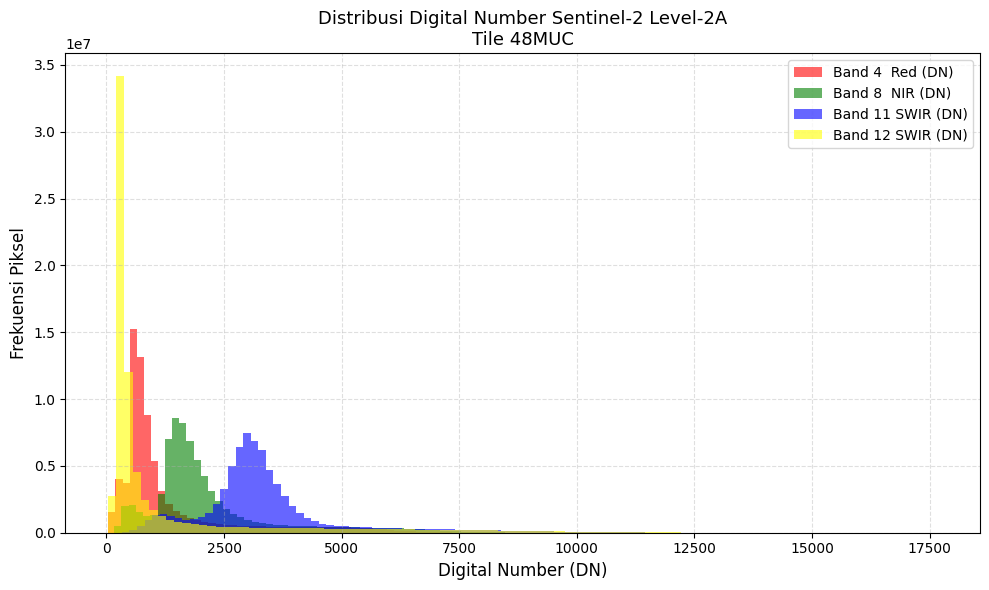

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt


# Path ke file multiband Sentinel-2 Level-2A (DN)
file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MUC_DN.tif'


# Buka dan baca band
with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    band4  = src.read(1).astype(np.float32)
    band8  = src.read(2).astype(np.float32)
    band11 = src.read(3).astype(np.float32)
    band12 = src.read(4).astype(np.float32)

# Simpan ke dictionary
band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11,
    'B12': band12
}

band_labels = {
    'B4':  'Band 4  Red (DN)',
    'B8':  'Band 8  NIR (DN)',
    'B11': 'Band 11 SWIR (DN)',
    'B12': 'Band 12 SWIR (DN)'
}

# Flatten & filter DN valid
band_values = {}
for b in band_data:
    values = band_data[b].flatten()
    values = values[np.isfinite(values)]  # hapus NaN / Inf
    values = values[values > 0]            # hapus no-data
    band_values[b] = values

# Plot histogram DN
plt.figure(figsize=(10, 6))

# Warna disesuaikan jumlah band
colors = ['red', 'green', 'blue', 'yellow']

for i, b in enumerate(['B4', 'B8', 'B11', 'B12']):
    plt.hist(
        band_values[b],
        bins=100,
        alpha=0.6,
        color=colors[i],
        label=band_labels[b]
    )

plt.xlabel('Digital Number (DN)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Digital Number Sentinel-2 Level-2A\nTile 48MUC', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import rasterio
import numpy as np

# Path ke file multiband Sentinel-2 Level-2A
file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MUC_DN.tif'

# Buka dan baca band (DN asli)
with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    band4  = src.read(1).astype(np.float64)
    band8  = src.read(2).astype(np.float64)
    band11 = src.read(3).astype(np.float64)
    band12 = src.read(4).astype(np.float64)

# Simpan ke dictionary
band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11,
    'B12': band12
}

# Hitung total DN & statistik
for b, data in band_data.items():
    values = data.flatten()
    values = values[np.isfinite(values)]  # hapus NaN
    values = values[values > 0]            # hapus no-data

    total_dn = np.sum(values)
    min_dn   = np.min(values)
    max_dn   = np.max(values)
    mean_dn  = np.mean(values)
    std_dn   = np.std(values)
    count_px = values.size

    print(f"\n=== {b} ===")
    print(f"Jumlah piksel       : {count_px:,}")
    print(f"Total DN            : {total_dn:,.2f}")
    print(f"DN minimum          : {min_dn:.2f}")
    print(f"DN maksimum         : {max_dn:.2f}")
    print(f"DN rata-rata        : {mean_dn:.2f}")
    print(f"Standar deviasi DN  : {std_dn:.2f}")


Jumlah band dalam file: 4

=== B4 ===
Jumlah piksel       : 74,865,177
Total DN            : 99,326,038,656.00
DN minimum          : 38.00
DN maksimum         : 15247.00
DN rata-rata        : 1326.73
Standar deviasi DN  : 1333.59

=== B8 ===
Jumlah piksel       : 74,865,177
Total DN            : 161,856,692,194.00
DN minimum          : 9.00
DN maksimum         : 15392.00
DN rata-rata        : 2161.98
Standar deviasi DN  : 1404.45

=== B11 ===
Jumlah piksel       : 74,865,177
Total DN            : 251,957,306,655.00
DN minimum          : 166.00
DN maksimum         : 16280.00
DN rata-rata        : 3365.48
Standar deviasi DN  : 1577.09

=== B12 ===
Jumlah piksel       : 74,865,173
Total DN            : 97,386,839,968.00
DN minimum          : 26.00
DN maksimum         : 17688.00
DN rata-rata        : 1300.83
Standar deviasi DN  : 2140.07


Jumlah band dalam file: 4


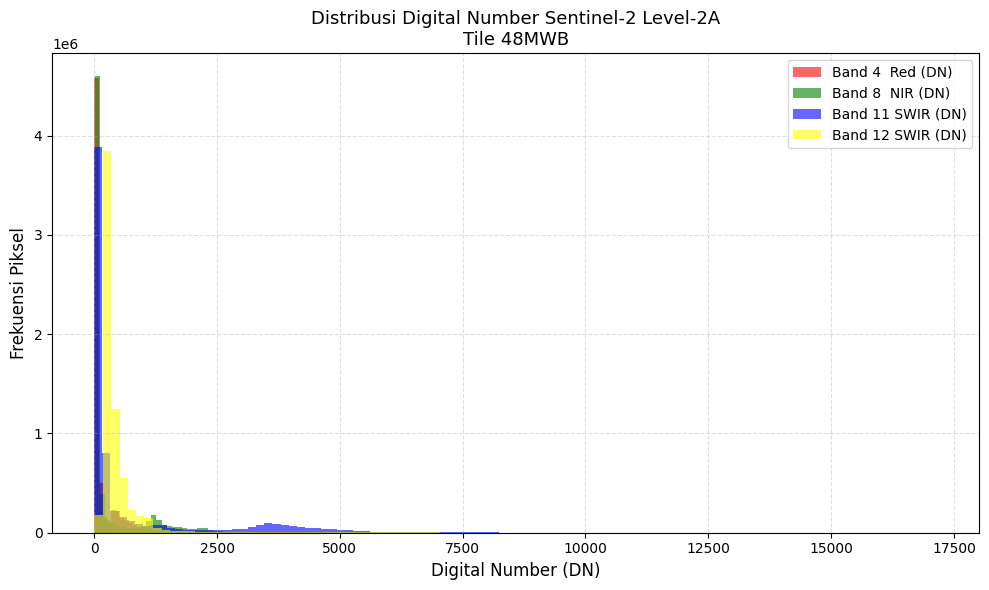

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt


# Path ke file multiband Sentinel-2 Level-2A (DN)
file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MWB_DN.tif'


# Buka dan baca band
with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    band4  = src.read(1).astype(np.float32)
    band8  = src.read(2).astype(np.float32)
    band11 = src.read(3).astype(np.float32)
    band12 = src.read(4).astype(np.float32)

# Simpan ke dictionary
band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11,
    'B12': band12
}

band_labels = {
    'B4':  'Band 4  Red (DN)',
    'B8':  'Band 8  NIR (DN)',
    'B11': 'Band 11 SWIR (DN)',
    'B12': 'Band 12 SWIR (DN)'
}

# Flatten & filter DN valid
band_values = {}
for b in band_data:
    values = band_data[b].flatten()
    values = values[np.isfinite(values)]  # hapus NaN / Inf
    values = values[values > 0]            # hapus no-data
    band_values[b] = values

# Plot histogram DN
plt.figure(figsize=(10, 6))

# Warna disesuaikan jumlah band
colors = ['red', 'green', 'blue', 'yellow']

for i, b in enumerate(['B4', 'B8', 'B11', 'B12']):
    plt.hist(
        band_values[b],
        bins=100,
        alpha=0.6,
        color=colors[i],
        label=band_labels[b]
    )

plt.xlabel('Digital Number (DN)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Digital Number Sentinel-2 Level-2A\nTile 48MWB', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import rasterio
import numpy as np

# Path ke file multiband Sentinel-2 Level-2A
file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MWB_DN.tif'

# Buka dan baca band (DN asli)
with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    band4  = src.read(1).astype(np.float64)
    band8  = src.read(2).astype(np.float64)
    band11 = src.read(3).astype(np.float64)
    band12 = src.read(4).astype(np.float64)

# Simpan ke dictionary
band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11,
    'B12': band12
}

# Hitung total DN & statistik
for b, data in band_data.items():
    values = data.flatten()
    values = values[np.isfinite(values)]  # hapus NaN
    values = values[values > 0]            # hapus no-data

    total_dn = np.sum(values)
    min_dn   = np.min(values)
    max_dn   = np.max(values)
    mean_dn  = np.mean(values)
    std_dn   = np.std(values)
    count_px = values.size

    print(f"\n=== {b} ===")
    print(f"Jumlah piksel       : {count_px:,}")
    print(f"Total DN            : {total_dn:,.2f}")
    print(f"DN minimum          : {min_dn:.2f}")
    print(f"DN maksimum         : {max_dn:.2f}")
    print(f"DN rata-rata        : {mean_dn:.2f}")
    print(f"Standar deviasi DN  : {std_dn:.2f}")


Jumlah band dalam file: 4

=== B4 ===
Jumlah piksel       : 6,687,083
Total DN            : 1,794,707,295.00
DN minimum          : 1.00
DN maksimum         : 8724.00
DN rata-rata        : 268.38
Standar deviasi DN  : 642.73

=== B8 ===
Jumlah piksel       : 6,687,113
Total DN            : 2,995,211,259.00
DN minimum          : 18.00
DN maksimum         : 10426.00
DN rata-rata        : 447.91
Standar deviasi DN  : 878.10

=== B11 ===
Jumlah piksel       : 6,686,692
Total DN            : 5,858,347,465.00
DN minimum          : 1.00
DN maksimum         : 16488.00
DN rata-rata        : 876.12
Standar deviasi DN  : 1549.63

=== B12 ===
Jumlah piksel       : 6,681,023
Total DN            : 3,478,054,176.00
DN minimum          : 1.00
DN maksimum         : 17160.00
DN rata-rata        : 520.59
Standar deviasi DN  : 876.08


Prefire

Jumlah band dalam file: 4


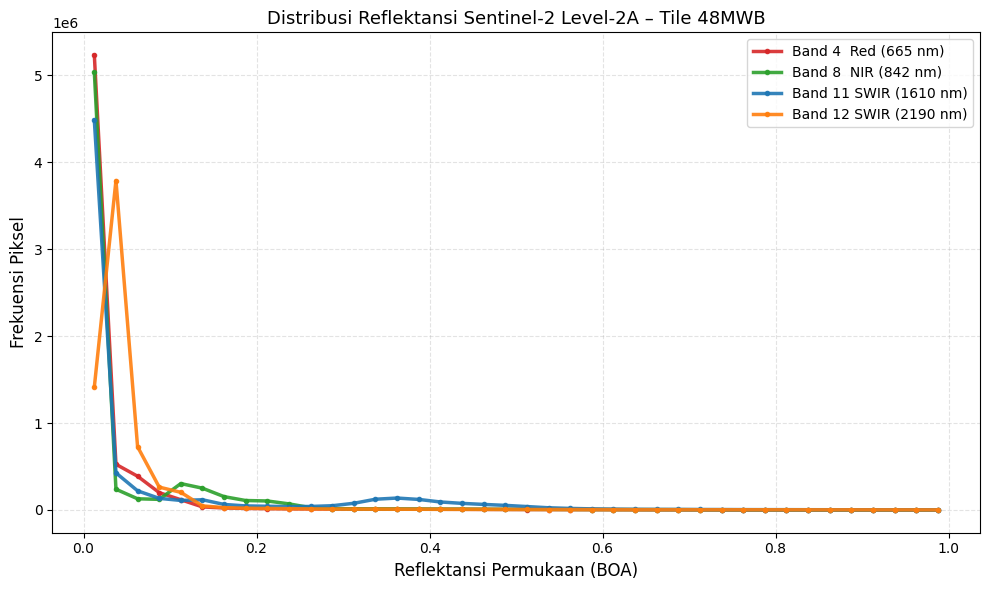

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MWB_pre_fix.tif'

with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    band4  = src.read(1).astype(np.float32) / 10000.0
    band8  = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0
    band12 = src.read(4).astype(np.float32) / 10000.0

band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11,
    'B12': band12
}

band_labels = {
    'B4':  'Band 4  Red (665 nm)',
    'B8':  'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)',
    'B12': 'Band 12 SWIR (2190 nm)'
}

band_values = {}
for b in band_data:
    v = band_data[b].flatten()
    v = v[np.isfinite(v)]
    v = v[(v > 0) & (v <= 1)]
    band_values[b] = v

# PLOT – WARNA & STYLE
plt.figure(figsize=(10, 6))

colors = {
    'B4':  '#d62728',  # merah tua
    'B8':  '#2ca02c',  # hijau tua
    'B11': '#1f77b4',  # biru tua
    'B12': '#ff7f0e'   # oranye
}

bins = np.linspace(0, 1, 41)

for b in ['B4', 'B8', 'B11', 'B12']:
    counts, edges = np.histogram(band_values[b], bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2

    plt.plot(
        centers,
        counts,
        label=band_labels[b],
        color=colors[b],
        linewidth=2.5,
        marker='o',
        markersize=3,
        alpha=0.9
    )

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A – Tile 48MWB', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

Jumlah band dalam file: 4


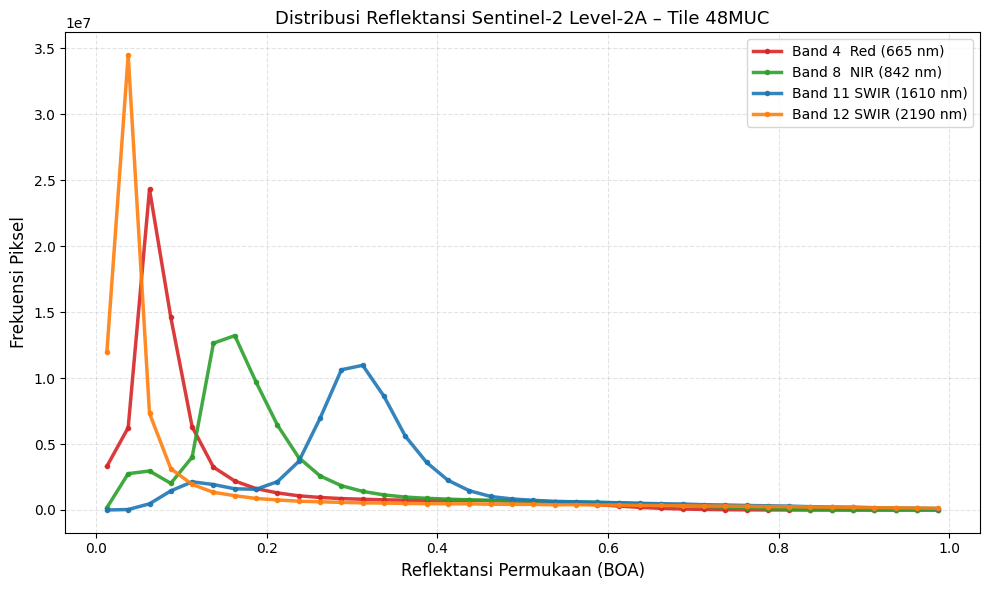

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MUC_pre_fix.tif'

with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    band4  = src.read(1).astype(np.float32) / 10000.0
    band8  = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0
    band12 = src.read(4).astype(np.float32) / 10000.0

band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11,
    'B12': band12
}

band_labels = {
    'B4':  'Band 4  Red (665 nm)',
    'B8':  'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)',
    'B12': 'Band 12 SWIR (2190 nm)'
}

band_values = {}
for b in band_data:
    v = band_data[b].flatten()
    v = v[np.isfinite(v)]
    v = v[(v > 0) & (v <= 1)]
    band_values[b] = v

# PLOT – WARNA & STYLE
plt.figure(figsize=(10, 6))

colors = {
    'B4':  '#d62728',  # merah tua
    'B8':  '#2ca02c',  # hijau tua
    'B11': '#1f77b4',  # biru tua
    'B12': '#ff7f0e'   # oranye
}

bins = np.linspace(0, 1, 41)

for b in ['B4', 'B8', 'B11', 'B12']:
    counts, edges = np.histogram(band_values[b], bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2

    plt.plot(
        centers,
        counts,
        label=band_labels[b],
        color=colors[b],
        linewidth=2.5,
        marker='o',
        markersize=3,
        alpha=0.9
    )

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A – Tile 48MUC', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

Jumlah band dalam file: 4


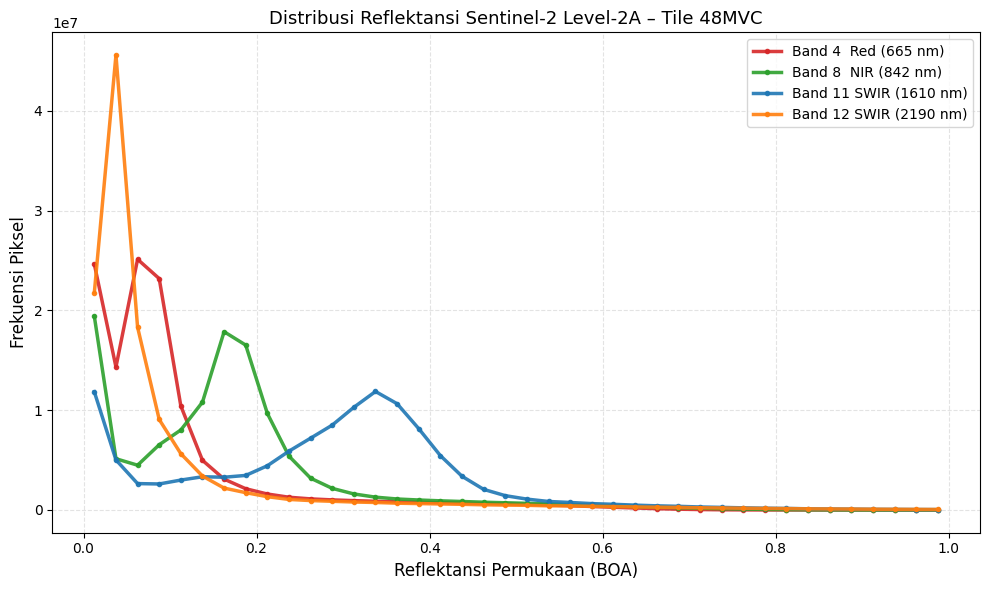

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MVC_pre_fix.tif'

with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    band4  = src.read(1).astype(np.float32) / 10000.0
    band8  = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0
    band12 = src.read(4).astype(np.float32) / 10000.0

band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11,
    'B12': band12
}

band_labels = {
    'B4':  'Band 4  Red (665 nm)',
    'B8':  'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)',
    'B12': 'Band 12 SWIR (2190 nm)'
}

band_values = {}
for b in band_data:
    v = band_data[b].flatten()
    v = v[np.isfinite(v)]
    v = v[(v > 0) & (v <= 1)]
    band_values[b] = v

# PLOT – WARNA & STYLE
plt.figure(figsize=(10, 6))

colors = {
    'B4':  '#d62728',  # merah tua
    'B8':  '#2ca02c',  # hijau tua
    'B11': '#1f77b4',  # biru tua
    'B12': '#ff7f0e'   # oranye
}

bins = np.linspace(0, 1, 41)

for b in ['B4', 'B8', 'B11', 'B12']:
    counts, edges = np.histogram(band_values[b], bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2

    plt.plot(
        centers,
        counts,
        label=band_labels[b],
        color=colors[b],
        linewidth=2.5,
        marker='o',
        markersize=3,
        alpha=0.9
    )

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A – Tile 48MVC', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

Postfire

Jumlah band dalam file: 4


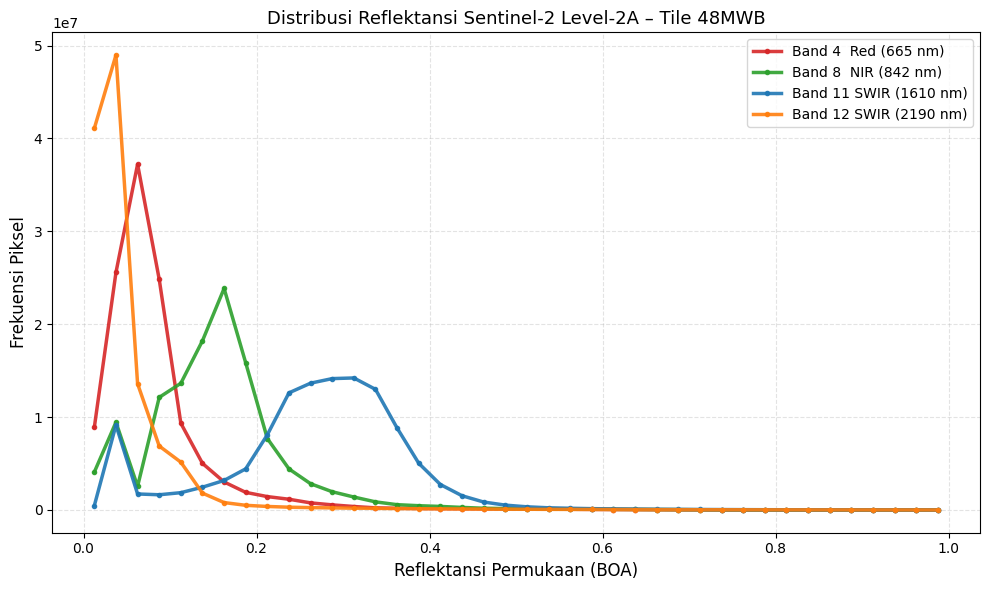

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MWB_post_fix.tif'

with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    band4  = src.read(1).astype(np.float32) / 10000.0
    band8  = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0
    band12 = src.read(4).astype(np.float32) / 10000.0

band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11,
    'B12': band12
}

band_labels = {
    'B4':  'Band 4  Red (665 nm)',
    'B8':  'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)',
    'B12': 'Band 12 SWIR (2190 nm)'
}

band_values = {}
for b in band_data:
    v = band_data[b].flatten()
    v = v[np.isfinite(v)]
    v = v[(v > 0) & (v <= 1)]
    band_values[b] = v

# PLOT – WARNA & STYLE
plt.figure(figsize=(10, 6))

colors = {
    'B4':  '#d62728',  # merah tua
    'B8':  '#2ca02c',  # hijau tua
    'B11': '#1f77b4',  # biru tua
    'B12': '#ff7f0e'   # oranye
}

bins = np.linspace(0, 1, 41)

for b in ['B4', 'B8', 'B11', 'B12']:
    counts, edges = np.histogram(band_values[b], bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2

    plt.plot(
        centers,
        counts,
        label=band_labels[b],
        color=colors[b],
        linewidth=2.5,
        marker='o',
        markersize=3,
        alpha=0.9
    )

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A – Tile 48MWB', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

Jumlah band dalam file: 4


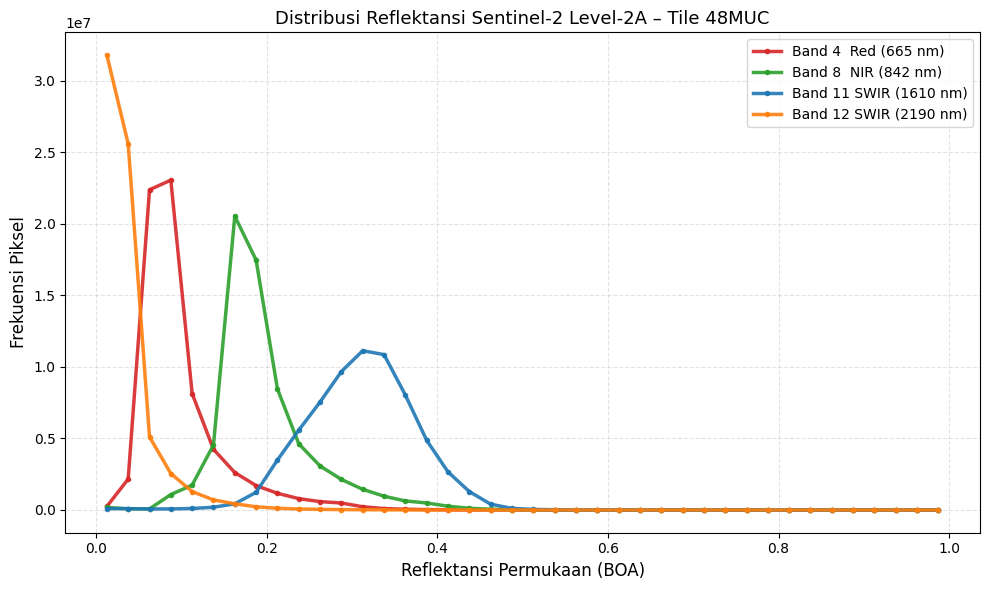

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MUC_post_fix.tif'

with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    band4  = src.read(1).astype(np.float32) / 10000.0
    band8  = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0
    band12 = src.read(4).astype(np.float32) / 10000.0

band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11,
    'B12': band12
}

band_labels = {
    'B4':  'Band 4  Red (665 nm)',
    'B8':  'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)',
    'B12': 'Band 12 SWIR (2190 nm)'
}

band_values = {}
for b in band_data:
    v = band_data[b].flatten()
    v = v[np.isfinite(v)]
    v = v[(v > 0) & (v <= 1)]
    band_values[b] = v

# PLOT – WARNA & STYLE
plt.figure(figsize=(10, 6))

colors = {
    'B4':  '#d62728',  # merah tua
    'B8':  '#2ca02c',  # hijau tua
    'B11': '#1f77b4',  # biru tua
    'B12': '#ff7f0e'   # oranye
}

bins = np.linspace(0, 1, 41)

for b in ['B4', 'B8', 'B11', 'B12']:
    counts, edges = np.histogram(band_values[b], bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2

    plt.plot(
        centers,
        counts,
        label=band_labels[b],
        color=colors[b],
        linewidth=2.5,
        marker='o',
        markersize=3,
        alpha=0.9
    )

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A – Tile 48MUC', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

Jumlah band dalam file: 4


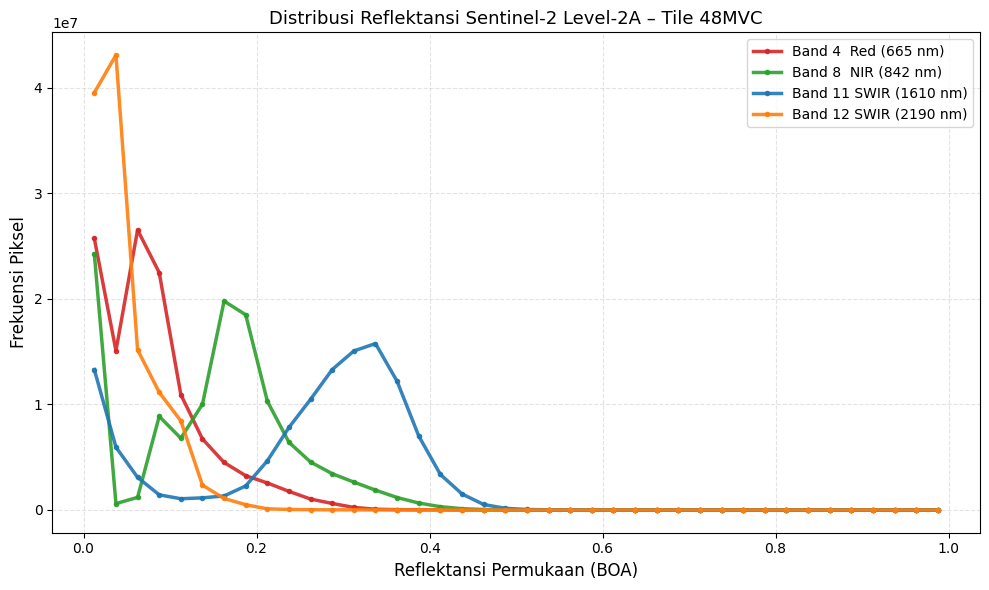

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MVC_post_fix.tif'

with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    band4  = src.read(1).astype(np.float32) / 10000.0
    band8  = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0
    band12 = src.read(4).astype(np.float32) / 10000.0

band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11,
    'B12': band12
}

band_labels = {
    'B4':  'Band 4  Red (665 nm)',
    'B8':  'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)',
    'B12': 'Band 12 SWIR (2190 nm)'
}

band_values = {}
for b in band_data:
    v = band_data[b].flatten()
    v = v[np.isfinite(v)]
    v = v[(v > 0) & (v <= 1)]
    band_values[b] = v

# PLOT – WARNA & STYLE
plt.figure(figsize=(10, 6))

colors = {
    'B4':  '#d62728',  # merah tua
    'B8':  '#2ca02c',  # hijau tua
    'B11': '#1f77b4',  # biru tua
    'B12': '#ff7f0e'   # oranye
}

bins = np.linspace(0, 1, 41)

for b in ['B4', 'B8', 'B11', 'B12']:
    counts, edges = np.histogram(band_values[b], bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2

    plt.plot(
        centers,
        counts,
        label=band_labels[b],
        color=colors[b],
        linewidth=2.5,
        marker='o',
        markersize=3,
        alpha=0.9
    )

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A – Tile 48MVC', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

#### Batas Pemisah

Jumlah band dalam file: 4


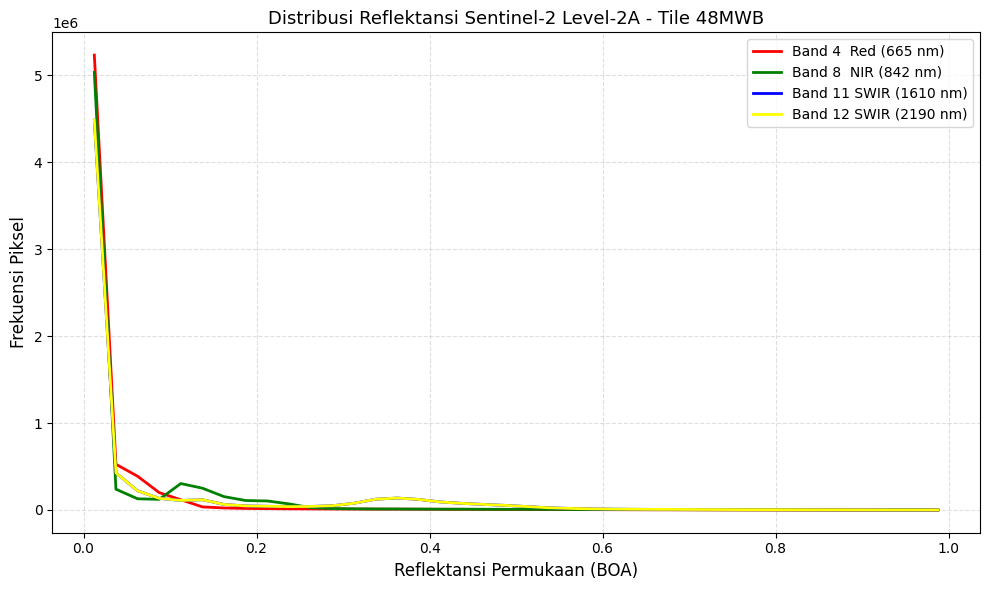

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file multiband Sentinel-2 Level-2A (Tile 48MWB)
file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MWBPre.tif'

# Buka dan baca band Sentinel-2 (B4, B8, B11)
with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    # Urutan sesuai dengan posisi band
    band4 = src.read(1).astype(np.float32) / 10000.0
    band8 = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0


# Simpan ke dictionary untuk kemudahan akses
band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11
}

band_labels = {
    'B4': 'Band 4  Red (665 nm)',
    'B8': 'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)'
}

# Flatten array dan filter nilai tidak valid
band_values = {}
for b in ['B4', 'B8', 'B11']:
    values = band_data[b].flatten()
    values = values[np.isfinite(values)]  # Hapus NaN
    values = values[(values > 0) & (values <= 1)]  # Hanya nilai reflektansi valid
    band_values[b] = values

# === Plot histogram reflektansi ===
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
bins = np.linspace(0, 1, 41)  # 40 bin dari 0–1

for i, b in enumerate(['B4', 'B8', 'B11']):
    arr = band_values[b]
    counts, bin_edges = np.histogram(arr, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, counts, label=band_labels[b],
             color=colors[i], linewidth=2)

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A - Tile 48MWB', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Jumlah band dalam file: 3


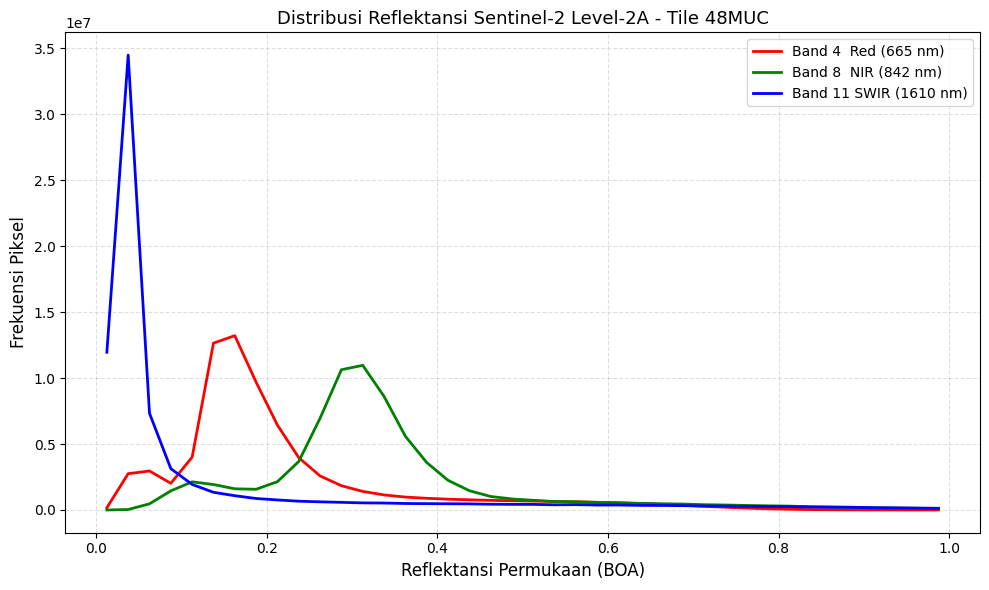

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# === Path ke file multiband Sentinel-2 Level-2A (Tile 48MWB) ===
file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MUC_pre_fix.tif'

# === Buka dan baca band Sentinel-2 (B4, B8, B11) ===
with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    # Urutan sesuai dengan posisi band di file Anda
    band4 = src.read(1).astype(np.float32) / 10000.0
    band8 = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0


# === Simpan ke dictionary untuk kemudahan akses ===
band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11
}

band_labels = {
    'B4': 'Band 4  Red (665 nm)',
    'B8': 'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)'
}

# === Flatten array dan filter nilai tidak valid ===
band_values = {}
for b in ['B4', 'B8', 'B11']:
    values = band_data[b].flatten()
    values = values[np.isfinite(values)]  # Hapus NaN
    values = values[(values > 0) & (values <= 1)]  # Hanya nilai reflektansi valid
    band_values[b] = values

# === Plot histogram reflektansi ===
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
bins = np.linspace(0, 1, 41)  # 40 bin dari 0–1

for i, b in enumerate(['B4', 'B8', 'B11']):
    arr = band_values[b]
    counts, bin_edges = np.histogram(arr, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, counts, label=band_labels[b],
             color=colors[i], linewidth=2)

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A - Tile 48MUC', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Jumlah band dalam file: 3


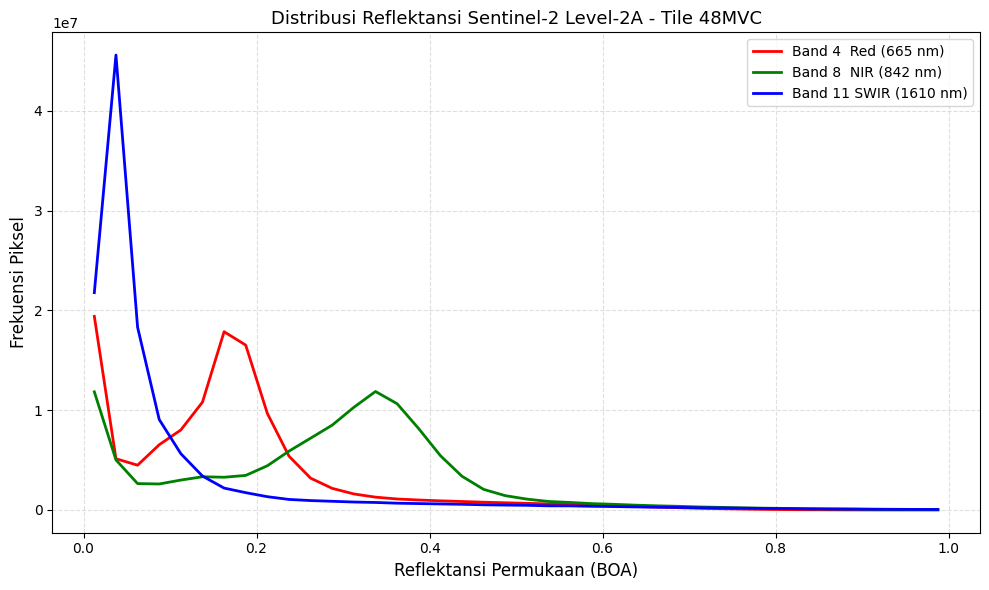

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# === Path ke file multiband Sentinel-2 Level-2A (Tile 48MWB) ===
file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MVC_pre_fix.tif'

# === Buka dan baca band Sentinel-2 (B4, B8, B11) ===
with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    # Urutan sesuai dengan posisi band di file Anda
    band4 = src.read(1).astype(np.float32) / 10000.0
    band8 = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0


# === Simpan ke dictionary untuk kemudahan akses ===
band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11
}

band_labels = {
    'B4': 'Band 4  Red (665 nm)',
    'B8': 'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)'
}

# === Flatten array dan filter nilai tidak valid ===
band_values = {}
for b in ['B4', 'B8', 'B11']:
    values = band_data[b].flatten()
    values = values[np.isfinite(values)]  # Hapus NaN
    values = values[(values > 0) & (values <= 1)]  # Hanya nilai reflektansi valid
    band_values[b] = values

# === Plot histogram reflektansi ===
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
bins = np.linspace(0, 1, 41)  # 40 bin dari 0–1

for i, b in enumerate(['B4', 'B8', 'B11']):
    arr = band_values[b]
    counts, bin_edges = np.histogram(arr, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, counts, label=band_labels[b],
             color=colors[i], linewidth=2)

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A - Tile 48MVC', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

PostFire

Jumlah band dalam file: 3


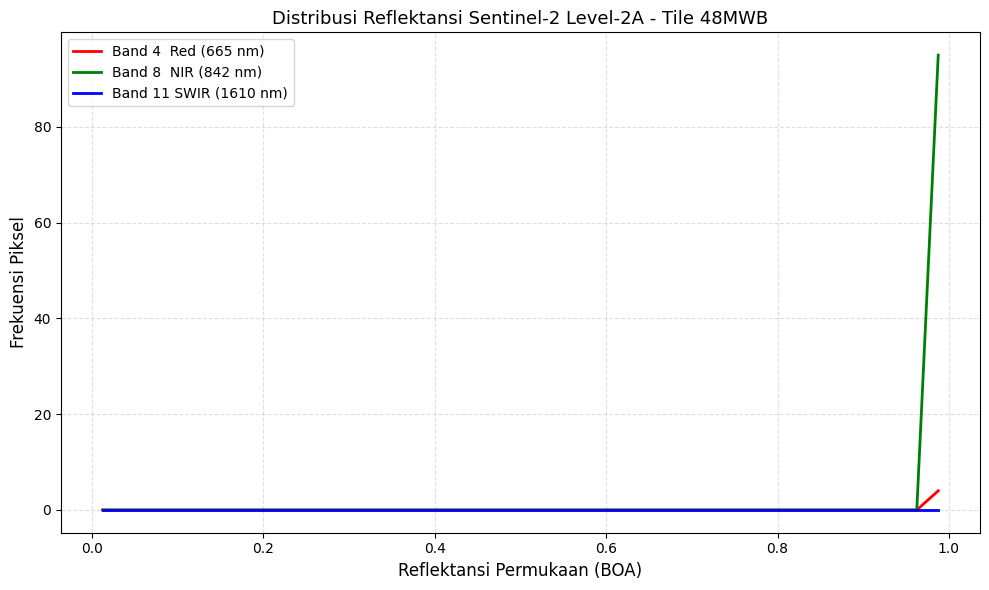

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# === Path ke file multiband Sentinel-2 Level-2A (Tile 48MWB) ===
file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MWB_post_fix.tif'

# === Buka dan baca band Sentinel-2 (B4, B8, B11) ===
with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    # Urutan sesuai dengan posisi band di file Anda
    band4 = src.read(1).astype(np.float32) / 10000.0
    band8 = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0


# === Simpan ke dictionary untuk kemudahan akses ===
band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11
}

band_labels = {
    'B4': 'Band 4  Red (665 nm)',
    'B8': 'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)'
}

# === Flatten array dan filter nilai tidak valid ===
band_values = {}
for b in ['B4', 'B8', 'B11']:
    values = band_data[b].flatten()
    values = values[np.isfinite(values)]  # Hapus NaN
    values = values[(values > 0) & (values <= 1)]  # Hanya nilai reflektansi valid
    band_values[b] = values

# === Plot histogram reflektansi ===
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
bins = np.linspace(0, 1, 41)  # 40 bin dari 0–1

for i, b in enumerate(['B4', 'B8', 'B11']):
    arr = band_values[b]
    counts, bin_edges = np.histogram(arr, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, counts, label=band_labels[b],
             color=colors[i], linewidth=2)

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A - Tile 48MWB', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Jumlah band dalam file: 3


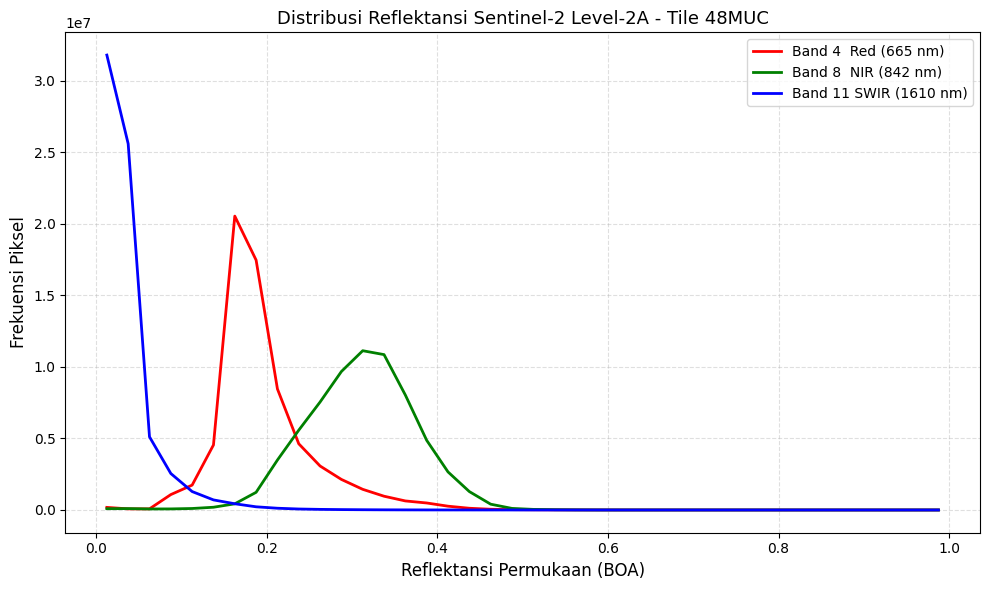

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# === Path ke file multiband Sentinel-2 Level-2A (Tile 48MWB) ===
file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MUC_post_fix.tif'

# === Buka dan baca band Sentinel-2 (B4, B8, B11) ===
with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    # Urutan sesuai dengan posisi band di file Anda
    band4 = src.read(1).astype(np.float32) / 10000.0
    band8 = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0


# === Simpan ke dictionary untuk kemudahan akses ===
band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11
}

band_labels = {
    'B4': 'Band 4  Red (665 nm)',
    'B8': 'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)'
}

# === Flatten array dan filter nilai tidak valid ===
band_values = {}
for b in ['B4', 'B8', 'B11']:
    values = band_data[b].flatten()
    values = values[np.isfinite(values)]  # Hapus NaN
    values = values[(values > 0) & (values <= 1)]  # Hanya nilai reflektansi valid
    band_values[b] = values

# === Plot histogram reflektansi ===
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
bins = np.linspace(0, 1, 41)  # 40 bin dari 0–1

for i, b in enumerate(['B4', 'B8', 'B11']):
    arr = band_values[b]
    counts, bin_edges = np.histogram(arr, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, counts, label=band_labels[b],
             color=colors[i], linewidth=2)

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A - Tile 48MUC', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Jumlah band dalam file: 3


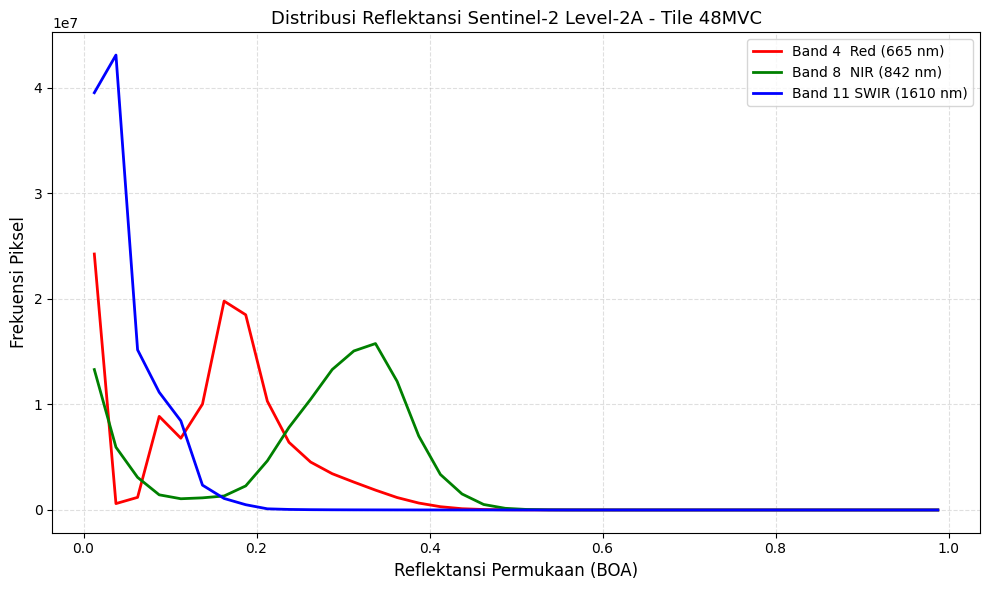

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# === Path ke file multiband Sentinel-2 Level-2A (Tile 48MWB) ===
file_path = '/content/drive/MyDrive/GEE_Export2/DataRaw_48MVC_post_fix.tif'

# === Buka dan baca band Sentinel-2 (B4, B8, B11) ===
with rasterio.open(file_path) as src:
    print(f"Jumlah band dalam file: {src.count}")

    # Urutan sesuai dengan posisi band di file Anda
    band4 = src.read(1).astype(np.float32) / 10000.0
    band8 = src.read(2).astype(np.float32) / 10000.0
    band11 = src.read(3).astype(np.float32) / 10000.0


# === Simpan ke dictionary untuk kemudahan akses ===
band_data = {
    'B4': band4,
    'B8': band8,
    'B11': band11
}

band_labels = {
    'B4': 'Band 4  Red (665 nm)',
    'B8': 'Band 8  NIR (842 nm)',
    'B11': 'Band 11 SWIR (1610 nm)'
}

# === Flatten array dan filter nilai tidak valid ===
band_values = {}
for b in ['B4', 'B8', 'B11']:
    values = band_data[b].flatten()
    values = values[np.isfinite(values)]  # Hapus NaN
    values = values[(values > 0) & (values <= 1)]  # Hanya nilai reflektansi valid
    band_values[b] = values

# === Plot histogram reflektansi ===
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
bins = np.linspace(0, 1, 41)  # 40 bin dari 0–1

for i, b in enumerate(['B4', 'B8', 'B11']):
    arr = band_values[b]
    counts, bin_edges = np.histogram(arr, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, counts, label=band_labels[b],
             color=colors[i], linewidth=2)

plt.xlabel('Reflektansi Permukaan (BOA)', fontsize=12)
plt.ylabel('Frekuensi Piksel', fontsize=12)
plt.title('Distribusi Reflektansi Sentinel-2 Level-2A - Tile 48MVC', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

## Histogram NDVI 48MWB

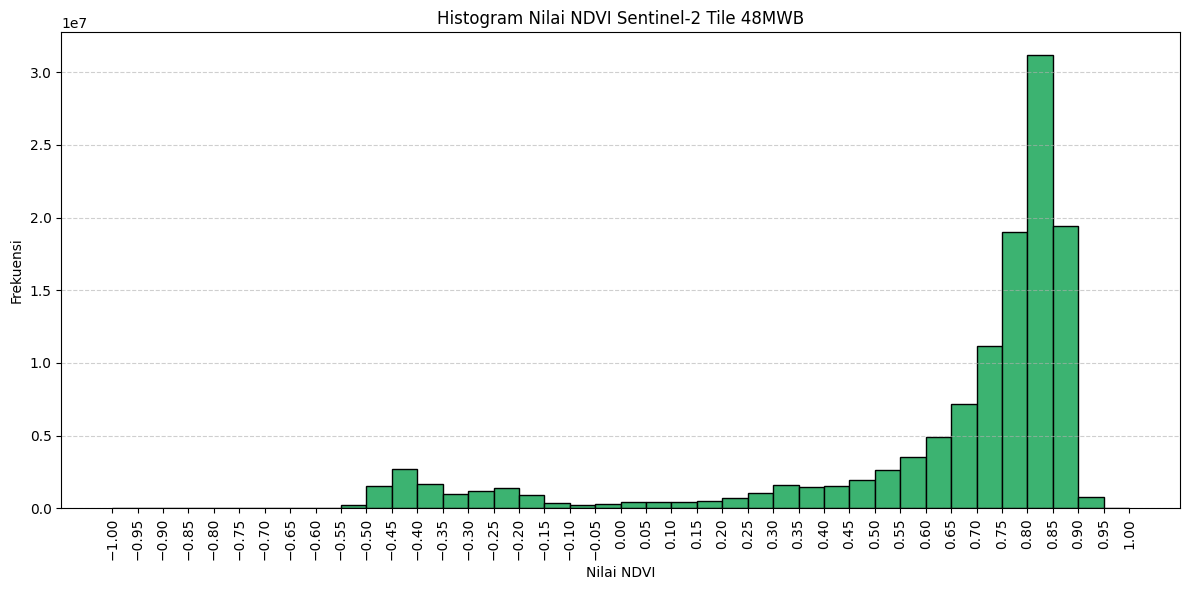

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NDVI hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export/NDVI_48MWB.tif'

# Baca data NDVI
with rasterio.open(path) as src:
    ndvi = src.read(1).astype('float32').flatten()

# Filter nilai valid NDVI (-1 s/d 1)
ndvi = ndvi[np.isfinite(ndvi)]  # Buang NaN
ndvi = ndvi[(ndvi >= -1.0) & (ndvi <= 1.0)]

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(ndvi, bins=40, range=(-1, 1), color='mediumseagreen', edgecolor='black')

# Tampilkan label sumbu x tiap 0.05 dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NDVI')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NDVI Sentinel-2 Tile 48MWB')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Prefire

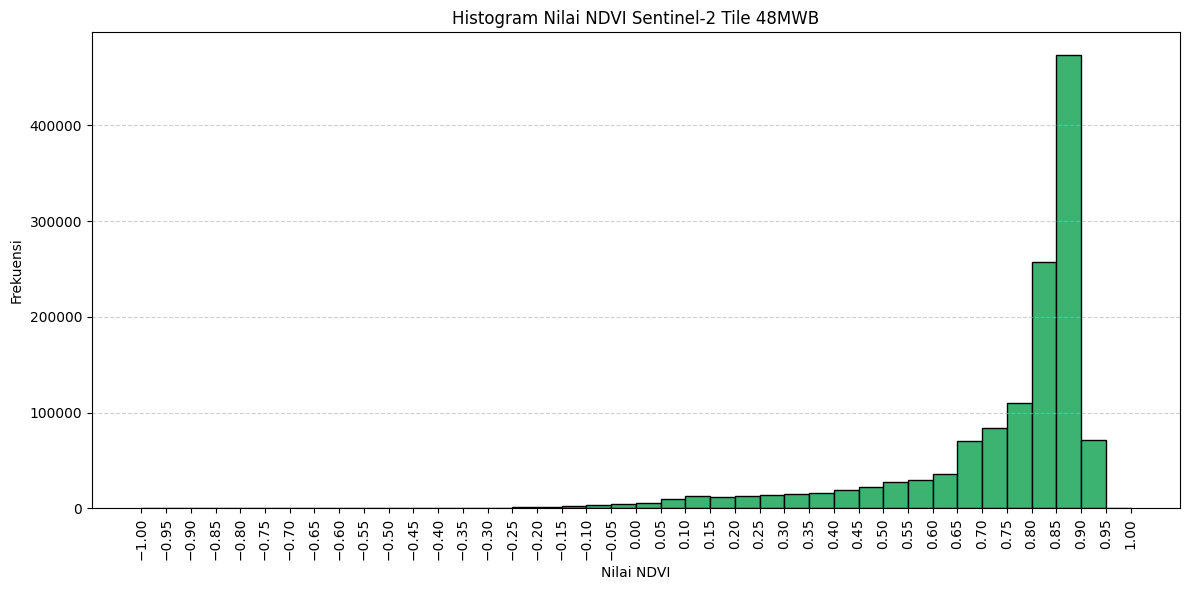

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NDVI hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export2/NDVI_48MWB_Prefire.tif'

# Baca data NDVI
with rasterio.open(path) as src:
    ndvi = src.read(1).astype('float32').flatten()

# Filter nilai valid NDVI (-1 s/d 1)
ndvi = ndvi[np.isfinite(ndvi)]  # Buang NaN
ndvi = ndvi[(ndvi >= -1.0) & (ndvi <= 1.0)]

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(ndvi, bins=40, range=(-1, 1), color='mediumseagreen', edgecolor='black')

# Tampilkan label sumbu x tiap 0.05 dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NDVI')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NDVI Sentinel-2 Tile 48MWB')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Histogram NDVI 48MUC

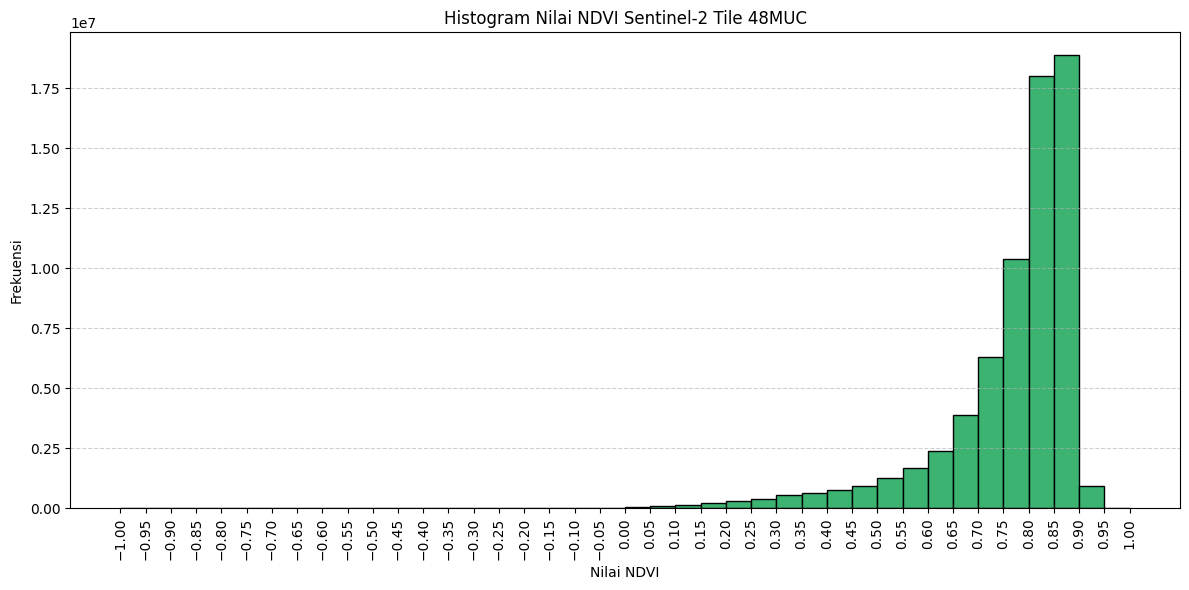

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NDVI hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export/NDVI_48MUC.tif'

# Baca data NDVI
with rasterio.open(path) as src:
    ndvi = src.read(1).astype('float32').flatten()

# Filter nilai valid NDVI (-1 s/d 1)
ndvi = ndvi[np.isfinite(ndvi)]  # Buang NaN
ndvi = ndvi[(ndvi >= -1.0) & (ndvi <= 1.0)]

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(ndvi, bins=40, range=(-1, 1), color='mediumseagreen', edgecolor='black')

# Tampilkan label sumbu x tiap 0.05 dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NDVI')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NDVI Sentinel-2 Tile 48MUC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Prefire

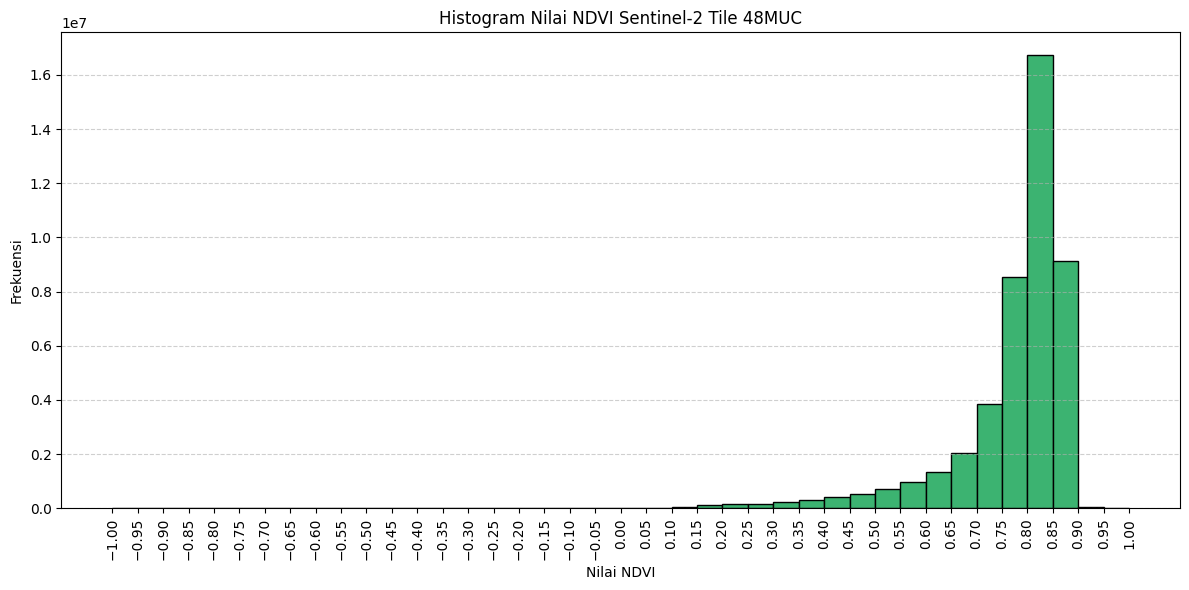

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NDVI hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export2/NDVI_48MUC_Prefire.tif'

# Baca data NDVI
with rasterio.open(path) as src:
    ndvi = src.read(1).astype('float32').flatten()

# Filter nilai valid NDVI (-1 s/d 1)
ndvi = ndvi[np.isfinite(ndvi)]  # Buang NaN
ndvi = ndvi[(ndvi >= -1.0) & (ndvi <= 1.0)]

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(ndvi, bins=40, range=(-1, 1), color='mediumseagreen', edgecolor='black')

# Tampilkan label sumbu x tiap 0.05 dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NDVI')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NDVI Sentinel-2 Tile 48MUC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Histogram NDVI 48MVC

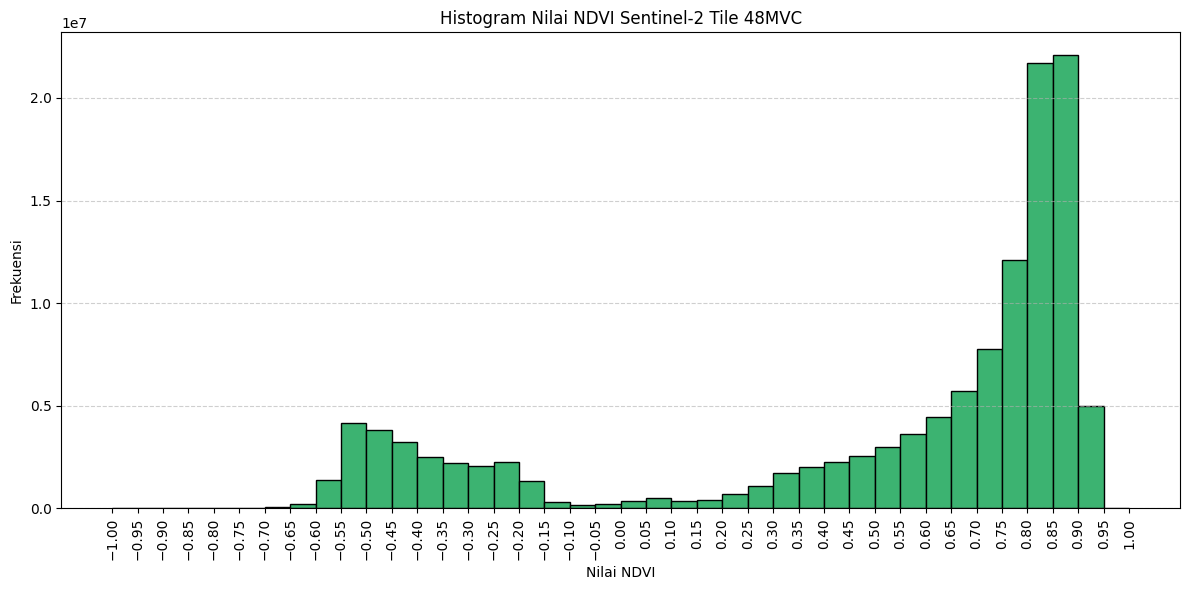

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NDVI hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export/NDVI_48MVC.tif'

# Baca data NDVI
with rasterio.open(path) as src:
    ndvi = src.read(1).astype('float32').flatten()

# Filter nilai valid NDVI (-1 s/d 1)
ndvi = ndvi[np.isfinite(ndvi)]  # Buang NaN
ndvi = ndvi[(ndvi >= -1.0) & (ndvi <= 1.0)]

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(ndvi, bins=40, range=(-1, 1), color='mediumseagreen', edgecolor='black')

# Tampilkan label sumbu x tiap 0.05 dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NDVI')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NDVI Sentinel-2 Tile 48MVC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Prefire

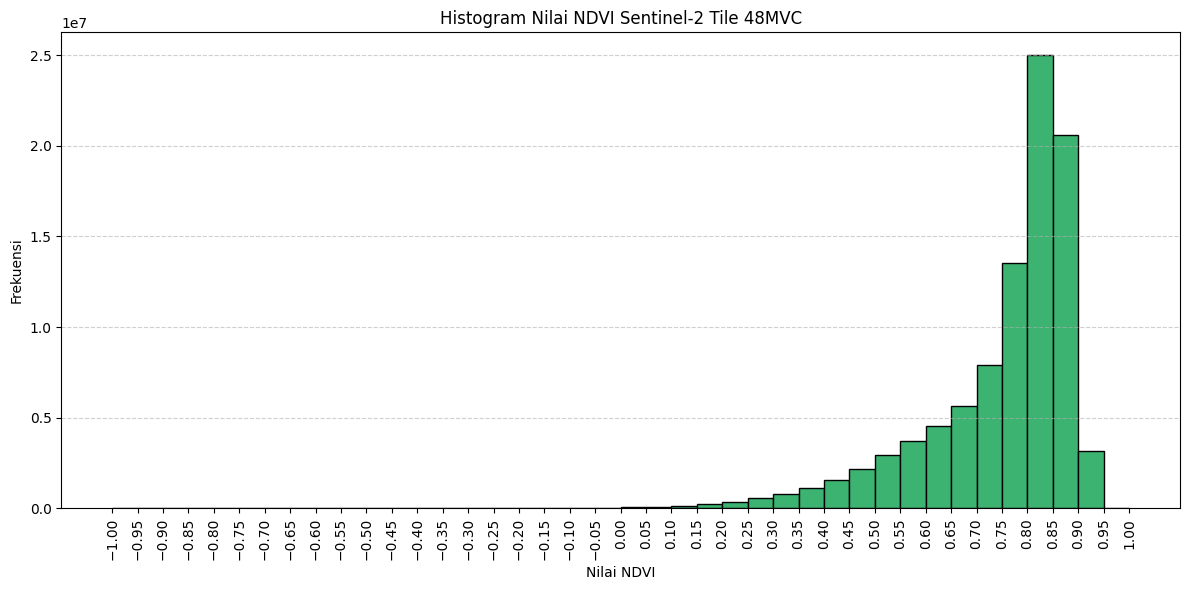

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NDVI hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export2/NDVI_48MVC_Prefire.tif'

# Baca data NDVI
with rasterio.open(path) as src:
    ndvi = src.read(1).astype('float32').flatten()

# Filter nilai valid NDVI (-1 s/d 1)
ndvi = ndvi[np.isfinite(ndvi)]  # Buang NaN
ndvi = ndvi[(ndvi >= -1.0) & (ndvi <= 1.0)]

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(ndvi, bins=40, range=(-1, 1), color='mediumseagreen', edgecolor='black')

# Tampilkan label sumbu x tiap 0.05 dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NDVI')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NDVI Sentinel-2 Tile 48MVC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Histogram NBR 48MWB

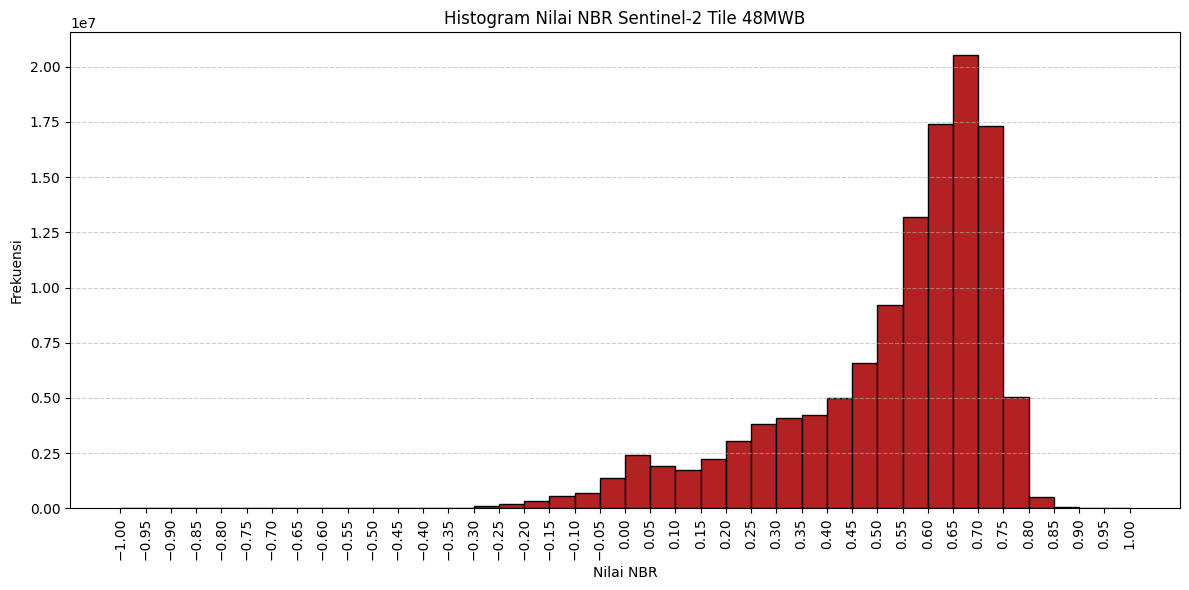

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NBR hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export/NBR_48MWB.tif'  # Ganti sesuai nama file kamu

# Baca data NBR
with rasterio.open(path) as src:
    nbr = src.read(1).astype('float32').flatten()

# Filter nilai valid NBR (-1 s/d 1)
nbr = nbr[np.isfinite(nbr)]  # Buang NaN
nbr = nbr[(nbr >= -1.0) & (nbr <= 1.0)]  # Pastikan dalam rentang NBR

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(nbr, bins=40, range=(-1, 1), color='firebrick', edgecolor='black')

# Set xticks lengkap dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NBR')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NBR Sentinel-2 Tile 48MWB')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Prefire

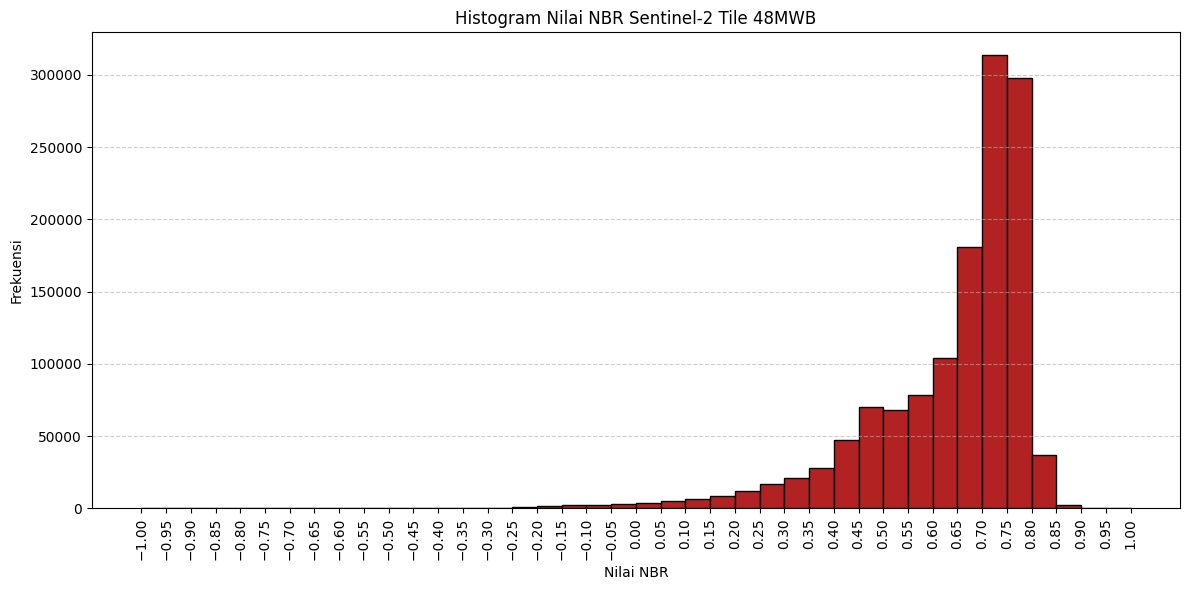

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NBR hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export2/NBR_48MWB_Prefire.tif'  # Ganti sesuai nama file kamu

# Baca data NBR
with rasterio.open(path) as src:
    nbr = src.read(1).astype('float32').flatten()

# Filter nilai valid NBR (-1 s/d 1)
nbr = nbr[np.isfinite(nbr)]  # Buang NaN
nbr = nbr[(nbr >= -1.0) & (nbr <= 1.0)]  # Pastikan dalam rentang NBR

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(nbr, bins=40, range=(-1, 1), color='firebrick', edgecolor='black')

# Set xticks lengkap dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NBR')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NBR Sentinel-2 Tile 48MWB')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Histogram NBR 48MUC

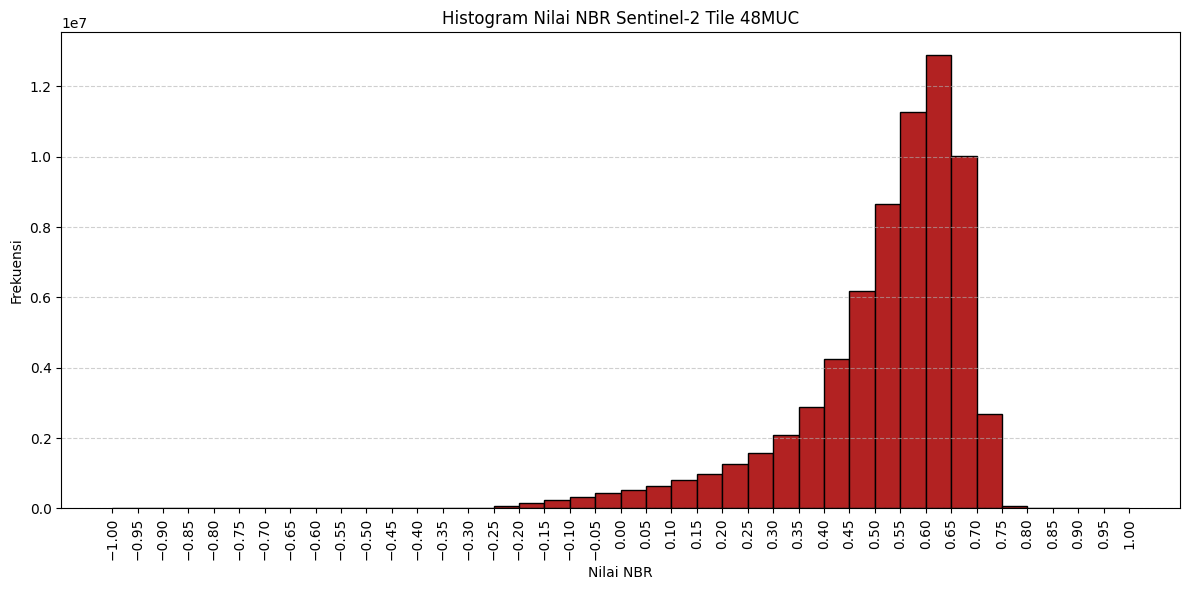

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NBR hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export/NBR_48MUC.tif'  # Ganti sesuai nama file kamu

# Baca data NBR
with rasterio.open(path) as src:
    nbr = src.read(1).astype('float32').flatten()

# Filter nilai valid NBR (-1 s/d 1)
nbr = nbr[np.isfinite(nbr)]  # Buang NaN
nbr = nbr[(nbr >= -1.0) & (nbr <= 1.0)]  # Pastikan dalam rentang NBR

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(nbr, bins=40, range=(-1, 1), color='firebrick', edgecolor='black')

# Set xticks lengkap dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NBR')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NBR Sentinel-2 Tile 48MUC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Prefire

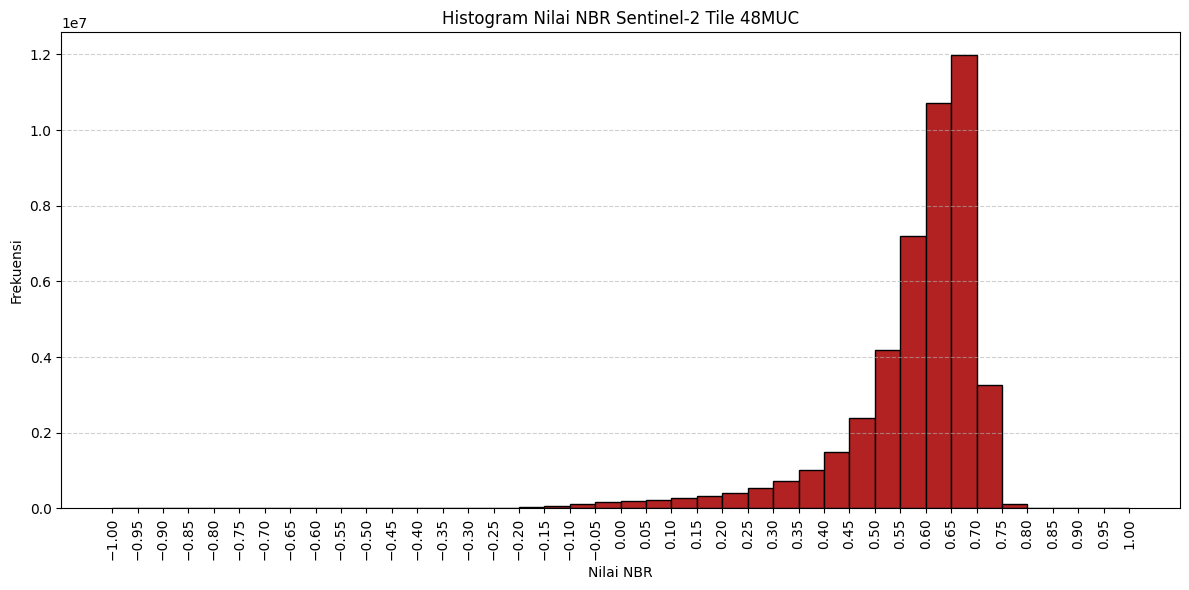

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NBR hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export2/NBR_48MUC_Prefire.tif'  # Ganti sesuai nama file kamu

# Baca data NBR
with rasterio.open(path) as src:
    nbr = src.read(1).astype('float32').flatten()

# Filter nilai valid NBR (-1 s/d 1)
nbr = nbr[np.isfinite(nbr)]  # Buang NaN
nbr = nbr[(nbr >= -1.0) & (nbr <= 1.0)]  # Pastikan dalam rentang NBR

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(nbr, bins=40, range=(-1, 1), color='firebrick', edgecolor='black')

# Set xticks lengkap dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NBR')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NBR Sentinel-2 Tile 48MUC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Histogram NBR 48MVC

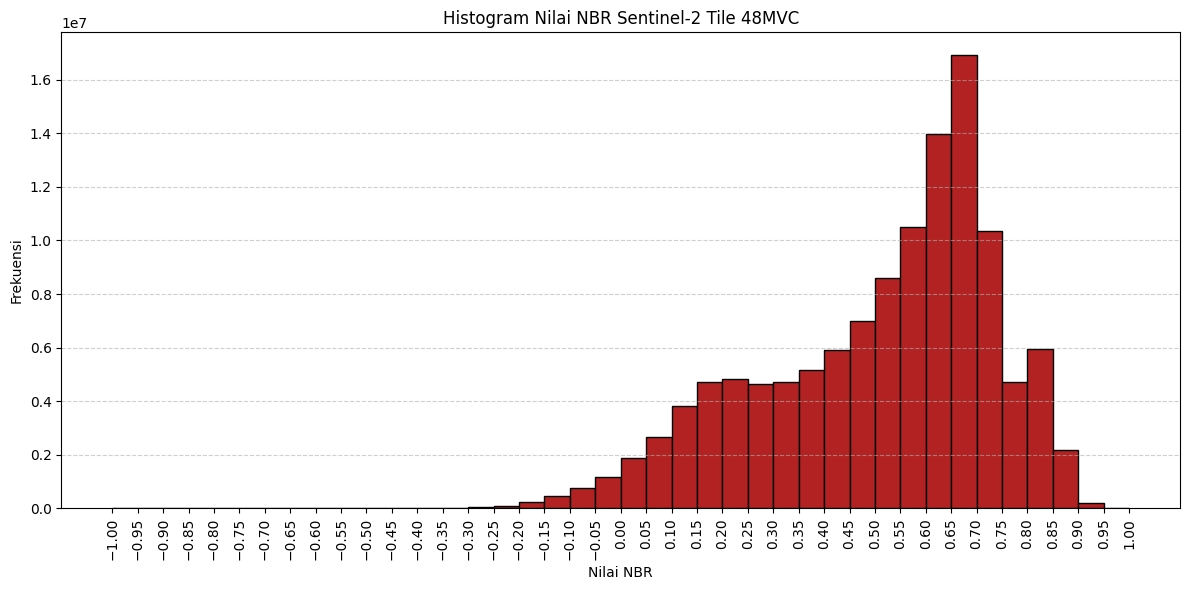

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NBR hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export/NBR_48MVC.tif'  # Ganti sesuai nama file kamu

# Baca data NBR
with rasterio.open(path) as src:
    nbr = src.read(1).astype('float32').flatten()

# Filter nilai valid NBR (-1 s/d 1)
nbr = nbr[np.isfinite(nbr)]  # Buang NaN
nbr = nbr[(nbr >= -1.0) & (nbr <= 1.0)]  # Pastikan dalam rentang NBR

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(nbr, bins=40, range=(-1, 1), color='firebrick', edgecolor='black')

# Set xticks lengkap dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NBR')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NBR Sentinel-2 Tile 48MVC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Prefire

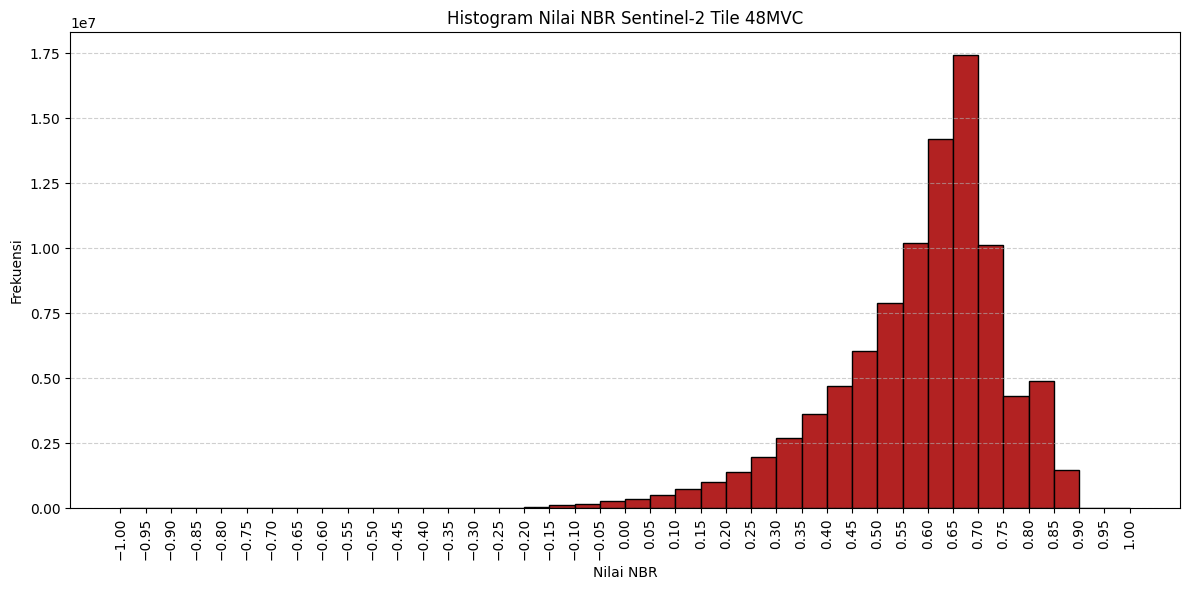

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file NBR hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export2/NBR_48MVC_Prefire.tif'  # Ganti sesuai nama file kamu

# Baca data NBR
with rasterio.open(path) as src:
    nbr = src.read(1).astype('float32').flatten()

# Filter nilai valid NBR (-1 s/d 1)
nbr = nbr[np.isfinite(nbr)]  # Buang NaN
nbr = nbr[(nbr >= -1.0) & (nbr <= 1.0)]  # Pastikan dalam rentang NBR

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(nbr, bins=40, range=(-1, 1), color='firebrick', edgecolor='black')

# Set xticks lengkap dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai NBR')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai NBR Sentinel-2 Tile 48MVC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Histogram dNBR 48MWB

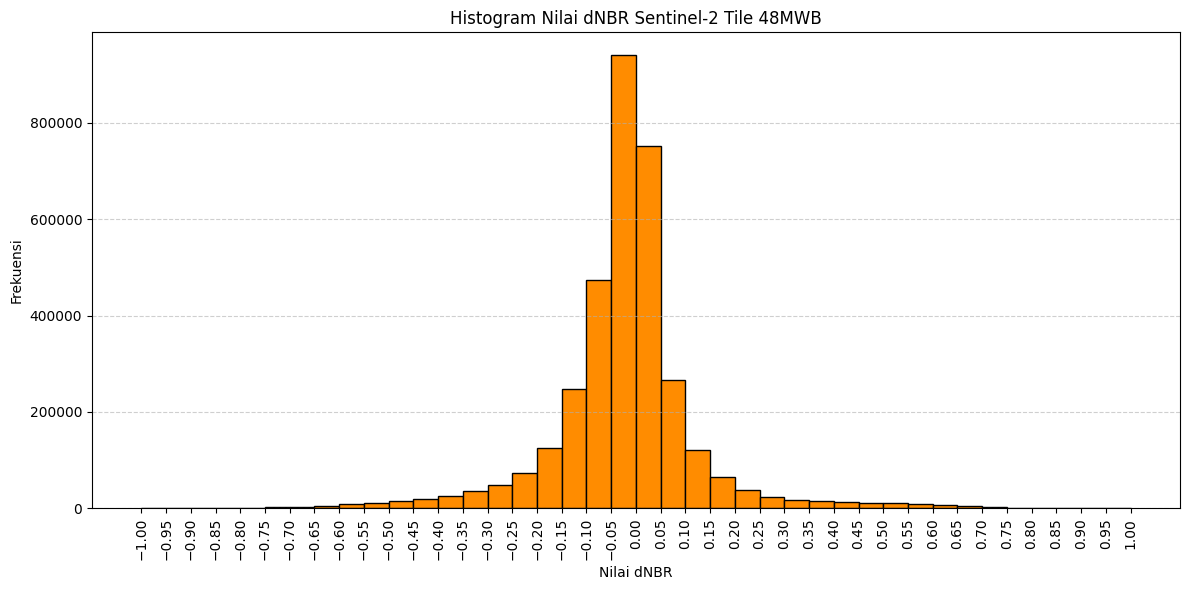

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file dNBR hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export/DNBR_48MWB.tif'  # Ganti sesuai nama file kamu

# Baca data dNBR
with rasterio.open(path) as src:
    dnbr = src.read(1).astype('float32').flatten()

# Filter nilai valid dNBR (-1 s/d 1)
dnbr = dnbr[np.isfinite(dnbr)]  # Hapus NaN
dnbr = dnbr[(dnbr >= -1.0) & (dnbr <= 1.0)]  # Batasi rentang

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(dnbr, bins=40, range=(-1, 1), color='darkorange', edgecolor='black')

# Set xticks lengkap dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai dNBR')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai dNBR Sentinel-2 Tile 48MWB')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Histogram dNBR 48MUC

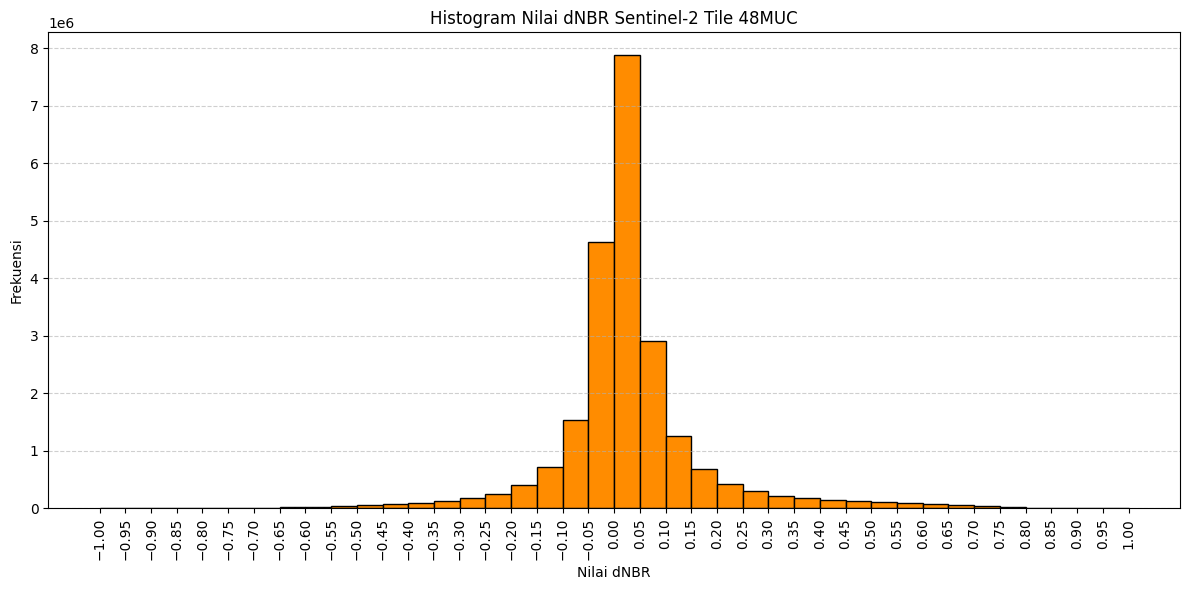

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file dNBR hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export/DNBR_48MUC.tif'  # Ganti sesuai nama file kamu

# Baca data dNBR
with rasterio.open(path) as src:
    dnbr = src.read(1).astype('float32').flatten()

# Filter nilai valid dNBR (-1 s/d 1)
dnbr = dnbr[np.isfinite(dnbr)]  # Hapus NaN
dnbr = dnbr[(dnbr >= -1.0) & (dnbr <= 1.0)]  # Batasi rentang

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(dnbr, bins=40, range=(-1, 1), color='darkorange', edgecolor='black')

# Set xticks lengkap dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai dNBR')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai dNBR Sentinel-2 Tile 48MUC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Histogram dNBR 48MVC

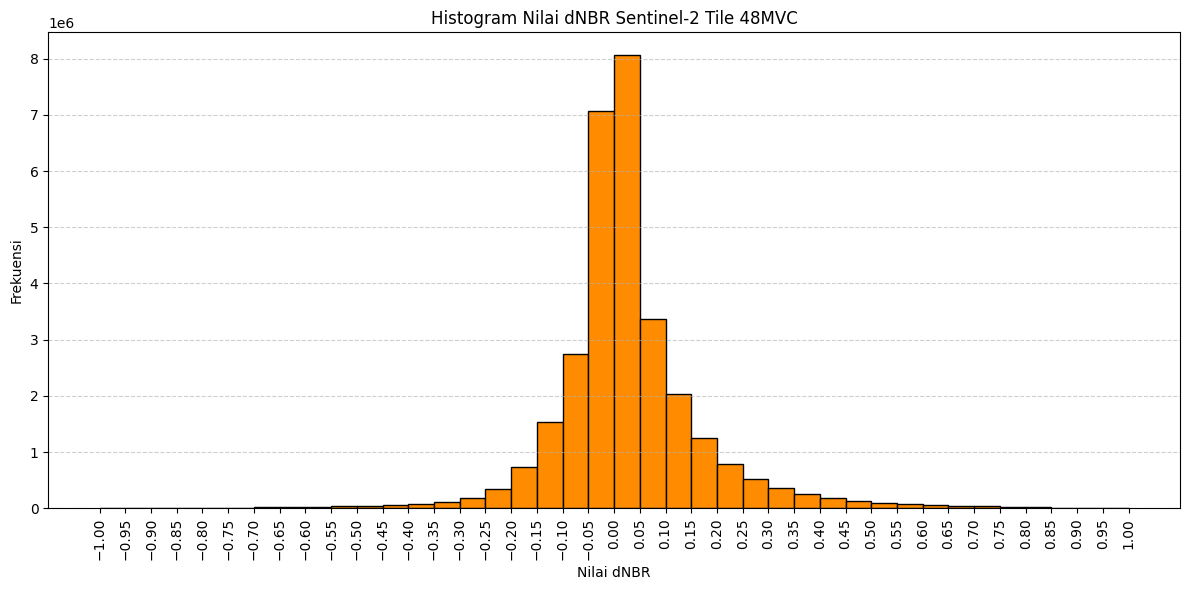

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file dNBR hasil ekspor dari GEE untuk Sentinel-2
path = '/content/drive/MyDrive/GEE_Export/DNBR_48MVC.tif'  # Ganti sesuai nama file kamu

# Baca data dNBR
with rasterio.open(path) as src:
    dnbr = src.read(1).astype('float32').flatten()

# Filter nilai valid dNBR (-1 s/d 1)
dnbr = dnbr[np.isfinite(dnbr)]  # Hapus NaN
dnbr = dnbr[(dnbr >= -1.0) & (dnbr <= 1.0)]  # Batasi rentang

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(dnbr, bins=40, range=(-1, 1), color='darkorange', edgecolor='black')

# Set xticks lengkap dan vertikal
xticks = np.round(np.arange(-1, 1.05, 0.05), 2)
plt.xticks(xticks, rotation='vertical')

plt.xlabel('Nilai dNBR')
plt.ylabel('Frekuensi')
plt.title('Histogram Nilai dNBR Sentinel-2 Tile 48MVC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Barplot Masking Citra 48MWB

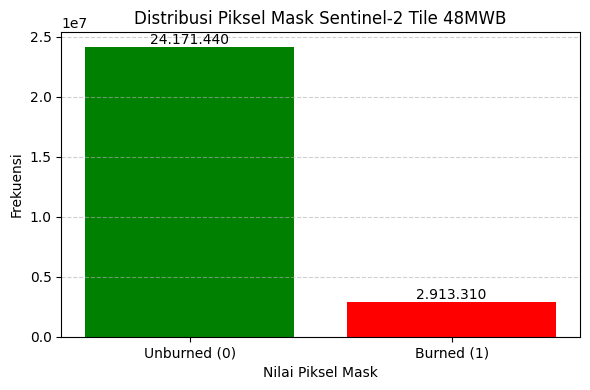

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file mask Sentinel-2 (hasil thresholding dNBR)
path = '/content/drive/MyDrive/GEE_Export/MASK_48MWB.tif'  # Ganti sesuai file Sentinel-2 kamu

# Baca data mask
with rasterio.open(path) as src:
    mask = src.read(1)

# Hitung jumlah piksel unik
unique, counts = np.unique(mask, return_counts=True)
freq_dict = dict(zip(unique, counts))

# Persiapkan label dan nilai (asumsi: 0 = unburned, 1 = burned)
labels = ['Unburned (0)', 'Burned (1)']
values = [freq_dict.get(0, 0), freq_dict.get(1, 0)]

# Plot bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['green', 'red'])

# Tambahkan angka pada bar
for bar in bars:
    height = bar.get_height()
    jumlah_format = f'{int(height):,}'.replace(',', '.')
    plt.text(bar.get_x() + bar.get_width()/2, height,
             jumlah_format,
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Nilai Piksel Mask')
plt.ylabel('Frekuensi')
plt.title('Distribusi Piksel Mask Sentinel-2 Tile 48MWB')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Barplot Masking Citra 48MUC

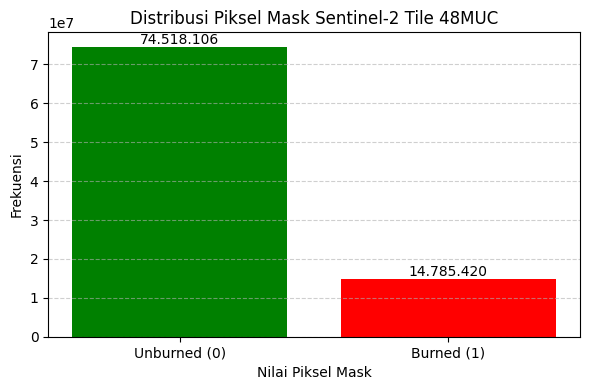

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file mask Sentinel-2 (hasil thresholding dNBR)
path = '/content/drive/MyDrive/GEE_Export/MASK_48MUC.tif'  # Ganti sesuai file Sentinel-2 kamu

# Baca data mask
with rasterio.open(path) as src:
    mask = src.read(1)

# Hitung jumlah piksel unik
unique, counts = np.unique(mask, return_counts=True)
freq_dict = dict(zip(unique, counts))

# Persiapkan label dan nilai (asumsi: 0 = unburned, 1 = burned)
labels = ['Unburned (0)', 'Burned (1)']
values = [freq_dict.get(0, 0), freq_dict.get(1, 0)]

# Plot bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['green', 'red'])

# Tambahkan angka pada bar
for bar in bars:
    height = bar.get_height()
    jumlah_format = f'{int(height):,}'.replace(',', '.')
    plt.text(bar.get_x() + bar.get_width()/2, height,
             jumlah_format,
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Nilai Piksel Mask')
plt.ylabel('Frekuensi')
plt.title('Distribusi Piksel Mask Sentinel-2 Tile 48MUC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Barplot Masking Citra 48MVC

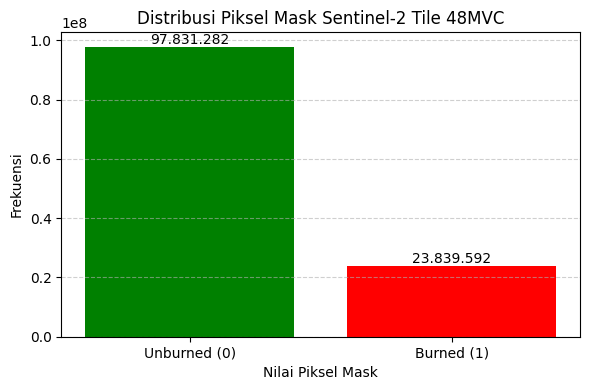

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path ke file mask Sentinel-2 (hasil thresholding dNBR)
path = '/content/drive/MyDrive/GEE_Export/MASK_48MVC.tif'  # Ganti sesuai file Sentinel-2 kamu

# Baca data mask
with rasterio.open(path) as src:
    mask = src.read(1)

# Hitung jumlah piksel unik
unique, counts = np.unique(mask, return_counts=True)
freq_dict = dict(zip(unique, counts))

# Persiapkan label dan nilai (asumsi: 0 = unburned, 1 = burned)
labels = ['Unburned (0)', 'Burned (1)']
values = [freq_dict.get(0, 0), freq_dict.get(1, 0)]

# Plot bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['green', 'red'])

# Tambahkan angka pada bar
for bar in bars:
    height = bar.get_height()
    jumlah_format = f'{int(height):,}'.replace(',', '.')
    plt.text(bar.get_x() + bar.get_width()/2, height,
             jumlah_format,
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Nilai Piksel Mask')
plt.ylabel('Frekuensi')
plt.title('Distribusi Piksel Mask Sentinel-2 Tile 48MVC')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 53.3 MB/s eta 0:00:00


In [ ]:
import rasterio

# Daftar path
raster_paths = [
  '/content/drive/MyDrive/GEE_Export2/FalseColor_48MWB.tif',
  '/content/drive/MyDrive/GEE_Export2/FalseColor_48MUC.tif',
  '/content/drive/MyDrive/GEE_Export2/FalseColor_48MVC.tif',
  '/content/drive/MyDrive/GEE_Export2/NBR_48MWB.tif',
  '/content/drive/MyDrive/GEE_Export2/NBR_48MUC.tif',
  '/content/drive/MyDrive/GEE_Export2/NBR_48MVC.tif',
  '/content/drive/MyDrive/GEE_Export2/NDVI_48MWB.tif',
  '/content/drive/MyDrive/GEE_Export2/NDVI_48MUC.tif',
  '/content/drive/MyDrive/GEE_Export2/NDVI_48MVC.tif',
  '/content/drive/MyDrive/GEE_Export2/MASK_48MWB.tif',
  '/content/drive/MyDrive/GEE_Export2/MASK_48MUC.tif',
  '/content/drive/MyDrive/GEE_Export2/MASK_48MVC.tif',
]

# Loop untuk menampilkan info setiap citra
for path in raster_paths:
    with rasterio.open(path) as src:
        width = src.width
        height = src.height
        crs = src.crs
        bounds = src.bounds

        print(f"\n--- Informasi Raster: {path.split('/')[-1]} ---")
        print(f"Ukuran raster       : {width} x {height} piksel")
        print(f"CRS                 : {crs}")
        print(f"Batas koordinat     : {bounds}")


--- Informasi Raster: FalseColor_48MWB.tif ---
Ukuran raster       : 11008 x 11065 piksel
CRS                 : EPSG:4326
Batas koordinat     : BoundingBox(left=104.99967181583868, bottom=-3.707616672146501, right=105.98853728059746, top=-2.7136308102682505)

--- Informasi Raster: FalseColor_48MUC.tif ---
Ukuran raster       : 7379 x 11062 piksel
CRS                 : EPSG:4326
Batas koordinat     : BoundingBox(left=103.52607542376902, bottom=-2.8023843603392593, right=104.18894227192081, top=-1.8086679930462446)

--- Informasi Raster: FalseColor_48MVC.tif ---
Ukuran raster       : 10998 x 11063 piksel
CRS                 : EPSG:4326
Batas koordinat     : BoundingBox(left=104.09982939573615, bottom=-2.802743686452907, right=105.08779654521081, top=-1.8089374876314803)

--- Informasi Raster: NBR_48MWB.tif ---
Ukuran raster       : 11008 x 11065 piksel
CRS                 : EPSG:4326
Batas koordinat     : BoundingBox(left=104.99967181583868, bottom=-3.707616672146501, right=105.98853728

In [ ]:
# Jalankan ini sekali di Colab untuk install GDAL
!apt install -y gdal-bin python3-gdal

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 38 not upgraded.
Need to get 5,168 kB of archives.
After this operation, 25.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.8.4+dfsg-1~jammy0 [605 kB]
Fetched 5,168 kB in 0s (14.9 MB/s)
Selecting previously unselected package python3-numpy.
(Reading database ... 126675 files and directories current

In [ ]:
import subprocess
import os

# Daftar path raster Sentinel-2
raster_paths = [
    '/content/drive/MyDrive/GEE_Export2/FalseColor_48MWB.tif',
    '/content/drive/MyDrive/GEE_Export2/FalseColor_48MUC.tif',
    '/content/drive/MyDrive/GEE_Export2/FalseColor_48MVC.tif',
    '/content/drive/MyDrive/GEE_Export2/NBR_48MWB.tif',
    '/content/drive/MyDrive/GEE_Export2/NBR_48MUC.tif',
    '/content/drive/MyDrive/GEE_Export2/NBR_48MVC.tif',
    '/content/drive/MyDrive/GEE_Export2/NDVI_48MWB.tif',
    '/content/drive/MyDrive/GEE_Export2/NDVI_48MUC.tif',
    '/content/drive/MyDrive/GEE_Export2/NDVI_48MVC.tif',
    '/content/drive/MyDrive/GEE_Export2/MASK_48MWB.tif',
    '/content/drive/MyDrive/GEE_Export2/MASK_48MUC.tif',
    '/content/drive/MyDrive/GEE_Export2/MASK_48MVC.tif'
]

# Path ke shapefile masing-masing tile
shapefiles = {
    '48MWB': '/content/drive/MyDrive/Dataset3/48MWB SENTINEL.shp',
    '48MUC': '/content/drive/MyDrive/Dataset3/48MUC SENTINEL.shp',
    '48MVC': '/content/drive/MyDrive/Dataset3/48MVC SENTINEL.shp'
}

# Folder output
output_folder = '/content/drive/MyDrive/Dataset3/Clip_Data'
os.makedirs(output_folder, exist_ok=True)

# Proses clipping
for raster_path in raster_paths:
    filename = os.path.basename(raster_path)

    # Deteksi tile ID dari nama file
    for tile_id in shapefiles:
        if tile_id in filename:
            shapefile = shapefiles[tile_id]
            break
    else:
        print(f"Tile ID tidak ditemukan dalam nama file: {filename}")
        continue

    output_path = os.path.join(output_folder, f'CLIP_{filename}')

    subprocess.run([
        'gdalwarp',
        '-cutline', shapefile,
        '-crop_to_cutline',
        '-of', 'GTiff',
        raster_path,
        output_path
    ])

    print(f'Clip selesai: {output_path}')

Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MWB.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MUC.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MVC.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MWB.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MUC.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MVC.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MWB.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MUC.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MVC.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_MASK_48MWB.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_MASK_48MUC.tif
Clip selesai: /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_MASK_48MVC.tif


Cek ukuran kembali

In [ ]:
import rasterio

# Daftar path hasil clip
raster_paths = [
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MWB.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MUC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MVC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MWB.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MUC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MVC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MWB.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MUC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MVC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_MASK_48MWB.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_MASK_48MUC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_MASK_48MVC.tif'
]

# Loop untuk menampilkan informasi raster
for path in raster_paths:
    with rasterio.open(path) as src:
        width = src.width
        height = src.height
        crs = src.crs
        bounds = src.bounds

        print(f"\n--- Informasi Raster: {os.path.basename(path)} ---")
        print(f"Ukuran raster       : {width} x {height} piksel")
        print(f"CRS                 : {crs}")
        print(f"Batas koordinat     : {bounds}")


--- Informasi Raster: CLIP_FalseColor_48MWB.tif ---
Ukuran raster       : 11006 x 11062 piksel
CRS                 : EPSG:4326
Batas koordinat     : BoundingBox(left=104.99985147889551, bottom=-3.707526840618089, right=105.98853728059746, top=-2.7138104733250743)

--- Informasi Raster: CLIP_FalseColor_48MUC.tif ---
Ukuran raster       : 10999 x 11064 piksel
CRS                 : EPSG:4326
Batas koordinat     : BoundingBox(left=103.20088529091775, bottom=-2.8022945288108474, right=104.18894227192081, top=-1.8083984984610086)

--- Informasi Raster: CLIP_FalseColor_48MVC.tif ---
Ukuran raster       : 10996 x 11059 piksel
CRS                 : EPSG:4326
Batas koordinat     : BoundingBox(left=104.10000905879298, bottom=-2.802564023396083, right=105.08779654521081, top=-1.8091171506883041)

--- Informasi Raster: CLIP_NBR_48MWB.tif ---
Ukuran raster       : 11006 x 11062 piksel
CRS                 : EPSG:4326
Batas koordinat     : BoundingBox(left=104.99985147889551, bottom=-3.70752684061808

In [ ]:
import rasterio
import numpy as np

# Daftar path raster
raster_paths = [
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MWB.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MUC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MVC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MWB.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MUC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MVC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MWB.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MUC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MVC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_MASK_48MWB.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_MASK_48MUC.tif',
    '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_MASK_48MVC.tif'
]

def cek_nan(path):
    with rasterio.open(path) as src:
        print("="*60)
        print(f"File   : {path}")
        print(f"Band   : {src.count}")
        for i in range(1, src.count + 1):
            band = src.read(i).astype("float32")
            total = band.size
            nan_count = np.isnan(band).sum()
            valid = total - nan_count
            print(f"--- Band {i} ---")
            print(f"  Total piksel : {total:,}")
            print(f"  NaN          : {nan_count:,}")
            print(f"  Valid        : {valid:,}")
            print(f"  Persen NaN   : {nan_count/total*100:.4f}%")
        print()

# Jalankan untuk semua raster
for path in raster_paths:
    cek_nan(path)

File   : /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MWB.tif
Band   : 3
--- Band 1 ---
  Total piksel : 121,748,372
  NaN          : 13,771,148
  Valid        : 107,977,224
  Persen NaN   : 11.3112%
--- Band 2 ---
  Total piksel : 121,748,372
  NaN          : 13,771,148
  Valid        : 107,977,224
  Persen NaN   : 11.3112%
--- Band 3 ---
  Total piksel : 121,748,372
  NaN          : 13,771,148
  Valid        : 107,977,224
  Persen NaN   : 11.3112%

File   : /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MUC.tif
Band   : 3
--- Band 1 ---
  Total piksel : 121,692,936
  NaN          : 13,674,087
  Valid        : 108,018,849
  Persen NaN   : 11.2365%
--- Band 2 ---
  Total piksel : 121,692,936
  NaN          : 13,674,087
  Valid        : 108,018,849
  Persen NaN   : 11.2365%
--- Band 3 ---
  Total piksel : 121,692,936
  NaN          : 13,674,087
  Valid        : 108,018,849
  Persen NaN   : 11.2365%

File   : /content/drive/MyDrive/Dataset3/Clip_Data/CLIP_Fals

# Band Stacking

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 67.6 MB/s eta 0:00:00


## Multiband Tile 48MWB

In [ ]:
from osgeo import gdal
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path input Sentinel-2 tile 48MWB
ndvi_path = '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MWB.tif'
nbr_path = '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MWB.tif'
false_color_path = '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MWB.tif'

# Baca masing-masing file raster
ndvi_ds = gdal.Open(ndvi_path)
nbr_ds = gdal.Open(nbr_path)
fc_ds = gdal.Open(false_color_path)

ndvi_band = ndvi_ds.GetRasterBand(1).ReadAsArray()
nbr_band = nbr_ds.GetRasterBand(1).ReadAsArray()

# Sentinel-2 False Color (misal B8 = band 3, B4 = band 2, B3 = band 1 dalam urutan file ini)
nir = fc_ds.GetRasterBand(3).ReadAsArray()    # Band 4
red = fc_ds.GetRasterBand(2).ReadAsArray()    # Band 8
swir  = fc_ds.GetRasterBand(1).ReadAsArray()  # Band 11

# Stack menjadi 5 band: NDVI, NBR, NIR, Red, Green
stacked_array = np.stack([ndvi_band, nbr_band, nir, red, swir], axis=0)

# Simpan sebagai multiband GeoTIFF
output_path = '/content/drive/MyDrive/Dataset3/Clip_Data/MULTIBAND_48MWB.tif'
driver = gdal.GetDriverByName('GTiff')
rows, cols = ndvi_band.shape
out_ds = driver.Create(output_path, cols, rows, 5, gdal.GDT_Float32)

# Gunakan referensi geospasial dari NDVI (asumsi semuanya align)
out_ds.SetGeoTransform(ndvi_ds.GetGeoTransform())
out_ds.SetProjection(ndvi_ds.GetProjection())

# Simpan masing-masing band
for i in range(5):
    out_ds.GetRasterBand(i + 1).WriteArray(stacked_array[i])

del out_ds  # simpan dan tutup
print("Band stacking sukses. File disimpan di:", output_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Band stacking sukses. File disimpan di: /content/drive/MyDrive/Dataset3/Clip_Data/MULTIBAND_48MWB.tif


## Multiband Tile 48MUC

In [ ]:
from osgeo import gdal
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path input Sentinel-2 tile 48MWB
ndvi_path = '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MUC.tif'
nbr_path = '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MUC.tif'
false_color_path = '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MUC.tif'

# Baca masing-masing file raster
ndvi_ds = gdal.Open(ndvi_path)
nbr_ds = gdal.Open(nbr_path)
fc_ds = gdal.Open(false_color_path)

ndvi_band = ndvi_ds.GetRasterBand(1).ReadAsArray()
nbr_band = nbr_ds.GetRasterBand(1).ReadAsArray()

# Sentinel-2 False Color (misal B8 = band 3, B4 = band 2, B3 = band 1 dalam urutan file ini)
nir = fc_ds.GetRasterBand(3).ReadAsArray()    # Band 4
red = fc_ds.GetRasterBand(2).ReadAsArray()    # Band 8
swir  = fc_ds.GetRasterBand(1).ReadAsArray()  # Band 11

# Stack menjadi 5 band: NDVI, NBR, NIR, Red, Green
stacked_array = np.stack([ndvi_band, nbr_band, nir, red, swir], axis=0)

# Simpan sebagai multiband GeoTIFF
output_path = '/content/drive/MyDrive/Dataset3/Clip_Data/MULTIBAND_48MUC.tif'
driver = gdal.GetDriverByName('GTiff')
rows, cols = ndvi_band.shape
out_ds = driver.Create(output_path, cols, rows, 5, gdal.GDT_Float32)

# Gunakan referensi geospasial dari NDVI (asumsi semuanya align)
out_ds.SetGeoTransform(ndvi_ds.GetGeoTransform())
out_ds.SetProjection(ndvi_ds.GetProjection())

# Simpan masing-masing band
for i in range(5):
    out_ds.GetRasterBand(i + 1).WriteArray(stacked_array[i])

del out_ds  # simpan dan tutup
print("Band stacking sukses. File disimpan di:", output_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Band stacking sukses. File disimpan di: /content/drive/MyDrive/Dataset3/Clip_Data/MULTIBAND_48MUC.tif


## Multiband Tile 48MVC

In [ ]:
from osgeo import gdal
import numpy as np
from google.colab import drive

# === Mount Google Drive ===
drive.mount('/content/drive')

#  Path input Sentinel-2 tile 48MWB
ndvi_path = '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NDVI_48MVC.tif'
nbr_path = '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_NBR_48MVC.tif'
false_color_path = '/content/drive/MyDrive/Dataset3/Clip_Data/CLIP_FalseColor_48MVC.tif'

#  Baca masing-masing file raster
ndvi_ds = gdal.Open(ndvi_path)
nbr_ds = gdal.Open(nbr_path)
fc_ds = gdal.Open(false_color_path)

ndvi_band = ndvi_ds.GetRasterBand(1).ReadAsArray()
nbr_band = nbr_ds.GetRasterBand(1).ReadAsArray()

# Sentinel-2 False Color (misal B8 = band 3, B4 = band 2, B3 = band 1 dalam urutan file ini)
nir = fc_ds.GetRasterBand(3).ReadAsArray()    # Band 4
red = fc_ds.GetRasterBand(2).ReadAsArray()    # Band 8
swir  = fc_ds.GetRasterBand(1).ReadAsArray()  # Band 11

# Stack menjadi 5 band: NDVI, NBR, NIR, Red, Green
stacked_array = np.stack([ndvi_band, nbr_band, nir, red, swir], axis=0)

# Simpan sebagai multiband GeoTIFF
output_path = '/content/drive/MyDrive/Dataset3/Clip_Data/MULTIBAND_48MVC.tif'
driver = gdal.GetDriverByName('GTiff')
rows, cols = ndvi_band.shape
out_ds = driver.Create(output_path, cols, rows, 5, gdal.GDT_Float32)

# Gunakan referensi geospasial dari NDVI (asumsi semuanya align)
out_ds.SetGeoTransform(ndvi_ds.GetGeoTransform())
out_ds.SetProjection(ndvi_ds.GetProjection())

# Simpan masing-masing band
for i in range(5):
    out_ds.GetRasterBand(i + 1).WriteArray(stacked_array[i])

del out_ds  # simpan dan tutup
print("Band stacking sukses. File disimpan di:", output_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Band stacking sukses. File disimpan di: /content/drive/MyDrive/Dataset3/Clip_Data/MULTIBAND_48MVC.tif


# Cek jumlah band hasil band stacking

In [ ]:
import rasterio
import numpy as np

# Path ke file raster
file_path = '/content/drive/MyDrive/Dataset3/Clip_Data/MULTIBAND_48MWB.tif'

# Buka file raster dan tampilkan metadata umum
with rasterio.open(file_path) as src:
    print("=== METADATA UMUM ===")
    print(f"Driver     : {src.driver}")
    print(f"CRS        : {src.crs}")
    print(f"Ukuran     : {src.width} x {src.height} (cols x rows)")
    print(f"Jumlah Band: {src.count}")
    print(f"Transform  : {src.transform}")
    print()

    # Periksa metadata tiap band
    for i in range(1, src.count + 1):
        band = src.read(i)
        print(f"--- Band {i} ---")
        print(f"  Tipe Data  : {band.dtype}")
        print(f"  Nilai min  : {band.min()}")
        print(f"  Nilai max  : {band.max()}")
        print(f"  Mean       : {np.mean(band):.2f}")
        print(f"  Std Dev    : {np.std(band):.2f}")
        print()

=== METADATA UMUM ===
Driver     : GTiff
CRS        : EPSG:4326
Ukuran     : 11006 x 11062 (cols x rows)
Jumlah Band: 5
Transform  : | 0.00, 0.00, 105.00|
| 0.00,-0.00,-2.71|
| 0.00, 0.00, 1.00|

--- Band 1 ---
  Tipe Data  : float32
  Nilai min  : nan
  Nilai max  : nan
  Mean       : nan
  Std Dev    : nan

--- Band 2 ---
  Tipe Data  : float32
  Nilai min  : nan
  Nilai max  : nan
  Mean       : nan
  Std Dev    : nan

--- Band 3 ---
  Tipe Data  : float32
  Nilai min  : nan
  Nilai max  : nan
  Mean       : nan
  Std Dev    : nan

--- Band 4 ---
  Tipe Data  : float32
  Nilai min  : nan
  Nilai max  : nan
  Mean       : nan
  Std Dev    : nan

--- Band 5 ---
  Tipe Data  : float32
  Nilai min  : nan
  Nilai max  : nan
  Mean       : nan
  Std Dev    : nan

